In [46]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import os
import seaborn as sns  

from dotenv import load_dotenv; load_dotenv()

from utils import preprocessing
from utils import DEG

from statsmodels.stats.multitest import multipletests
import gseapy as gp
from gseapy import dotplot, barplot, gseaplot2
print(gp.get_library_name())

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

TISSUE = "Striatum"
TYPE_DEG = "PCA_nebula" #PCA_nebula, baseline_nebula. gradient_score_nebula
RESULTS_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/{TISSUE}/{TYPE_DEG}"

# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "ct_for_deg" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxresseda
CONTRAST_VARIABLE = "condition"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "Control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "XDP"

# How to define significant genes
ALPHA_MULTIPLE_TEST = 0.05
METHOD_MULTIPLE_TEST = "fdr_bh" # fdr_bh, bonferroni, holm, etc. see statsmodels.stats.multitest.multipletests
LOGFC_THR=0.5 #1e-30#0.5 #set your logFC threshold at or above the median SE
PVAL_THR=0.05
PVAL_COL=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
LOGFC_COL=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
SE_COL=f"se_{CONTRAST_VARIABLE}{CONTRAST_STIM}"
GENE_COL="gene"
COL_P_ADJ = f"adj_{PVAL_COL}"
N_TOP = 20
INTERCEPT_LOGFC_INTERCEPT_COL = "logFC_(Intercept)"

# GSEA parameters

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_Drug_Targets_2024

In [47]:
RUN_ON_ZONES = True # if False, will run on ct

if RUN_ON_ZONES:

    # define on what cell type run the analsys
    # zone varibale (only need if runnogn deg on zones and nto ct)
    ZONE_VARIABLE = "zone"
    # As zones are ct specific, defne ct of the curretn zone
    ZONE_CT = "D1_Matrix" #Astrocyte, D1_Matrix

    RESULTS_FOLDER = f"{RESULTS_FOLDER}/{ZONE_CT}_by_zone"
    print(RESULTS_FOLDER)
     # name of cell tyoe vauble annotaton to use in this analsys

    CT_FOR_DEG_VARIABLE = ZONE_VARIABLE

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone


# Read grad genes

In [43]:
GRAD_THR=0.1

df_grad = pd.read_csv("/home/gdallagl/myworkdir/XDP/utils/dorsal_ventral_gradient/exp_by_spline_combined.csv")

grad_genes = df_grad[
    (np.abs(df_grad.mean_spearman)>= GRAD_THR) & 
    (df_grad.combined_p <= 0.05) &
    (df_grad.mean_spearman.notna()) 
    ]["gene"].tolist()
print(len(grad_genes))

df_grad["is_gradient_gene"] = df_grad["gene"].isin(grad_genes)
print(df_grad["is_gradient_gene"].sum())
df_grad = df_grad.set_index("gene")[["mean_spearman", "is_gradient_gene"]]
df_grad

1241
1241


,mean_spearman,is_gradient_gene
gene,,
A1BG,-0.002360,False
A1BG-AS1,-0.007881,False
A1CF,0.007398,False
A2M,-0.002144,False
A2M-AS1,-0.000389,False
...,...,...
ENSG00000277836,NaN,False
ENSG00000278633,NaN,False
ENSG00000276017,-0.008289,False


# Plot Vulcano plots


######################
 1 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/1/deg_results.csv
ERROR: Missing results file for 1 at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/1/deg_results.csv

######################
 2 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/2/deg_results.csv
 0


,gene,logFC_conditionXDP,p_conditionXDP,logFC_(Intercept),is_grad_gene,mean_spearman,is_significant
3808,LINC01378,-2.522642,8.002002e-10,-10.150155,True,-0.164386,True
9404,LINC02822,-1.936902,4.672948e-08,-8.716988,True,-0.270936,True
630,ENSG00000286548,0.532023,1.402091e-07,-9.645756,False,-0.003134,True
8202,SBF2,0.171218,1.563970e-07,-7.466783,False,-0.056043,False
10680,SLC30A4,0.351994,1.024904e-06,-9.388531,True,-0.191186,False
...,...,...,...,...,...,...,...
13511,PTOV1-AS1,-0.000177,9.996112e-01,-13.222991,False,0.000282,False
13500,RPL13A,0.000118,9.995091e-01,-10.850505,False,-0.009167,False
8528,RCE1,-0.000171,9.993938e-01,-12.565023,False,0.005184,False
3072,SNX4,0.000040,9.995909e-01,-9.989004,False,-0.012005,False


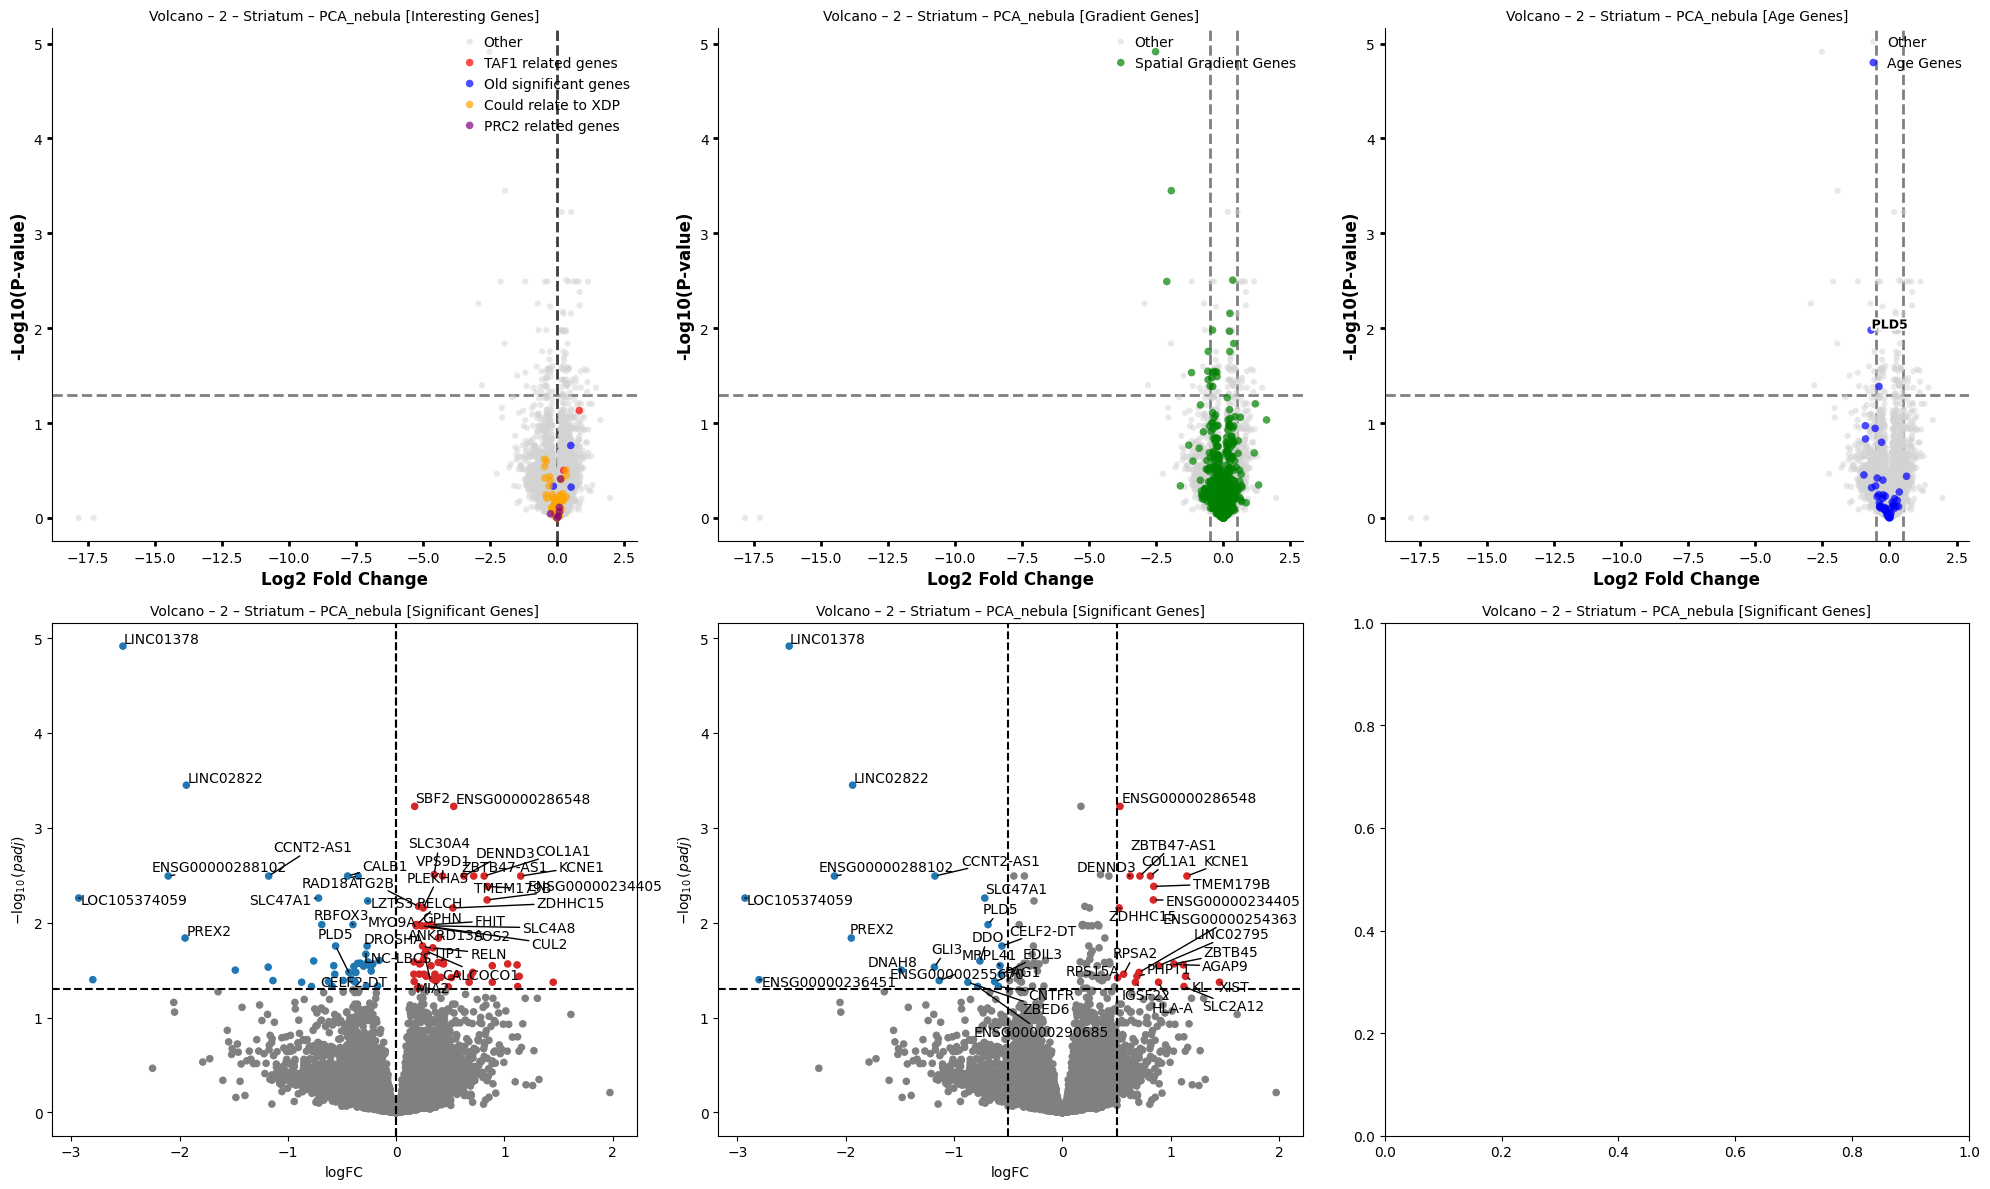


######################
 3 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/3/deg_results.csv
 0


,gene,logFC_conditionXDP,p_conditionXDP,logFC_(Intercept),is_grad_gene,mean_spearman,is_significant
12519,SEZ6L,1.055278,6.153238e-11,-10.257050,False,0.098915,True
3577,PDZD2,0.196663,4.299039e-10,-6.276875,True,-0.138956,False
3992,ARHGAP26,0.255268,3.211868e-09,-7.362265,False,0.074518,False
11606,ZNF780B,-0.160739,2.965575e-09,-8.992299,False,0.042122,False
11584,ACTN4,-0.214233,5.897539e-09,-9.529791,True,-0.162185,False
...,...,...,...,...,...,...,...
5335,ING3,-0.000077,9.993475e-01,-11.477078,False,-0.027111,False
2076,AAMP,-0.000047,9.995694e-01,-11.680283,False,0.050667,False
102,MAD2L2,0.000025,9.998243e-01,-11.733593,False,0.021652,False
11108,POLRMT,-0.000002,9.999866e-01,-11.880963,False,-0.024955,False


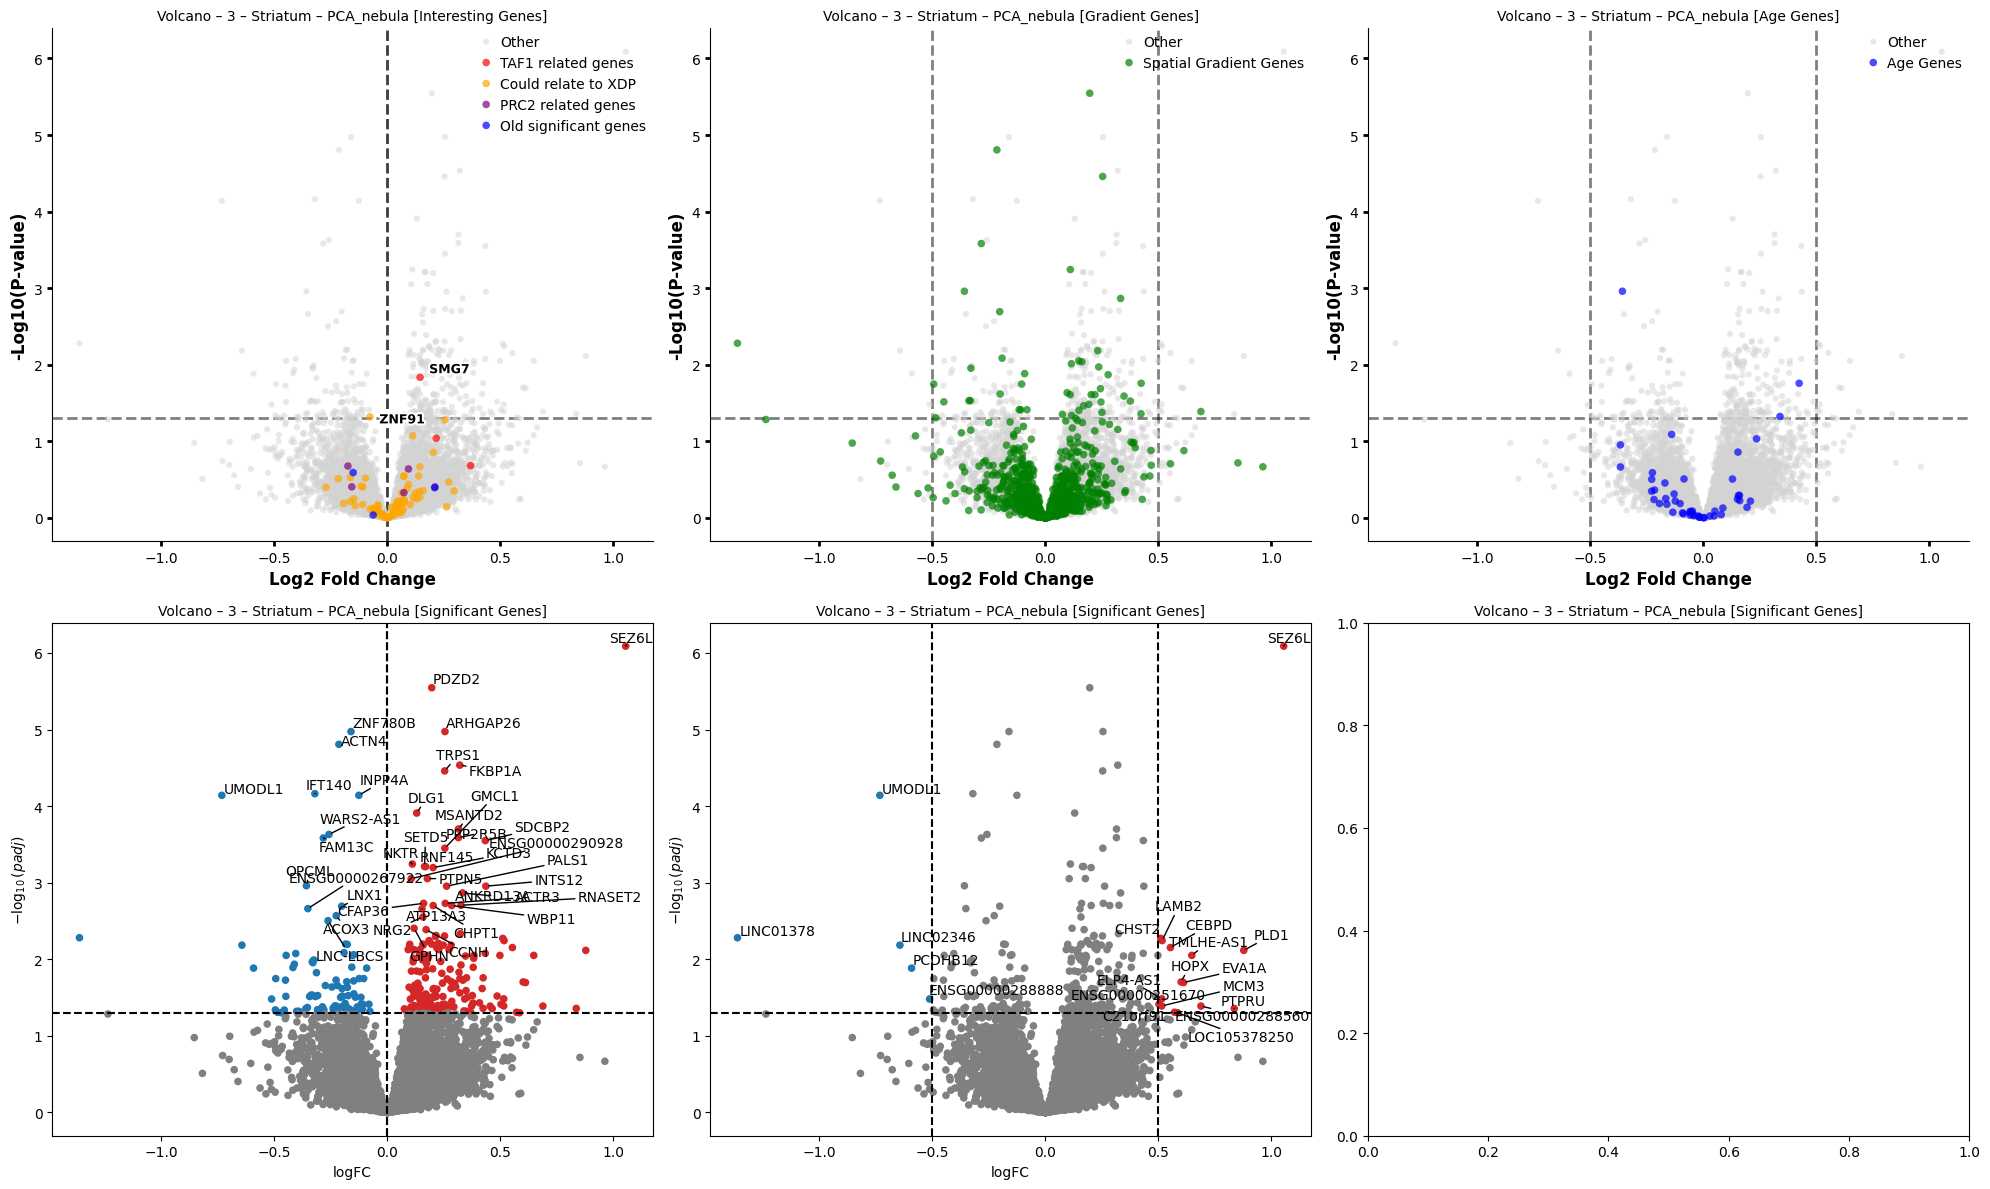


######################
 4 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/4/deg_results.csv
 0


,gene,logFC_conditionXDP,p_conditionXDP,logFC_(Intercept),is_grad_gene,mean_spearman,is_significant
3230,PDZD2,0.311512,3.432524e-11,-6.387839,True,-0.138956,False
6498,PTPN5,0.257813,8.802744e-08,-7.851668,False,-0.037782,False
7420,HSP90B1,0.553683,1.498396e-07,-9.567218,False,0.031538,True
2549,MME,0.996694,2.268253e-07,-10.050404,True,-0.329792,True
5310,TRPS1,0.308763,3.684055e-07,-7.869369,True,0.151998,False
...,...,...,...,...,...,...,...
7585,STX2,0.000057,9.995367e-01,-10.360958,False,0.040833,False
1082,ENSG00000230325,0.000171,9.994348e-01,-12.274002,False,-0.013766,False
0,ENSG00000291215,0.000099,9.993836e-01,-11.163373,False,-0.010816,False
7680,PROSER1,-0.000045,9.996448e-01,-10.788187,False,-0.006083,False


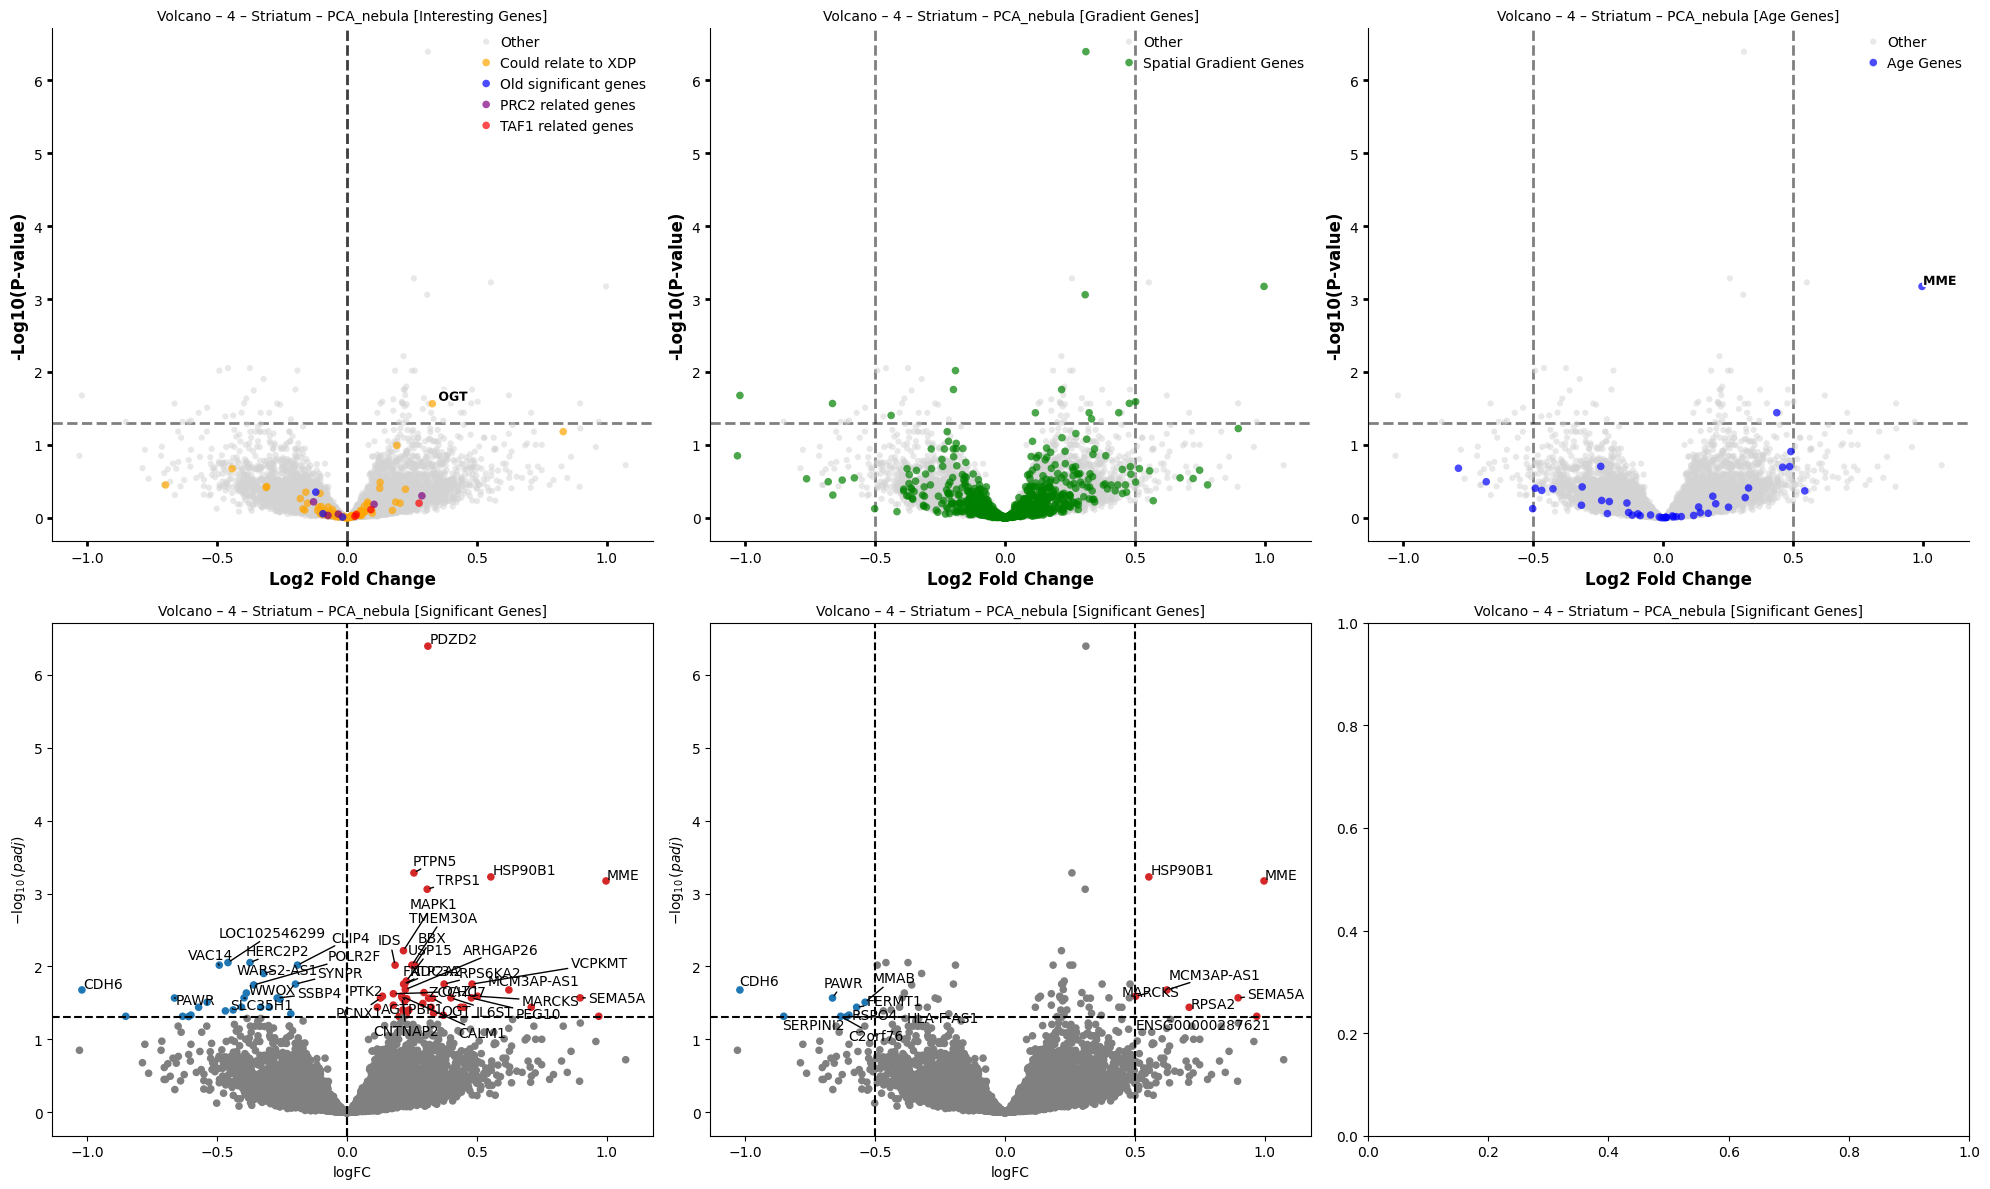


######################
 5 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/5/deg_results.csv
 0


,gene,logFC_conditionXDP,p_conditionXDP,logFC_(Intercept),is_grad_gene,mean_spearman,is_significant
10651,NUP93,0.184379,2.718897e-11,-8.660121,True,-0.139317,False
3809,PDZD2,0.253513,6.434724e-11,-6.315916,True,-0.138956,False
5313,MINDY4,-0.213815,6.504074e-10,-9.643686,False,-0.096694,False
4262,ARHGAP26,0.217871,2.219104e-09,-7.300737,False,0.074518,False
11135,CORO6,-0.462824,7.039545e-09,-9.627051,False,0.065080,False
...,...,...,...,...,...,...,...
8657,B4GALNT1,0.000240,9.966459e-01,-10.824230,False,-0.022427,False
10218,SEMA4B,0.000007,9.998926e-01,-10.449884,False,0.004103,False
8701,MDM2,0.000085,9.982347e-01,-9.989671,False,0.028045,False
6429,LINC02851,-0.000539,9.969900e-01,-12.667731,False,0.000294,False


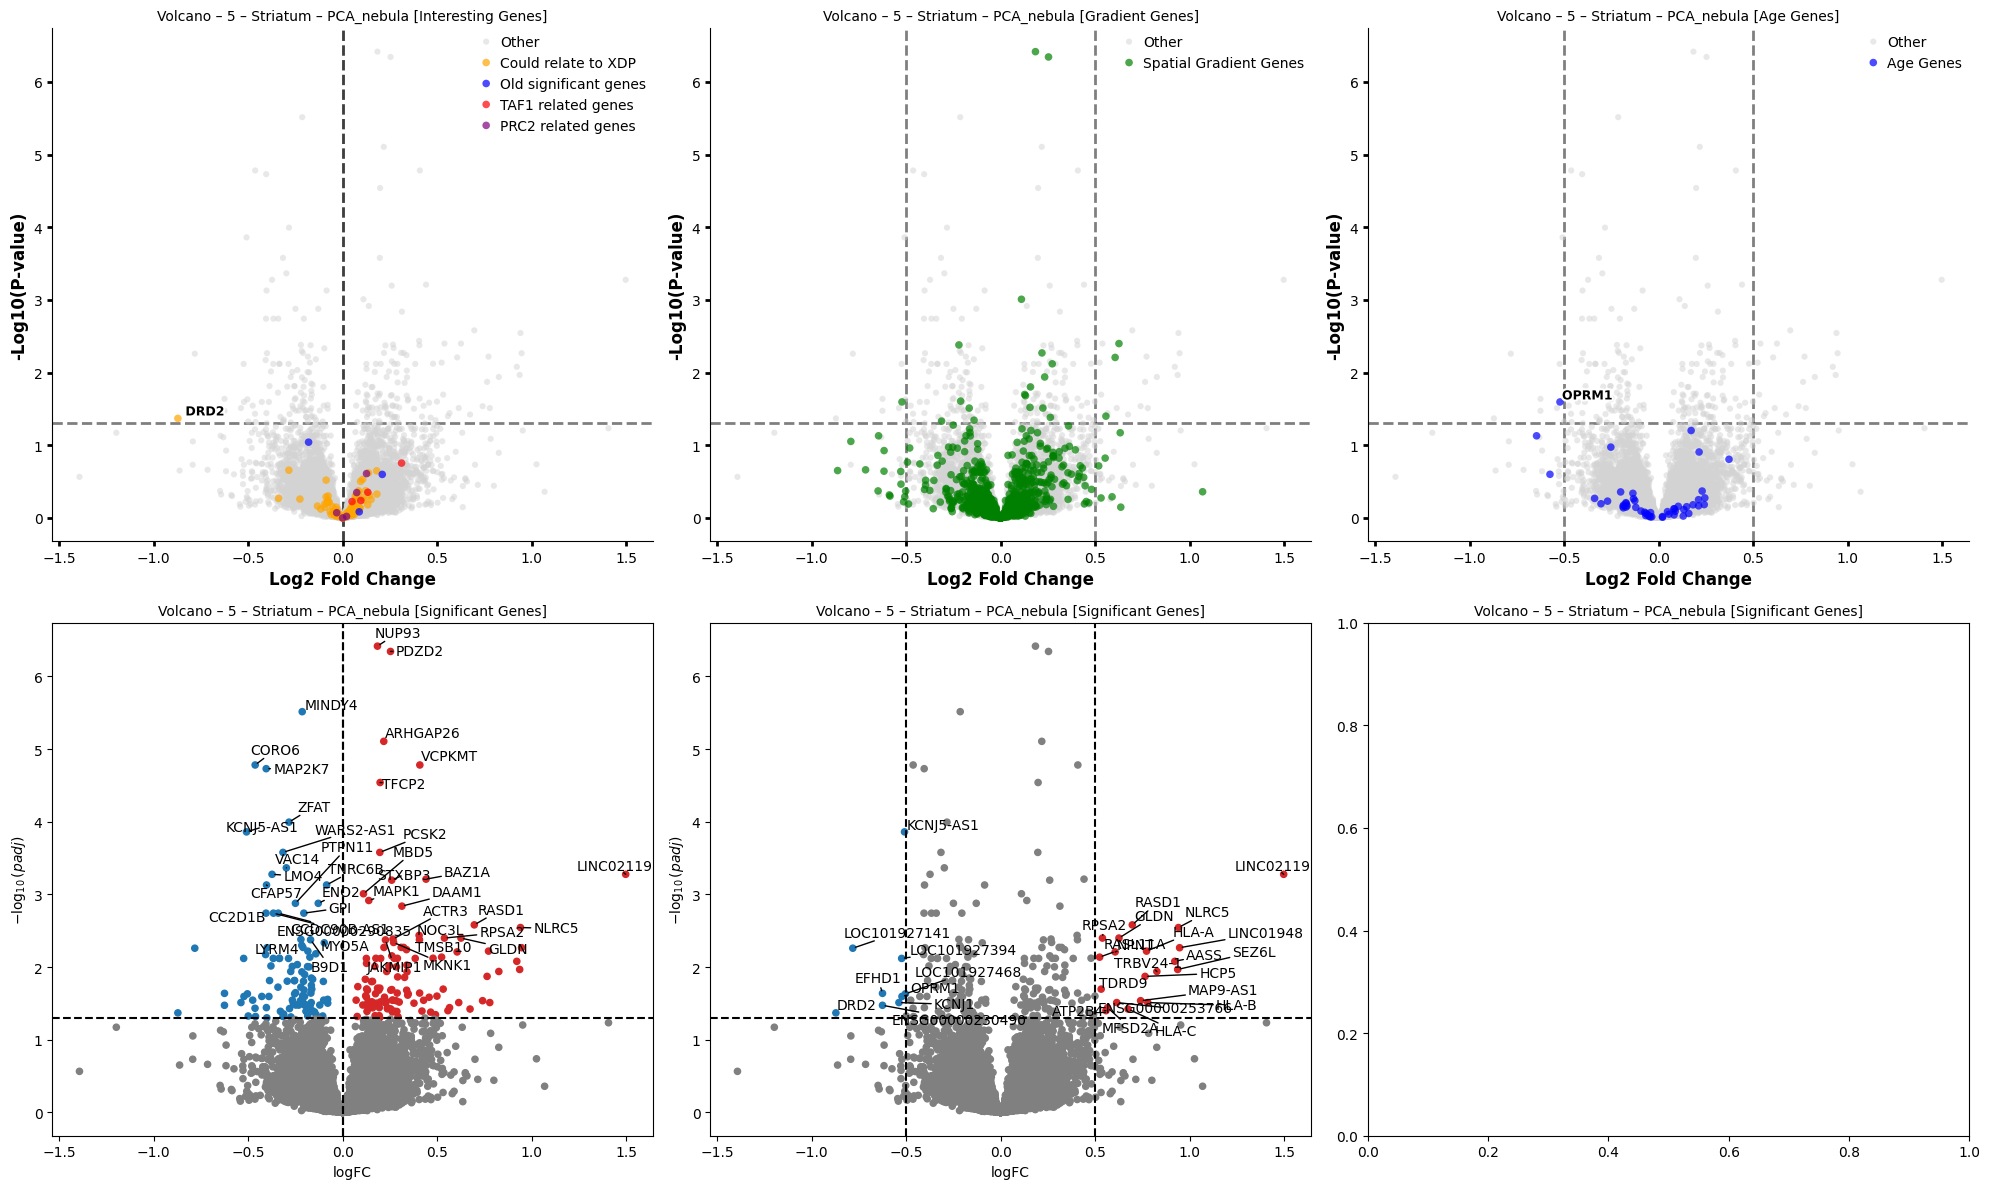


######################
 6 
######################

/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/D1_Matrix_by_zone/6/deg_results.csv
 0


,gene,logFC_conditionXDP,p_conditionXDP,logFC_(Intercept),is_grad_gene,mean_spearman,is_significant
8113,TFCP2,0.337412,1.578100e-12,-9.358644,False,-0.054595,False
8619,ENOX1,0.213534,4.113541e-12,-7.401803,False,0.045309,False
5621,LPL,-0.588153,7.579208e-11,-9.256873,True,-0.203734,True
8365,ANKRD13A,0.391741,1.015023e-09,-9.259531,True,-0.117860,False
2398,NKTR,0.176556,9.805584e-10,-8.334559,True,0.131967,False
...,...,...,...,...,...,...,...
11804,ZNF235,-0.000012,9.998721e-01,-9.923172,False,-0.022588,False
1990,NAB1,0.000023,9.998971e-01,-12.189862,True,0.151678,False
7544,CTTN-DT,0.000053,9.996284e-01,-11.268573,False,0.016017,False
6816,PSAP,-0.000017,9.998150e-01,-9.345256,False,0.042307,False


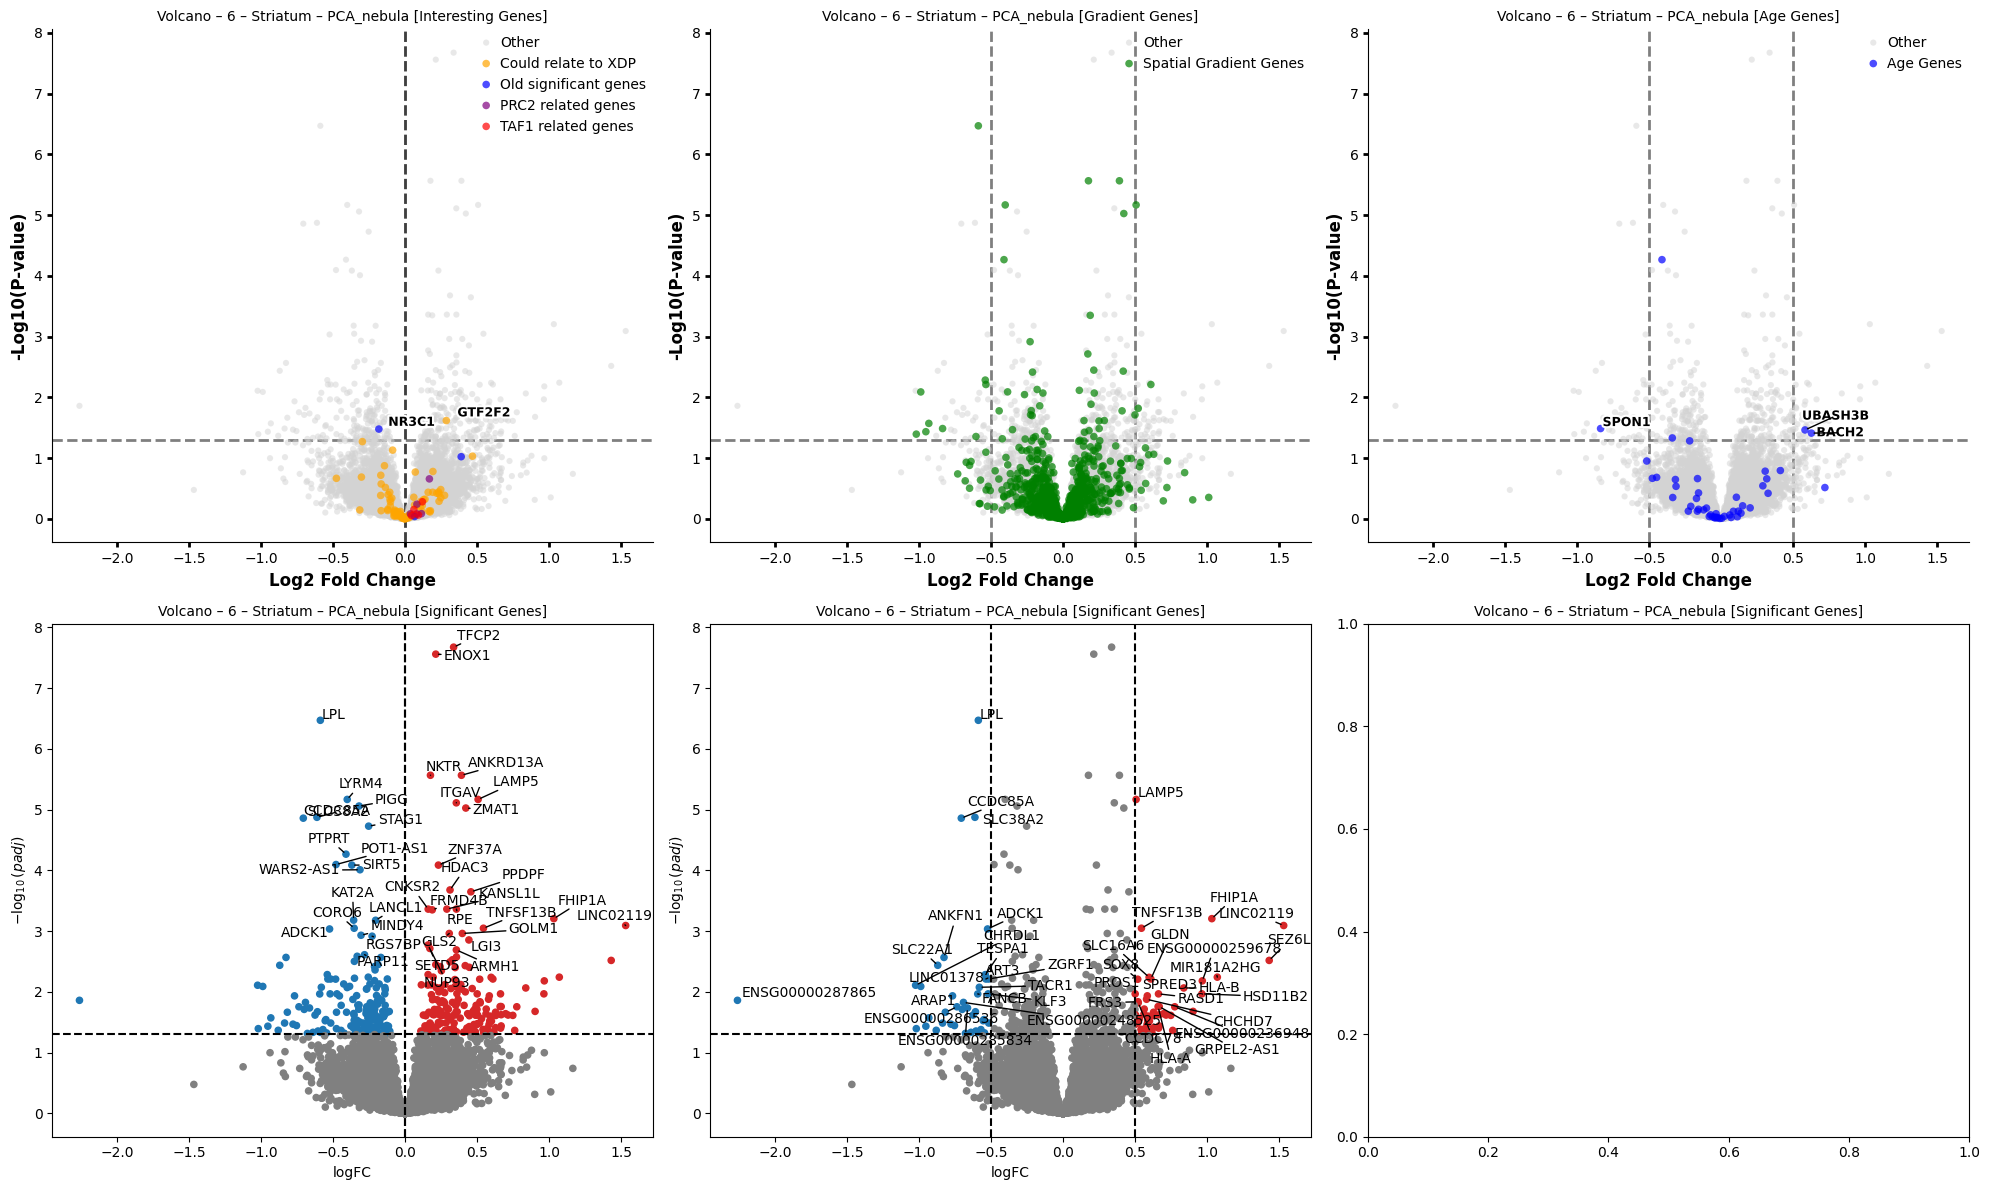

In [49]:
for ct in sorted(os.listdir(RESULTS_FOLDER)):

    #ct="Matrix"
    if "-" in ct:
        continue
    print("\n######################\n",ct, "\n######################\n")

    # subfolder = f"{ZONE_CT}_by_zone/{ct}" if RUN_ON_ZONES else ct # dedin if we are using zones

    # fodle of results
    SAVE_HEALTHY_PCA_RESULT = os.path.join(RESULTS_FOLDER, ct)    
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka
    print(save_csv_path)

    # Saved files
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "images")
    os.makedirs(img_dir, exist_ok=True)
    formatted_save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results_formatted.csv"
    vulcano_plot_path = f"{img_dir}/volcano_plot.png"
    vulcano_plot_only_sig_path = f"{img_dir}/volcano_plot_only_sig.png"
    vulcano_plot_only_interesting_path = f"{img_dir}/volcano_plot_only_interesting.png"

    if not os.path.exists(save_csv_path):
        print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
        continue

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)

    # Add adj pvalue
    # attention: use all genes
    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])
    df_nebula[COL_P_ADJ] = multipletests(df_nebula[PVAL_COL],method=METHOD_MULTIPLE_TEST)[1]

    print("", (df_nebula[INTERCEPT_LOGFC_INTERCEPT_COL] < -20).sum())

    # Add gradient info
    df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
    df_nebula["is_grad_gene"] = df_nebula["gene"].isin(grad_genes)
    df_nebula = df_nebula.sort_values(COL_P_ADJ)

    # Selec signficant genes
    sig_genes = df_nebula[(np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[COL_P_ADJ] <= PVAL_THR)][GENE_COL].tolist()
    df_sig = df_nebula[df_nebula[GENE_COL].isin(sig_genes)].copy()
    df_sig = df_sig[[GENE_COL, LOGFC_COL, COL_P_ADJ, "is_grad_gene", "mean_spearman"]]
    #print(df_sig[GENE_COL].to_list())
    #display(df_sig)
    #print(df_sig["is_grad_gene"].sum())

    # Create formatted results 
    df_nebula_formatted = df_nebula[[GENE_COL, LOGFC_COL, PVAL_COL, INTERCEPT_LOGFC_INTERCEPT_COL, "is_grad_gene", "mean_spearman"]].copy() # sleect spefici columns
    df_nebula_formatted["is_significant"] = df_nebula_formatted[GENE_COL].isin(sig_genes) # add column for signficant genes
    df_nebula_formatted.to_csv(formatted_save_csv_path, index=False)
    display(df_nebula_formatted)

    #########
    ### VULCANO PLOT
    ##########
    categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green"),}
    categories_age = {"Age Genes": (["HCN1", "VWC2", "OPRM1", "BACH2", "PCED1B", "MME", "EBF1", "SPON1", "SEMA3E", "SERPINE2", "LINGO2", "GRM8", "KCNK2", "SINHCAF", "DDIT4L", "PTPN7", "PRKD1", "PEX5L", "OPCML", "SHC3", "PDE4B", "SLC24A2", "CCDC39", "FAT2", "CNTN5", "FIGN", "PTPRT", "MGAT4C", "IGF2BP2", "AR", "ETV1", "CDH10", "CORO1C", "SPRED2", "GJD2-DT", "ST3GAL6", "EPHA3", "UBASH3B", "PLEKHA7", "PLD5", "SH3RF3", "DOK5", "DOCK10", "SEMA3D", "KITLG", "SCN11A", "COL19A1", "ZNF732", "UNC13C", "SATB1"], "blue"),}
    categories_general = {
        "TAF1 related genes": (["TAF1", "TIA1", "ZNF772", "SMG7", "ZNF93", "MOV10L1", "EXO1", "SSH", "GLIA1", "OGT"], "red"),
        "Old significant genes": (["SLC7A2", "FKBP5", "ZBTB16", "HIF3A", "NR3C1"], "blue"),
        "PRC2 related genes":([
                            # PRC2 core
                            "EZH1", "EZH2", "SUZ12", "JARID2",

                            # Death-promoting upregulated - normally kept permanently OFF by PRC2 in healthy neurons# When PRC2 is lost, these genes get reactivated and directly promote neuron death.
                            "PMAIP1", "BID", "CDKN2A", "CDKN2B", "CCND1", "WT1", "TP73", "IGFBP3",
                            ], "purple"),
        "Could relate to XDP": (
                            [
                            # Primary disease locus genes (Xq13.1)
                            "TAF1", "OGT", "OGA", "ACRC", "CXCR3", "NONO", "ING2", "NLGN3", "GJB1", "ZNF261", "ITGB1BP2",
                            
                            # Direct TAF1 protein interactors (TFIID complex)
                            "TBP", "TAF2", "TAF3", "TAF4", "TAF5", "TAF6", "TAF7", "TAF8", "TAF9", "TAF10", "TAF11", "TAF12", "TAF13",
                            
                            # TAF1 kinase/ubiquitin substrates and binding partners
                            "TP53", "MDM2", "RB1", "AR", "JUN", "CCND1", "CCNA2",
                            
                            # General Transcription Factors (PIC assembly)
                            "GTF2B", "GTF2A1", "GTF2A2", "GTF2E1", "GTF2E2", "GTF2F1", "GTF2F2", "GTF2H1", "GTF2H2", "GTF2H3", "GTF2H4", "GTF2H5", "TCEA1", "ERCC2", "ERCC3",
                            
                            # TAF1 in MLL1 complex
                            "KMT2A", "ASH2L", "HCFC1", "WDR5", "RBBP5",
                            
                            # Striatal signaling breakdown (dysregulated in XDP brain)
                            "DRD2", "DRD1", "PDE10A", "GNAL",
                            
                            # DSC3-affected downstream genes (vesicular transport, dopamine, synapse)
                            "SYP", "SNAP25", "RAB26", "RAB27B", "RAB8B", "DDC", "GCH1", "SLC18A2", "SYT7", "DLG4", "SNAP91", "DBH", "SYTL2", "SLC5A3", "EFNB1",
                            
                            # NFkB pathway and inflammatory targets (altered in XDP fibroblasts)
                            "RELA", "NFKB1", "NFKB2", "IKBKB", "IKBKG", "TNFAIP6", "IL8",
                            
                            # Repeat instability modifiers (shared with HD)
                            "MSH3", "PMS2",
                            
                            # Spliceosome and RNA metabolism (altered in XDP MSNs)
                            "SRSF2", "DHX15", "DHX9", "FUS", "GEMIN5", "HRNPU", "NOVA1", "PAPOLA", "PRPF6", "SART3", "SRSF5", "RALY", "U2AF1L5",
                            
                            # Translational machinery (compensatory upregulation in XDP MSNs)
                            "BMS1", "TRMT5",
                            
                            # SVA retrotransposon repression machinery (KRAB-ZNF / TRIM28 axis)
                            "ZNF91", "TRIM28", "ZNF93", "SETDB1", "DNMT3A", "DNMT3B",
                            
                            # LINE-1 mobilization machinery (SVA is L1-dependent)
                            "L1RE1",
                            
                            # NMD pathway (degrades TAF1-32i intron retention isoform)
                            "UPF1", "UPF2", "UPF3B",
                            
                            # Chromatin immunomodulatory (SVA heterochromatin)
                            "KMT5C", "CIITA",
                            
                            # TAF1 paralog
                            "TAF1L"
                            ], 
                            "orange"),
    }

    fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(20, 12))

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=0, # FROCE TO SEE ALL
        to_label=0, 
        categories=categories_general,
        max_y=None,
        ax=ax1,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_spatial,
        max_y=None,
        ax=ax2,
        print_labels=False,
    )

    DEG.plot_vulcano(
        df_nebula,
        logfc_col=LOGFC_COL, 
        pval_col=COL_P_ADJ, 
        gene_col=GENE_COL, 
        pval_thresh=PVAL_THR, 
        logfc_thresh=LOGFC_THR,
        to_label=0, 
        categories=categories_age,
        max_y=None,
        ax=ax3,
        print_labels=True,
    )

    import decoupler as dc
    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=1e-20, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax4, 
    )

    import decoupler as dc
    dc.pl.volcano(
        df_nebula.set_index(GENE_COL).rename(columns={COL_P_ADJ: "padj", LOGFC_COL: "logFC"}), # ccan manage "_"
        x="logFC",
        y="padj",
        top=40,
        thr_stat=LOGFC_THR, # logFC thresholdFORCE TO SEE ALL
        thr_sign=PVAL_THR,
        max_stat=5,        # clip x-axis to ±5
        ax=ax5, 
    )

    title = f"Volcano – {ct} – {TISSUE} – {TYPE_DEG}"
    for ax, lbl in zip([ax1, ax2, ax3, ax4, ax5, ax6], ["Interesting Genes", "Gradient Genes", "Age Genes", "Significant Genes" ,"Significant Genes", "Significant Genes"]):
        ax.set_title(f"{title} [{lbl}]", fontsize=10)

    # fig.canvas.draw()
    # saved_figs[ct] = fig
    
    plt.tight_layout() 


    plt.savefig(vulcano_plot_path, dpi=150, bbox_inches="tight")

    extent = ax1.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_interesting_path, bbox_inches=extent, dpi=150)
    extent = ax4.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    fig.savefig(vulcano_plot_only_sig_path, bbox_inches=extent, dpi=150)

    plt.show()

    #break

   

# GSEA


######################
 Astrocyte 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val


  No significant GSEA terms for Astrocyte, skipping plots
  Redundancy removal: 0 → 0 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (curated):


...

,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (gobp):


,gene,n_pathways



######################
 Endothelial_BBB 
######################

ERROR: Missing results file for Endothelial_BBB at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Endothelial_BBB/deg_results.csv

######################
 Ependymal 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__Hypoxia,1.998143,0.0
1,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,1.989749,0.0
2,MSigDB_Hallmark_2020__Oxidative Phosphorylation,1.789272,0.016903


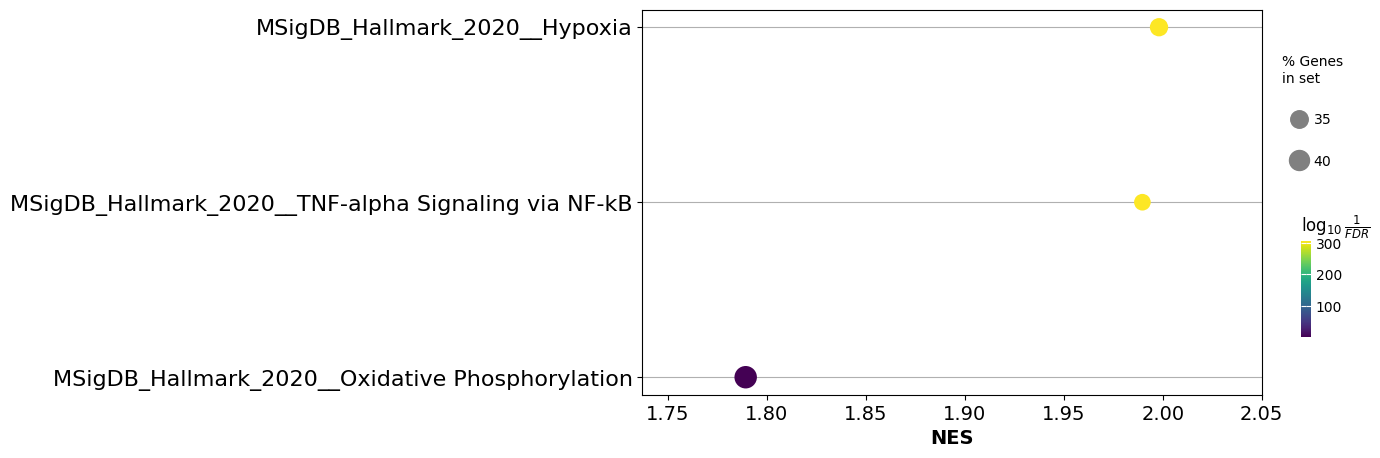

  Redundancy removal: 3 → 3 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,MSigDB_Hallmark_2020__Hypoxia,1.998143,0.0,34/93,34,ACKR3;MAFF;MT1E;MT2A;CCN1;TPI1;HSPA5;DDIT4;MYH9;MXI1;TIPARP;PGM1;KLF7;GAPDH;PIM1;ENO1;KLF6;UGP2;DTNA;WSB1;SDC4;PPP1R3C;COL5A1;ATF3;SAP30;ZFP36;CDKN1A;BNIP3L;P4HA1;AK4;ZNF292;CP;PAM;RBPJ
1,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,1.989749,0.0,27/81,27,ACKR3;BCL6;MAFF;CCN1;PDLIM5;PER1;GEM;BTG2;TIPARP;KLF6;B4GALT1;RHOB;SIK1;NR4A1;LITAF;PMEPA1;SDC4;ATF3;TGIF1;GADD45B;ZFP36;SPSB1;CDKN1A;PLPP3;TRAF1;TSC22D1;ZBTB10
2,MSigDB_Hallmark_2020__Oxidative Phosphorylation,1.789272,0.016903,62/138,62,UQCRB;COX8A;ATP5PD;NDUFB4;NDUFV2;MDH1;PDK4;ATP5F1D;IDH3A;NDUFB8;VDAC3;NDUFB5;NDUFS7;COX6B1;ATP5MC2;ATP5MC3;MGST3;ATP5F1C;PDHA1;ISCU;ATP5F1A;NDUFS1;DECR1;HSPA9;MTX2;SLC25A4;VDAC1;NDUFC2;COX7A2;NDUFA1;COX4I1;DLD;MPC1;COX5B;SDHA;DLAT;COX6A1;CS;UQCR11;GOT2;NDUFS2;COX7C;IMMT;NDUFS6;PDP1;RHOT1;MFN2;MAOB;MDH2;CASP7;ATP6V0E1;CYCS;NDUFS4;PRDX3;ALDH6A1;ACADSB;LDHB;UQCRC2;VDAC2;ATP5PO;ACAA2;NDUFC1



Top leading edge genes (curated):


,gene,n_pathways
0,ACKR3,2
1,MAFF,2
2,CCN1,2
3,TIPARP,2
4,KLF6,2
5,SDC4,2
6,ATF3,2
7,ZFP36,2
8,CDKN1A,2


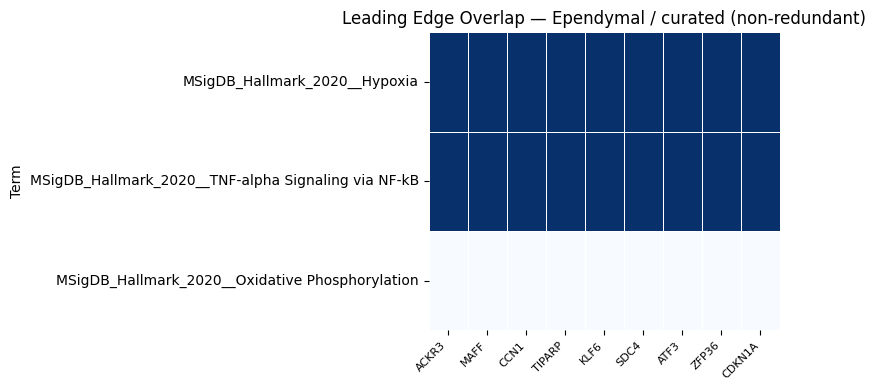


	######################
 	reactome 
	######################



,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Mitochondrial RNA Degradation,-2.098224,0.02776


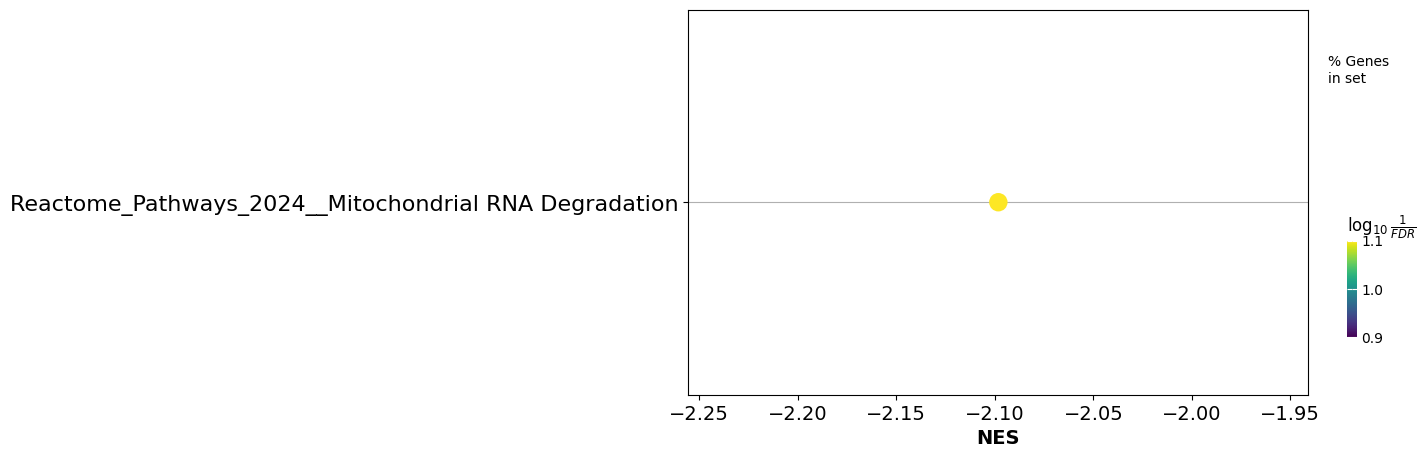

  Redundancy removal: 1 → 1 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Mitochondrial RNA Degradation,-2.098224,0.02776,7/19,7,MT-ND1;SLIRP;MT-CYB;MT-CO3;MT-CO2;MT-ND2;PNPT1



Top leading edge genes (reactome):


,gene,n_pathways



	######################
 	gobp 
	######################



,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Axoneme Assembly (GO:0035082),-2.147764,0.015078


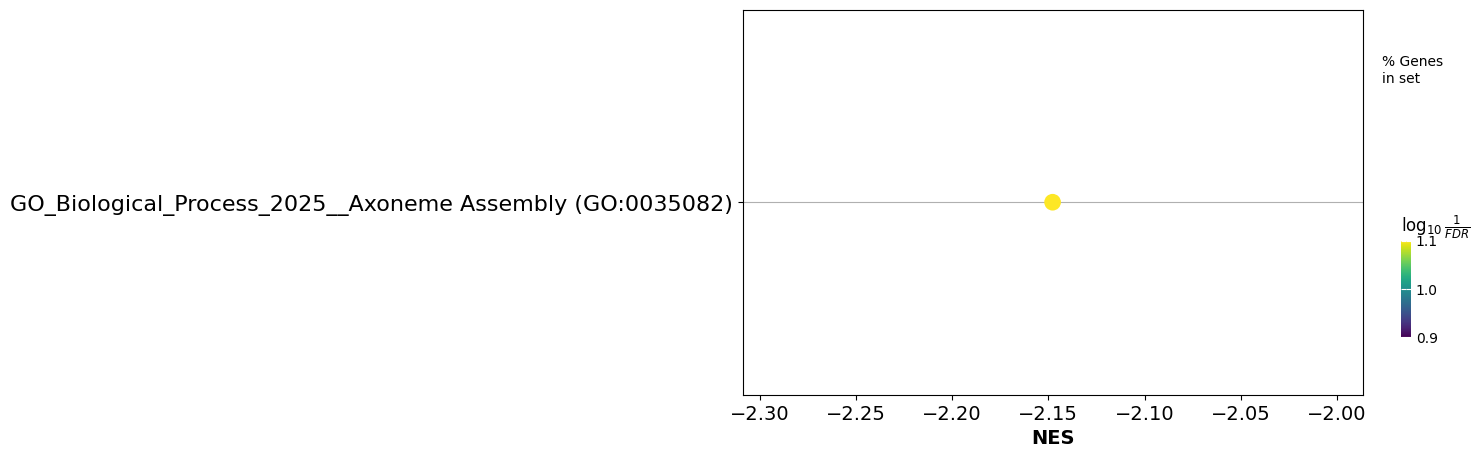

  Redundancy removal: 1 → 1 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,GO_Biological_Process_2025__Axoneme Assembly (GO:0035082),-2.147764,0.015078,12/36,12,SPAG1;SPEF1;LRGUK;DNAAF2;CFAP46;TOGARAM1;DNAI4;SPAG16;CCDC40;DRC1;DNAJB13;CFAP91



Top leading edge genes (gobp):


,gene,n_pathways



######################
 Fibroblasts 
######################

ERROR: Missing results file for Fibroblasts at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Fibroblasts/deg_results.csv

######################
 Lymphocytes 
######################

ERROR: Missing results file for Lymphocytes at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Lymphocytes/deg_results.csv

######################
 Macrophages 
######################

ERROR: Missing results file for Macrophages at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Macrophages/deg_results.csv

######################
 Matrix 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,1.922075,0.010484
2,SynGO_2024__Presynaptic Ribosome CC,1.851436,0.010484
3,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.834155,0.010484
1,MSigDB_Hallmark_2020__Unfolded Protein Response,1.872015,0.011009
4,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,1.80577,0.01363


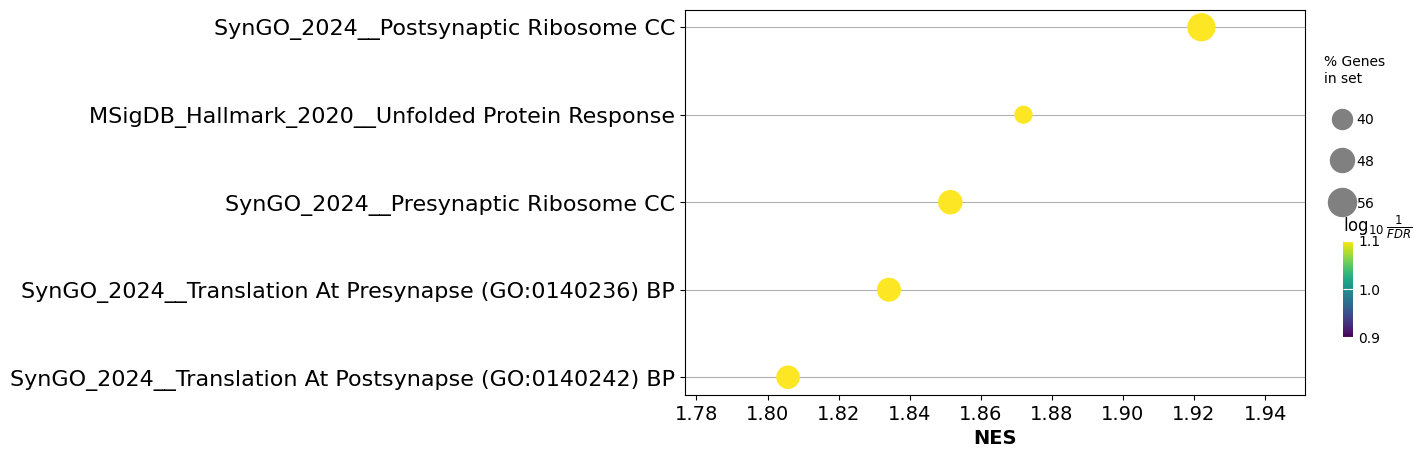

  Redundancy removal: 5 → 2 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,1.922075,0.010484,39/69,39,RPL15;RPL35A;RPL4;MRPS12;RPS15A;RPL37;RPL31;RPS17;RPS3;RPS6;RPS2;RPL7;RPL26;RPL38;RPL10A;RPL5;RPL23;RPL18;RPS24;RPL32;RPL24;RPS27;RPL6;RPL22;RPS28;RPL9;RPS3A;RPL34;RPL21;RPLP1;RPL12;RPL23A;UBA52;RPS18;RPS7;RPL17;RPL13A;RPS27A;RPS8
1,MSigDB_Hallmark_2020__Unfolded Protein Response,1.872015,0.011009,39/107,39,WFS1;DKC1;ERO1A;IARS1;TSPYL2;DCP2;XBP1;HYOU1;SERP1;SSR1;DNAJB9;EIF2AK3;EIF2S1;SLC1A4;SEC31A;EIF4E;HERPUD1;PDIA6;DNAJA4;POP4;EIF4G1;ATF6;FKBP14;PREB;HSPA9;KDELR3;SLC7A5;HSP90B1;DDIT4;PARN;EIF4A1;SDAD1;NPM1;DCP1A;ASNS;TUBB2A;BANF1;XPOT;KHSRP



Top leading edge genes (curated):


,gene,n_pathways



	######################
 	reactome 
	######################



,Term,NES,FDR q-val
5,Reactome_Pathways_2024__Disorders of Transmembrane Transporters,1.979386,0.009802
8,Reactome_Pathways_2024__Transport of the SLBP Dependant Mature mRNA,1.952424,0.011203
4,Reactome_Pathways_2024__Response of Mtb to Phagocytosis,1.980392,0.012674
6,Reactome_Pathways_2024__Regulation of Glucokinase by Glucokinase Regulatory Protein,1.952814,0.01307
7,Reactome_Pathways_2024__Defective TPR May Confer Susceptibility Towards Thyroid Papillary Carcinoma (TPC),1.952814,0.01307
1,Reactome_Pathways_2024__O-glycosylation of TSR Domain-Containing Proteins,-1.992059,0.017188
11,Reactome_Pathways_2024__NEP NS2 Interacts With the Cellular Export Machinery,1.920247,0.017585
16,Reactome_Pathways_2024__SUMOylation of SUMOylation Proteins,1.901403,0.017907
13,Reactome_Pathways_2024__XBP1(S) Activates Chaperone Genes,1.908955,0.017921
15,Reactome_Pathways_2024__NS1 Mediated Effects on Host Pathways,1.903112,0.018736


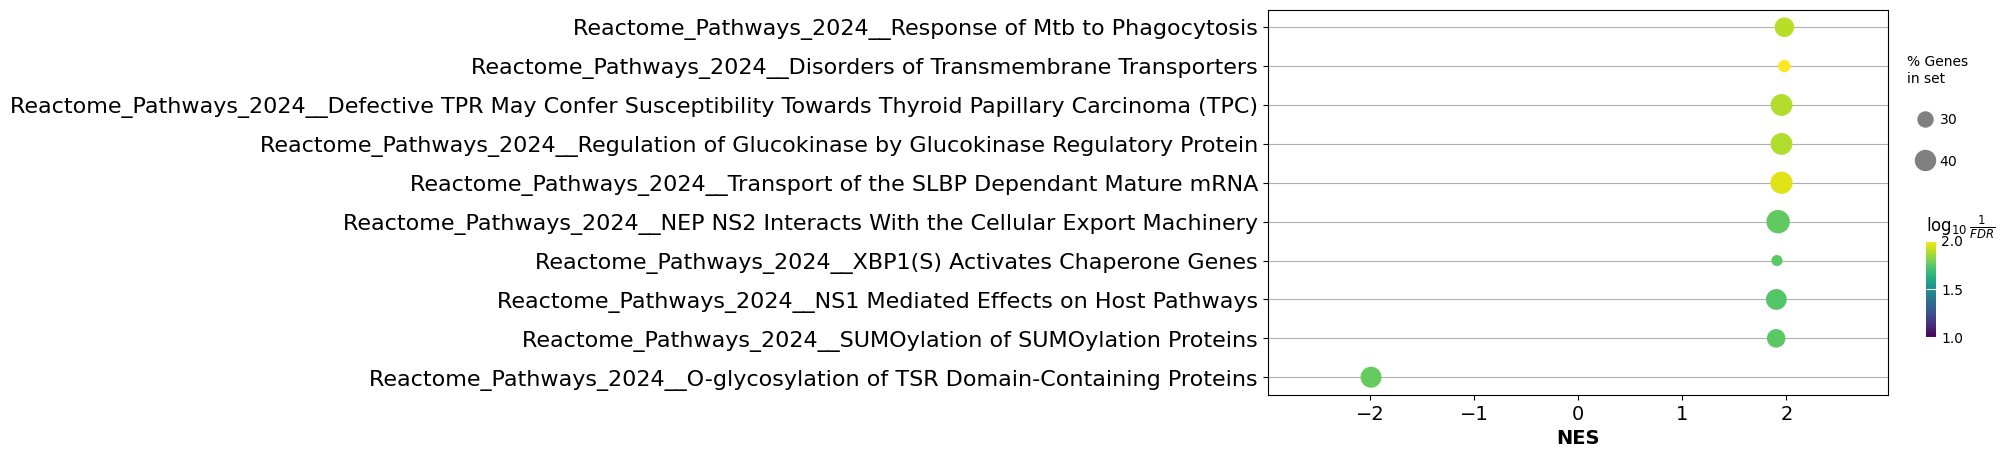

  Redundancy removal: 28 → 7 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Disorders of Transmembrane Transporters,1.979386,0.009802,32/129,32,SLC9A9;NUP155;NUP88;NUP93;ERLEC1;GCK;TPR;SLC20A2;APOA1;KCNJ11;PSMB2;NUP160;PSMA2;RANBP2;PSMD13;SLC3A1;BSG;PSMD7;DERL3;NUP54;SLC33A1;NUP37;ABCC8;RAE1;PSMA5;PSMD12;SEL1L;NUP85;NUP98;NUP50;NUP153;SLCO2A1
1,Reactome_Pathways_2024__Transport of the SLBP Dependant Mature mRNA,1.952424,0.011203,16/36,16,NUP155;NUP88;NUP93;TPR;NUP160;RANBP2;EIF4E;SLBP;NUP54;NUP37;RAE1;NUP85;NUP98;NUP50;NUP153;NCBP2
2,Reactome_Pathways_2024__Response of Mtb to Phagocytosis,1.980392,0.012674,9/23,9,MAPK1;HGS;KPNB1;CORO1A;RAB5A;TRIM27;KPNA1;ENO1;ATP6V1H
3,Reactome_Pathways_2024__O-glycosylation of TSR Domain-Containing Proteins,-1.992059,0.017188,13/31,13,ADAMTSL2;THBS1;THSD7B;THBS2;ADAMTS3;ADAMTS10;THSD7A;THSD1;ADAMTSL1;ADAMTSL3;THSD4;ADAMTS13;ADAMTS2
4,Reactome_Pathways_2024__XBP1(S) Activates Chaperone Genes,1.908955,0.017921,10/45,10,PPP2R5B;WFS1;TSPYL2;XBP1;HYOU1;SERP1;SSR1;DNAJB9;SEC31A;PDIA6
5,Reactome_Pathways_2024__Influenza Viral RNA Transcription and Replication,1.823686,0.038124,57/134,57,RPL15;NUP155;NUP88;NUP93;TPR;GRSF1;NUP160;RANBP2;NUP54;RPL35A;RPL4;NUP37;POLR2K;POLR2A;RPS4X;RAE1;IPO5;RPL39;RPS15A;RPL37;RPL31;NUP85;RPS17;RPS3;NUP98;NUP50;RPS6;RPS2;NUP153;HSP90AA1;RPL7;RPL26;GTF2F2;RPL38;RPL10A;RPL19;RPL5;RPL23;RPL18;NUP43;RPS24;RPL32;RPL24;RPS27;RPL6;RPL22;RPL22L1;RPS28;RPL9;RPS3A;RPL34;RPL21;NUP205;NUP62;RPS25;RPLP1;RPL12
6,Reactome_Pathways_2024__Regulation of HSF1-mediated Heat Shock Response,1.810251,0.042298,25/74,25,MAPK1;NUP155;NUP88;NUP93;BAG4;TPR;NUP160;RANBP2;GML;YWHAE;NUP54;NUP37;ST13;RAE1;RPA1;NUP85;MRPL18;NUP98;NUP50;NUP153;ATR;COL4A6;HSPA9;MAPK3;HSPA14



Top leading edge genes (reactome):


,gene,n_pathways
0,NUP155,4
1,NUP88,4
2,NUP93,4
3,TPR,4
4,NUP160,4
5,RANBP2,4
6,NUP54,4
7,NUP37,4
8,RAE1,4
9,NUP85,4


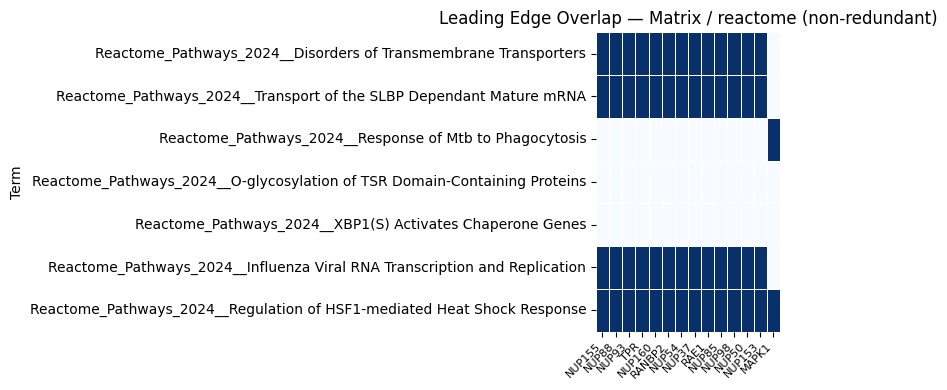


	######################
 	gobp 
	######################



,Term,NES,FDR q-val


  No significant GSEA terms for Matrix, skipping plots
  Redundancy removal: 0 → 0 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (gobp):


,gene,n_pathways



######################
 Microglia 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
1,SynGO_2024__Postsynaptic Ribosome CC,1.848467,0.017092
0,SynGO_2024__Extrinsic Component Of Postsynaptic Membrane (GO:0098890) CC,1.869155,0.025069


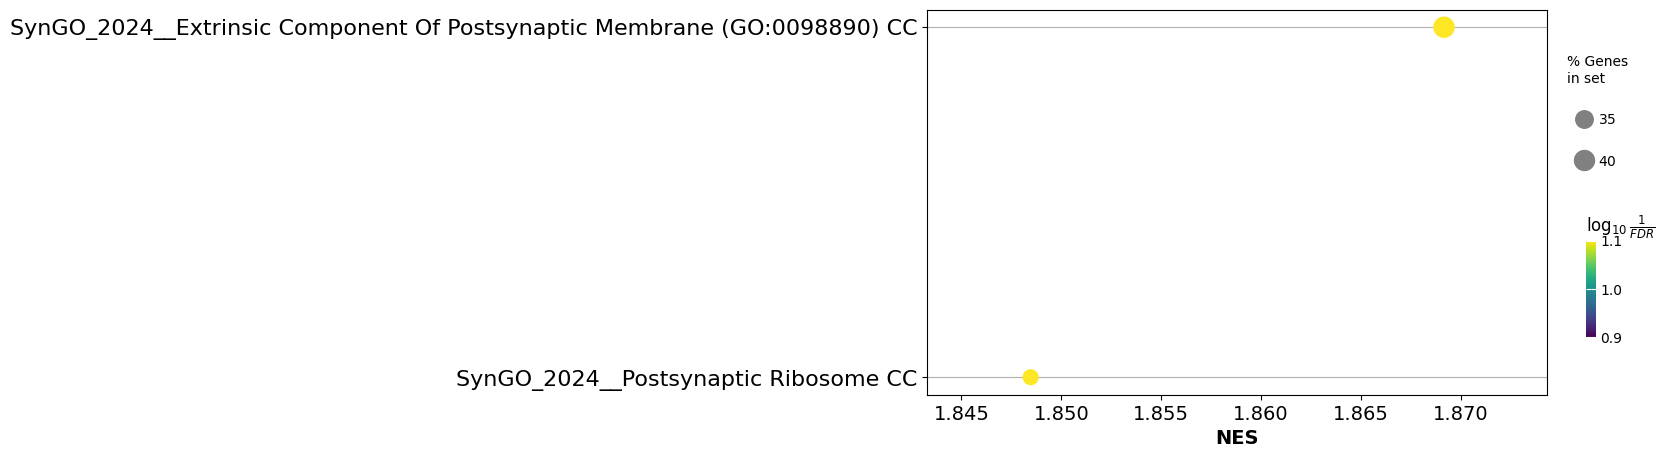

  Redundancy removal: 2 → 2 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,1.848467,0.017092,22/68,22,RPL18;RPS19;RPSA;RPL15;RPL13;RPS3;RPS5;RPS2;RPS14;RPS7;RPS10;RPL21;RPL10;RPS21;RPL29;RPS15A;RPLP0;RPL13A;RPS18;RPS13;RPL17;RPS28
1,SynGO_2024__Extrinsic Component Of Postsynaptic Membrane (GO:0098890) CC,1.869155,0.025069,3/7,3,C1QA;C1QC;C1QB



Top leading edge genes (curated):


,gene,n_pathways



	######################
 	reactome 
	######################



,Term,NES,FDR q-val
3,Reactome_Pathways_2024__Selenoamino Acid Metabolism,2.030564,0.002725
0,Reactome_Pathways_2024__SRP-dependent Cotranslational Protein Targeting to Membrane,2.076444,0.00327
2,Reactome_Pathways_2024__Eukaryotic Translation Elongation,2.036054,0.00327
1,Reactome_Pathways_2024__Peptide Chain Elongation,2.040886,0.004905
13,Reactome_Pathways_2024__Complement Cascade,1.953736,0.006384
12,Reactome_Pathways_2024__Regulation of Complement Cascade,1.953736,0.006384
4,Reactome_Pathways_2024__Selenocysteine Synthesis,1.988478,0.006757
5,Reactome_Pathways_2024__Eukaryotic Translation Termination,1.983432,0.006903
11,Reactome_Pathways_2024__Response of EIF2AK4 (GCN2) to Amino Acid Deficiency,1.954494,0.007266
6,Reactome_Pathways_2024__Viral mRNA Translation,1.972723,0.007629


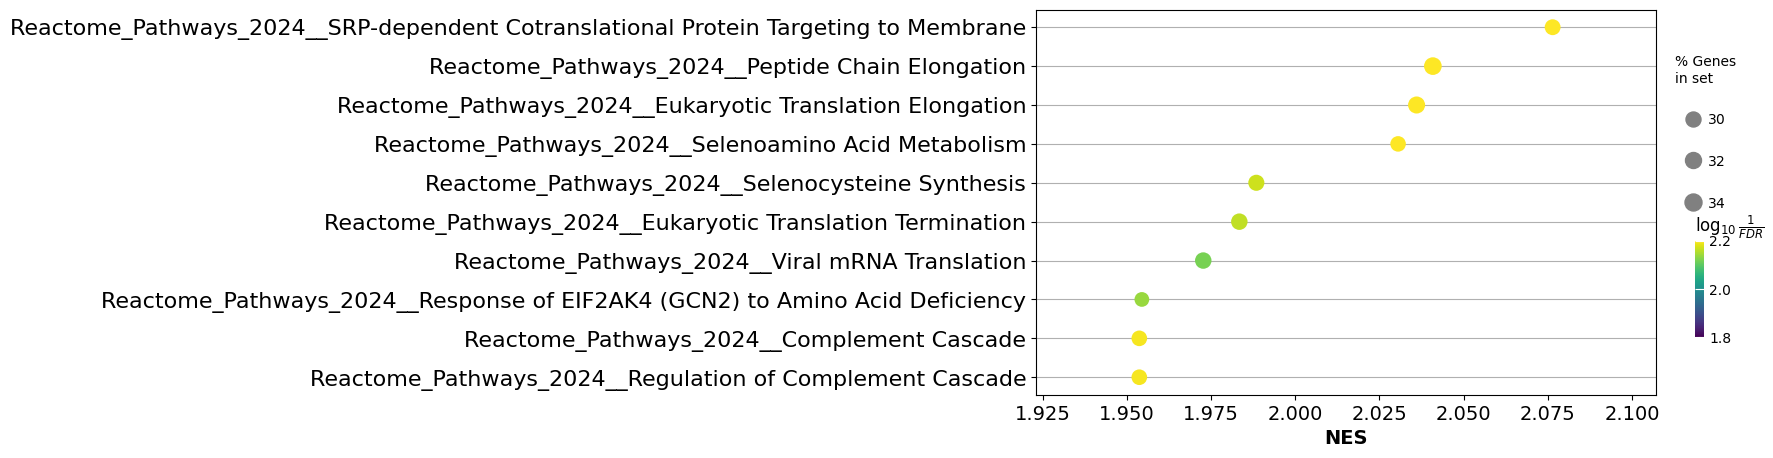

  Redundancy removal: 25 → 3 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Selenoamino Acid Metabolism,2.030564,0.002725,32/103,32,RPL7A;RPL18;RPS19;RPSA;RPL15;RPL13;RPS3;RPS5;RPS2;EPRS1;RPS14;FAU;RPS7;AIMP2;RPL3;EEF1E1;RPS10;RPL21;RPL18A;RPL10;RPS21;RPL29;RPS15A;RPS12;RPLP0;RPL13A;RPS18;RPS13;RPL17;RPL41;GSR;RPS28
1,Reactome_Pathways_2024__Complement Cascade,1.953736,0.006384,5/16,5,C1QA;C1QC;CD81;C1QB;C3AR1
2,Reactome_Pathways_2024__SARS-CoV-1 Modulates Host Translation Machinery,1.934289,0.009155,16/36,16,RPS19;RPSA;RPS3;RPS5;RPS2;RPS14;FAU;RPS7;EEF1A1;RPS10;RPS21;RPS15A;RPS12;RPS18;RPS13;RPS28



Top leading edge genes (reactome):


,gene,n_pathways
0,RPS19,2
1,RPSA,2
2,RPS3,2
3,RPS5,2
4,RPS2,2
5,RPS14,2
6,FAU,2
7,RPS7,2
8,RPS10,2
9,RPS21,2


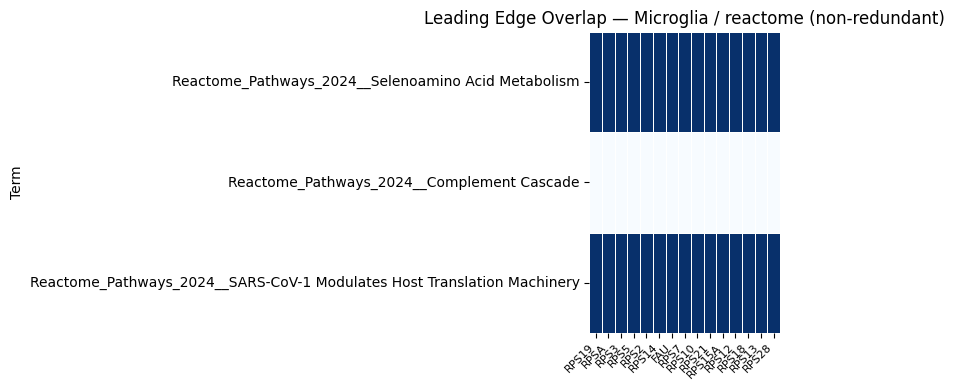


	######################
 	gobp 
	######################



,Term,NES,FDR q-val


  No significant GSEA terms for Microglia, skipping plots
  Redundancy removal: 0 → 0 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (gobp):


,gene,n_pathways



######################
 Neuron_non_MSN 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
4,SynGO_2024__Postsynaptic Ribosome CC,1.848811,0.002865
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,1.862086,0.003396
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.873121,0.00382
1,SynGO_2024__Presynaptic Ribosome CC,1.891137,0.007004
7,"SynGO_2024__Trans-Synaptic Signaling, Modulating Synaptic Transmission (GO:0099550) BP",1.796563,0.007131
0,SynGO_2024__Postsynapse To Nucleus Signaling Pathway (GO:0099527) BP,-1.995459,0.007827


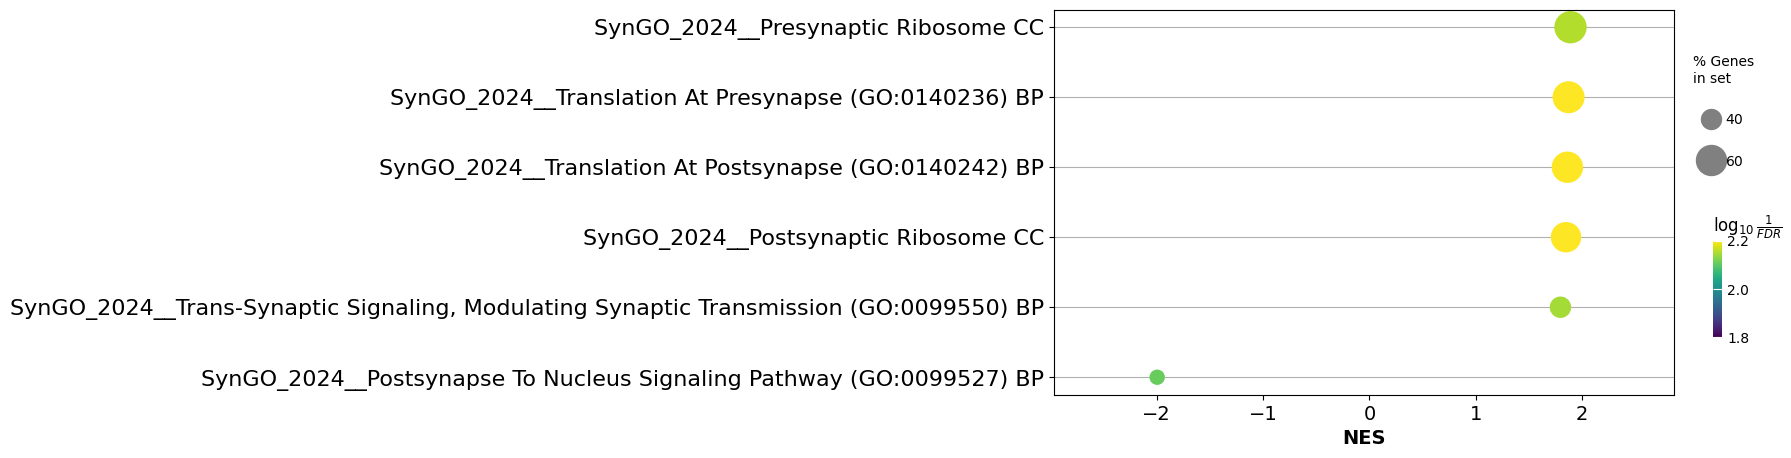

  Redundancy removal: 6 → 3 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,1.848811,0.002865,42/69,42,RPL35A;RPS3;RPL29;RPS10;RPS17;RPL6;RPL10;RPL10A;RPL22;RPS18;RPL15;RPL8;RPL9;RPL4;RPS14;RPL5;RPL31;RPS24;RPL37;RPL12;RPL28;RPL26;RPL7;RPL32;RPL35;RPL17;RPLP1;RPL38;RPL24;RPS23;RPL18;RPL27;RPS6;RPL34;RPS27A;RPLP0;RPL11;RPS19;RPS16;RPS8;RPS28;RPL30
1,"SynGO_2024__Trans-Synaptic Signaling, Modulating Synaptic Transmission (GO:0099550) BP",1.796563,0.007131,3/7,3,CBLN1;CBLN4;NRXN3
2,SynGO_2024__Postsynapse To Nucleus Signaling Pathway (GO:0099527) BP,-1.995459,0.007827,4/13,4,ABI1;NSMF;KPNA2;NRG1



Top leading edge genes (curated):


,gene,n_pathways



	######################
 	reactome 
	######################



,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Intraflagellar Transport,2.041694,0.003968
6,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,1.927898,0.010845
5,Reactome_Pathways_2024__Formation of a Pool of Free 40S Subunits,1.938052,0.010951
4,Reactome_Pathways_2024__Viral mRNA Translation,1.948136,0.011308
3,Reactome_Pathways_2024__Peptide Chain Elongation,1.951236,0.014284
12,Reactome_Pathways_2024__Nonsense Mediated Decay (NMD) Independent of the Exon Junction Complex (EJC),1.886003,0.014363
10,Reactome_Pathways_2024__Response of EIF2AK4 (GCN2) to Amino Acid Deficiency,1.893023,0.01446
9,Reactome_Pathways_2024__GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,1.894394,0.016168
15,Reactome_Pathways_2024__Selenocysteine Synthesis,1.869255,0.017458
8,Reactome_Pathways_2024__Eukaryotic Translation Termination,1.896759,0.017685


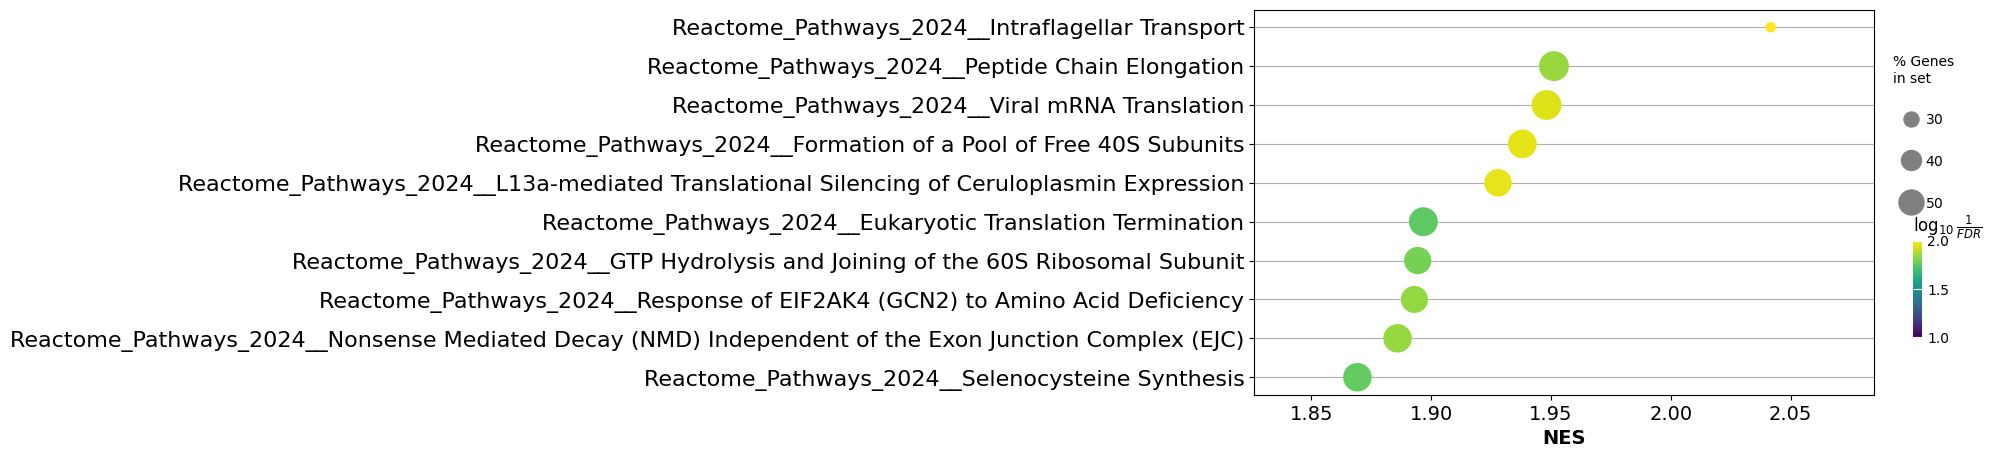

  Redundancy removal: 14 → 2 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Intraflagellar Transport,2.041694,0.003968,10/47,10,DYNLT2B;IFT88;DYNC2H1;IFT74;IFT20;DYNC2LI1;IFT52;IFT122;IFT46;TUBB3
1,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,1.927898,0.010845,60/109,60,EIF3M;RPL35A;RPS3;RPL39;RPL39L;RPL29;RPS10;RPS4X;RPS17;RPL6;RPL10;RPL10A;RPL26L1;RPL22;RPS18;RPL15;EIF4B;RPL8;RPS12;RPL9;RPL41;RPL4;EIF4H;RPS14;RPL5;RPL31;RPS24;RPL37;RPL19;RPL18A;RPL12;EIF3D;EIF4E;RPL28;RPL26;RPL7;RPL32;EIF3A;RPL35;EIF3J;RPL17;RPL3;RPLP1;RPL38;RPL24;RPS23;RPL18;RPL27;RPS6;EIF3I;RPL34;EIF3L;RPS27A;RPLP0;RPL11;RPS19;RPS16;RPS8;RPS28;RPL30



Top leading edge genes (reactome):


,gene,n_pathways



	######################
 	gobp 
	######################



...

,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (gobp):


,gene,n_pathways



######################
 OPC 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,MSigDB_Hallmark_2020__Interferon Alpha Response,-2.15899,0.0
4,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.968536,0.003582
3,SynGO_2024__Presynaptic Ribosome CC,1.980421,0.004094
1,SynGO_2024__Postsynaptic Ribosome CC,2.041301,0.004094
2,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,1.980826,0.006141
7,"SynGO_2024__Postsynaptic Specialization, Intracellular Component (GO:0099091) CC",1.83305,0.013818
6,SynGO_2024__Transmitter-Gated IC Activity Involved In Regulation Of Postsynaptic Membrane Potential (GO:1904315) BP,1.841415,0.015148
8,SynGO_2024__Ligand-Gated IC Activity Involved In Regulation Of Presynaptic Membrane Potential (GO:0099507) BP,1.805301,0.016815
9,MSigDB_Hallmark_2020__Myc Targets V1,1.784274,0.019319
12,SynGO_2024__Integral Component Of Presynaptic Membrane (GO:0099056) CC,1.767327,0.020061


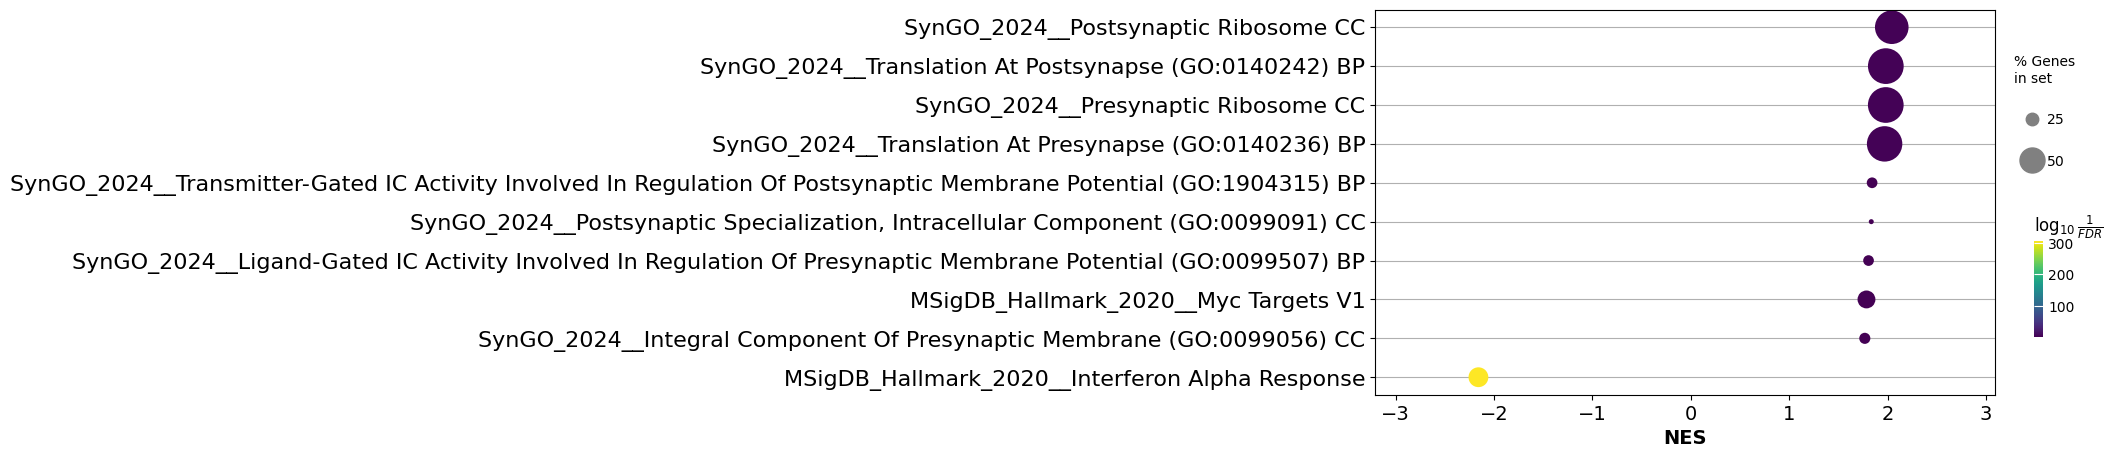

  Redundancy removal: 13 → 9 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,MSigDB_Hallmark_2020__Interferon Alpha Response,-2.15899,0.0,21/53,21,IRF9;IFI44;OAS1;RSAD2;IFIT3;HERC6;PARP14;EPSTI1;ELF1;DDX60;EIF2AK2;TRIM25;STAT2;SP110;ADAR;USP18;OGFR;PARP9;CMTR1;NCOA7;PLSCR1
1,SynGO_2024__Translation At Presynapse (GO:0140236) BP,1.968536,0.003582,34/48,34,RPL18;RPL15;RPLP0;RPL29;RPS27A;RPS26;RPS13;RPL24;RPL27A;RPL8;RPL9;RPL5;RPS11;RPL26;RPL10A;RPL17;RPL34;RPS15A;RPL36;RPL28;RPLP2;RPL37;RPL35;RPL14;RPS5;RPS10;RPL6;RPL7;RPL10;RPS16;RPS24;RPL11;RPS14;RPL12
2,"SynGO_2024__Postsynaptic Specialization, Intracellular Component (GO:0099091) CC",1.83305,0.013818,1/10,1,GPHN
3,SynGO_2024__Transmitter-Gated IC Activity Involved In Regulation Of Postsynaptic Membrane Potential (GO:1904315) BP,1.841415,0.015148,3/14,3,GRIA2;GABRA3;GRIA4
4,MSigDB_Hallmark_2020__Myc Targets V1,1.784274,0.019319,64/179,64,ODC1;CCT2;RSL1D1;RPL18;PSMD8;RPLP0;POLD2;RPS2;HNRNPC;PSMD14;EIF4A1;EIF1AX;PA2G4;GNL3;ACP1;CANX;RPS6;HSPD1;H2AZ1;CTPS1;HPRT1;SET;HNRNPA3;TRA2B;SNRPA;AP3S1;TFDP1;SNRPD1;HDDC2;CCT4;RPL34;CAD;CUL1;PRDX3;BUB3;EIF4E;GOT2;IMPDH2;G3BP1;RAD23B;SNRPA1;PTGES3;RACK1;SERBP1;HNRNPD;COX5A;CCT7;COPS5;CBX3;PSMA6;HNRNPR;XPO1;NAP1L1;PSMB2;HSP90AB1;EEF1B2;DDX21;RPL14;PGK1;TOMM70;PPM1G;ORC2;FAM120A;RPS5
5,SynGO_2024__Integral Component Of Presynaptic Membrane (GO:0099056) CC,1.767327,0.020061,14/63,14,GRIA2;ABCC8;SLC6A11;KCNJ11;VAPA;TRPC1;GABBR2;FXYD6;SCN1A;GRIA1;FLRT2;CADM1;ERBB4;CNTNAP2
6,SynGO_2024__Regulation Of Postsynaptic Neurotransmitter Receptor Activity (GO:0098962) BP,-1.846887,0.020388,8/17,8,CACNG4;NRXN2;CNIH4;CACNG7;CACNG5;BEGAIN;NOTCH1;SHISA9
7,SynGO_2024__Synapse (GO:0045202) CC,1.769404,0.021267,80/245,80,SLC6A11;RPL18;GNG2;VCP;RPL15;RPLP0;RPS4X;NCAN;PPFIA2;ABLIM3;RPS2;HABP4;RPL29;QKI;EIF1AX;RPS27A;GDI2;GABRA3;CAPRIN1;RPS6KA6;RPS26;RPS15;RPS13;GRN;EIF2S3;RPL24;RPL3;FLOT2;RPL27A;RPL8;EEF2;RPLP1;HNRNPL;RPL9;TBC1D24;TDRD6;PPFIA3;NUDT3;RPL5;RPS11;BCAS1;ARHGDIA;GPC6;RPL26;RPL10A;CRELD1;CC2D1A;NUFIP1;RPL31;RTN3;PDE10A;TTYH1;ETFA;EIF3I;RPS9;EIF1AY;HAPLN1;RPL17;RPL18A;SLC16A1;RPL34;RPS17;GNG4;RPS15A;RPS3A;RPL19;CYFIP2;FCHO2;PURG;RPL36;RPL28;EIF5B;HNRNPD;RPLP2;PTPRZ1;CNNM2;RPL37;RPL35;DPYSL3;ARFGAP3
8,SynGO_2024__Integral Component Of Postsynaptic Membrane (GO:0099055) CC,1.692793,0.041872,14/72,14,GRIA2;SLC6A11;NRCAM;PTCH1;TRPC1;GABBR2;ITGB4;FXYD6;CANX;ADGRL3;GRIA1;FLRT2;CADM1;KCNQ2



Top leading edge genes (curated):


,gene,n_pathways
0,RPL18,3
1,RPLP0,3
2,RPL34,3
3,GRIA2,3
4,SLC6A11,3
5,RPL15,2
6,RPL29,2
7,RPS27A,2
8,RPS26,2
9,RPS13,2


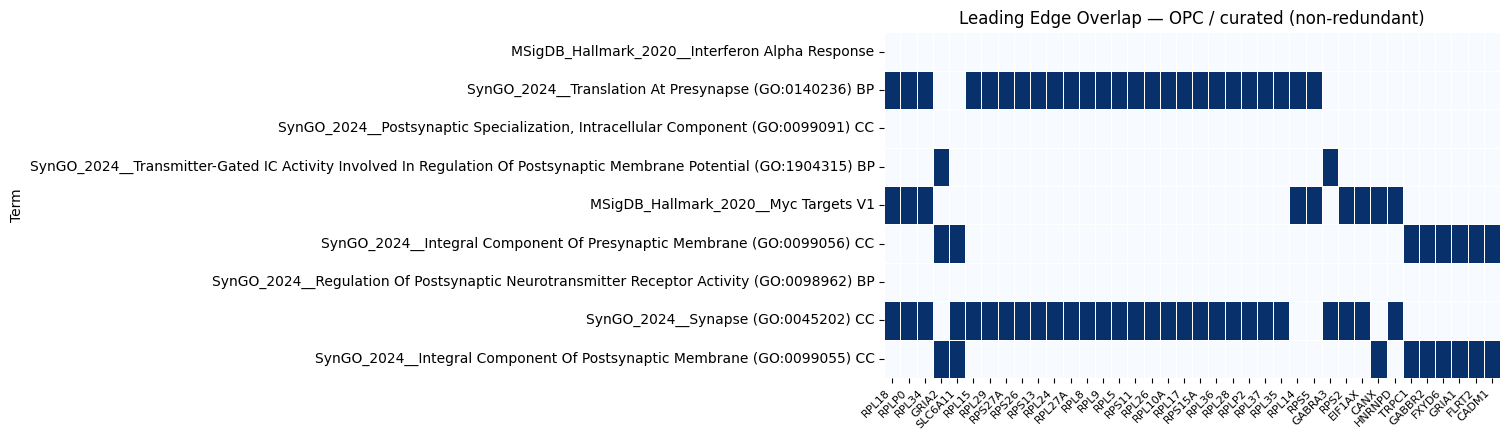


	######################
 	reactome 
	######################



,Term,NES,FDR q-val
1,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.157728,0.001071
2,Reactome_Pathways_2024__Cap-dependent Translation Initiation,2.143664,0.001071
3,Reactome_Pathways_2024__Eukaryotic Translation Initiation,2.143664,0.001071
0,Reactome_Pathways_2024__GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,2.158065,0.002141
4,Reactome_Pathways_2024__Formation of a Pool of Free 40S Subunits,2.092931,0.003212
6,Reactome_Pathways_2024__Peptide Chain Elongation,2.081462,0.003365
7,Reactome_Pathways_2024__MECP2 Regulates Neuronal Receptors and Channels,2.064058,0.003747
5,Reactome_Pathways_2024__Eukaryotic Translation Elongation,2.085113,0.003925
9,Reactome_Pathways_2024__Eukaryotic Translation Termination,2.050877,0.003961
10,Reactome_Pathways_2024__Viral mRNA Translation,2.039559,0.00399


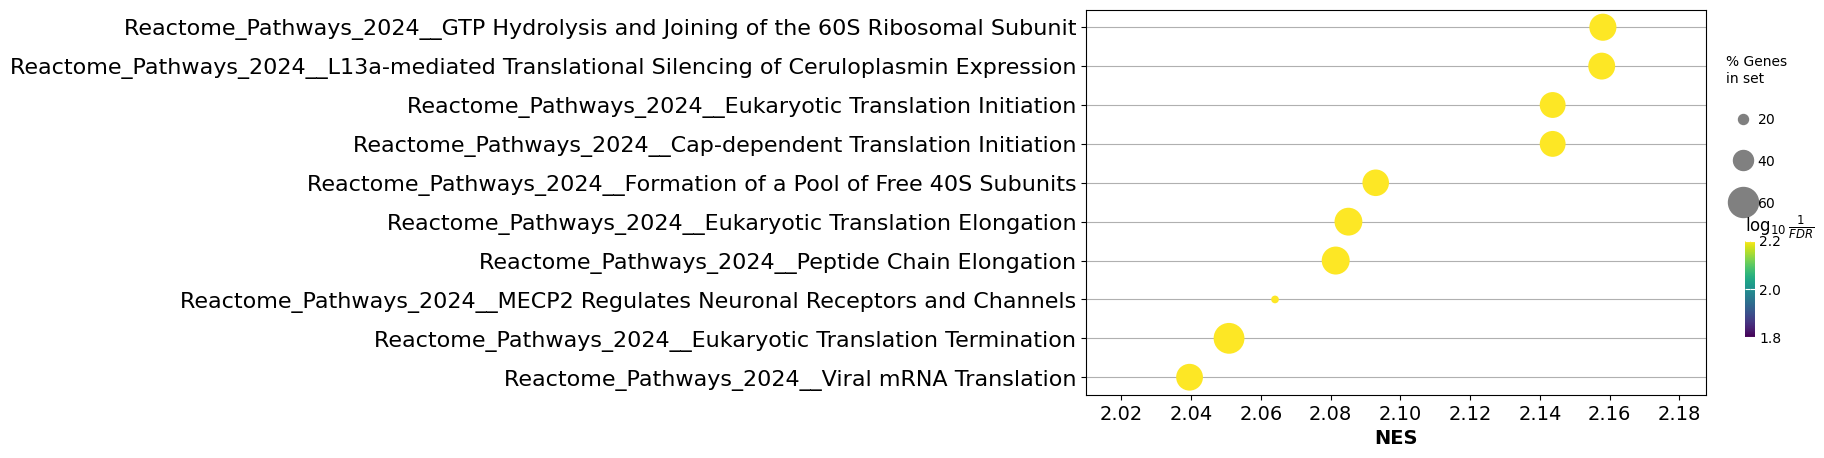

  Redundancy removal: 25 → 5 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.157728,0.001071,57/106,57,RPL18;RPL15;EIF4B;RPLP0;RPS4X;RPS2;EIF4A1;RPL29;EIF1AX;RPS27A;EIF4G1;RPS26;RPS15;RPS13;RPS6;EIF2S3;RPL24;RPL3;RPL27A;RPL8;RPLP1;RPL9;RPL7A;RPL5;RPS11;RPS8;EIF3H;RPL26;RPL10A;RPL31;EIF3M;EIF3I;RPS9;RPL17;RPL18A;RPL34;RPS17;EIF3E;RPS15A;RPS3A;RPL19;EIF4E;RPL36;RPL28;RPL41;RPLP2;RPL37;RPL35;EIF3A;RPL14;RPS7;FAU;RPL30;RPL22L1;RPS5;EIF4A2;RPL36A
1,Reactome_Pathways_2024__MECP2 Regulates Neuronal Receptors and Channels,2.064058,0.003747,2/13,2,GRIA2;FKBP5
2,Reactome_Pathways_2024__Long-term Potentiation,1.963554,0.011491,2/16,2,GRIA2;LRRC7
3,Reactome_Pathways_2024__Translation Initiation Complex Formation,1.874949,0.035923,23/58,23,EIF4B;RPS4X;RPS2;EIF4A1;EIF1AX;RPS27A;EIF4G1;RPS26;RPS15;RPS13;RPS6;EIF2S3;RPS11;RPS8;EIF3H;EIF3M;EIF3I;RPS9;RPS17;EIF3E;RPS15A;RPS3A;EIF4E
4,Reactome_Pathways_2024__Metabolism of Amino Acids and Derivatives,1.842318,0.047767,97/248,97,SLC6A11;SAT1;ODC1;ALDH7A1;RPL18;RPL15;PSMD8;RPLP0;RPS4X;AASS;NNMT;GSR;RPS2;IVD;PSMD14;BCKDHB;SRR;PPM1K;RPL29;CTH;GLS;BCAT1;RPS27A;AZIN1;RPS26;GRHPR;RPS15;RPS13;RPS6;RPL24;RPL3;PXMP2;GATM;PSMC5;RPL27A;RPL8;RPLP1;PAPSS2;DHTKD1;RPL9;LARS1;RPL7A;PSMD11;ACAT1;RPL5;RPS11;ALDH6A1;RPS8;RPL26;RPL10A;RPL31;PHYKPL;TST;SLC6A8;RPS9;RPL17;RPL18A;PAPSS1;RPL34;RPS17;RPS15A;RPS3A;SLC25A12;RPL19;RIMKLB;GOT2;SUOX;SMOX;DIO2;RPL36;GLUD1;KYAT3;RPL28;OAT;RPL41;RPLP2;ADO;GCAT;PSMA6;RPL37;PSMB2;RPL35;RPL14;RPS7;AMT;MCCC1;FAU;PSMC1;RPL30;RPL22L1;RPS5;RPL36A;ETHE1;SCLY;CDO1;CKB;QARS1



Top leading edge genes (reactome):


,gene,n_pathways
0,RPS4X,3
1,RPS2,3
2,RPS27A,3
3,RPS26,3
4,RPS15,3
5,RPS13,3
6,RPS6,3
7,RPS11,3
8,RPS8,3
9,RPS9,3


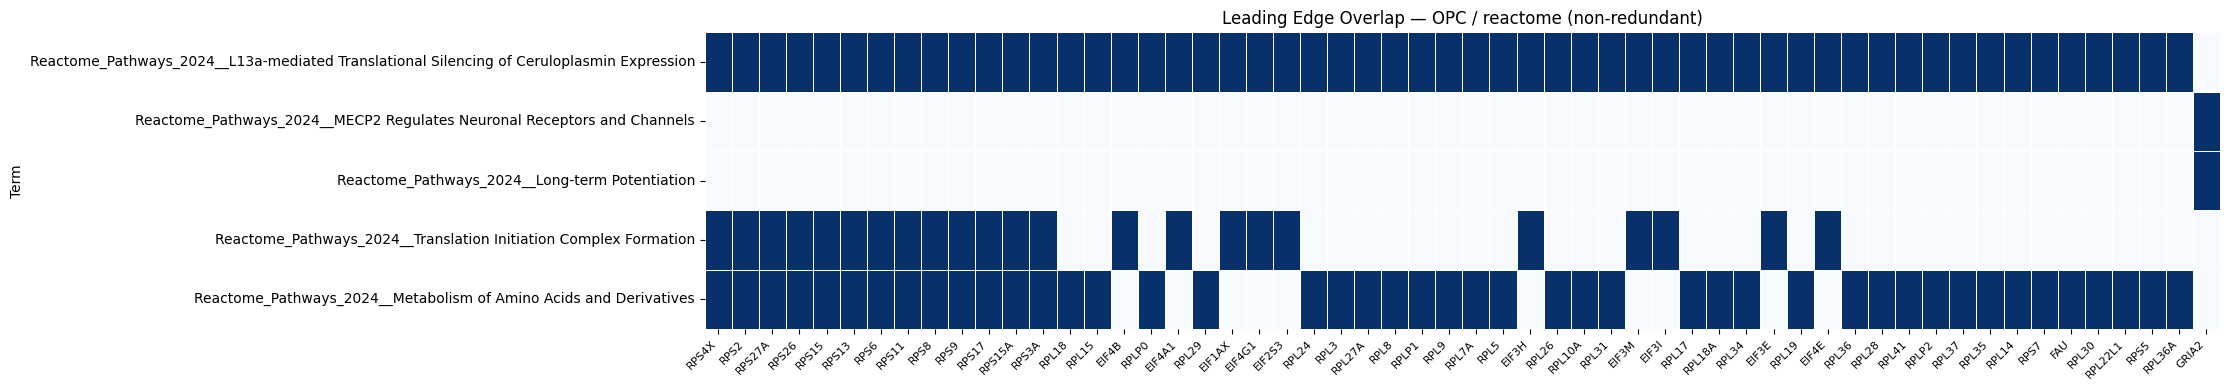


	######################
 	gobp 
	######################



,Term,NES,FDR q-val


  No significant GSEA terms for OPC, skipping plots
  Redundancy removal: 0 → 0 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes



Top leading edge genes (gobp):


,gene,n_pathways



######################
 Oligodendrocyte 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.446269,0.0
1,SynGO_2024__Presynaptic Ribosome CC,2.358372,0.0
2,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.341912,0.0
3,MSigDB_Hallmark_2020__UV Response Up,2.330626,0.0
4,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.3241,0.0
5,MSigDB_Hallmark_2020__Interferon Gamma Response,2.212285,0.0
6,MSigDB_Hallmark_2020__Estrogen Response Late,2.154044,0.0
7,SynGO_2024__Synapse (GO:0045202) CC,2.150752,0.0
8,MSigDB_Hallmark_2020__Oxidative Phosphorylation,2.092843,0.0
9,MSigDB_Hallmark_2020__KRAS Signaling Up,2.078367,0.0


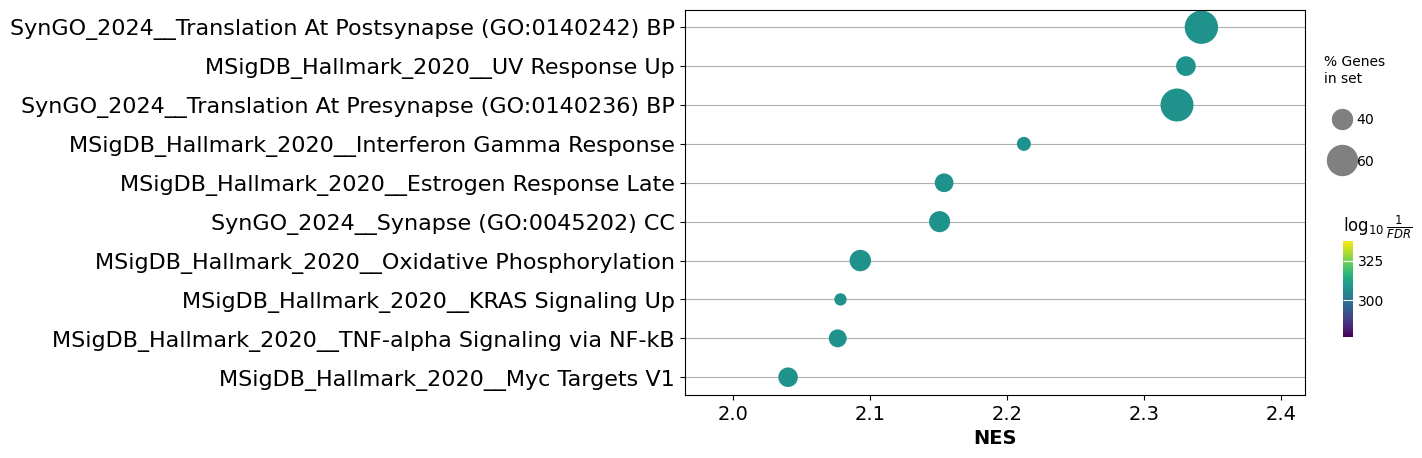

  Redundancy removal: 26 → 23 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,2.446269,0.0,45/69,45,RPS5;RPL8;RPS16;RPL18;RPS15;RPL29;RPL35;RPS3;RPS2;RPL37A;RPS27A;RPL27A;RPS8;RPL36;RPS19;RPL13;RPL12;RPS17;RPS21;RPL15;RPL4;RPS20;RPL5;RPL14;RPL21;RPL13A;RPL24;RPL28;RPS14;RPS10;RPLP0;RPL17;RPL35A;RPL27;RPL22;RPL9;RPS6;RPL10A;RPS15A;RPL11;RPS13;RPLP2;RPS7;RPL30;RPL34
1,MSigDB_Hallmark_2020__UV Response Up,2.330626,0.0,48/122,48,HLA-F;CHKA;ENO2;TAP1;ATP6V1F;KCNH2;GRINA;HNRNPU;TYRO3;NR4A1;H2AX;MRPL23;EPHX1;BSG;HYAL2;PRKACA;NPTX2;SLC6A8;SIGMAR1;NFKBIA;ONECUT1;CDK2;FOS;BTG3;BTG2;ARRB2;RPN1;SLC25A4;BMP2;GLS;CDKN1C;SELENOW;GGH;CCND3;FKBP4;CCNE1;ALDOA;CDO1;RHOB;CYB5B;ASNS;IRF1;IL6ST;CDKN2B;PDLIM3;CASP3;TACR3;PLCL1
2,MSigDB_Hallmark_2020__Interferon Gamma Response,2.212285,0.0,30/107,30,HLA-A;HLA-B;PSMB8;SAMHD1;PSMB9;TAP1;B2M;MVP;SOCS3;ARID5B;MT2A;TAPBP;TXNIP;IFI35;NFKBIA;APOL6;PDE4B;NLRC5;ISG20;STAT3;STAT1;UBE2L6;OGFR;TNFAIP2;STAT2;DDX60;IRF1;CASP3;RAPGEF6;HERC6
3,MSigDB_Hallmark_2020__Estrogen Response Late,2.154044,0.0,39/104,39,DHCR7;FKBP5;RAB31;ELOVL5;DYNLT3;SEMA3B;SLC22A5;IDH2;ADD3;IL17RB;HPRT1;LLGL2;SGK1;ALDH3A2;ZFP36;ETFB;CKB;DCXR;IGSF1;SERPINA5;DNAJC1;FOS;BTG3;ABHD2;ISG20;SLC1A4;SIAH2;PLXNB1;MOCS2;BLVRB;DLG5;FABP5;CCN5;FKBP4;IL6ST;SLC2A8;MEST;TOB1;PDLIM3
4,SynGO_2024__Synapse (GO:0045202) CC,2.150752,0.0,99/235,99,CLU;CDH11;PLD1;RPS5;QKI;RPL8;HABP4;GNG7;PHB1;RPS16;RPL18A;RPL18;NPTX2;CDH23;RPS15;RPL29;SPARC;ARFGAP3;RPL35;RPS3;MYLK;CC2D1A;RABAC1;FUBP1;AP2M1;RPL3;GPC1;RPS2;GNB2;RPL37A;RPS27A;RPL27A;RPL36;ADGRB2;RPS19;RPL13;VLDLR;RPL12;RPS17;RPS21;EIF2S2;RPL15;PGRMC2;RPS20;RPL5;RPL14;RPL21;EIF3D;TTYH1;RPL13A;RPL24;RPL28;ARHGDIA;RPS14;CORIN;RPS10;BCAS1;RPLP0;RPS6KA1;RHOB;RPL17;FZD5;HNRNPA0;HNRNPUL1;RPL35A;EIF1AX;YBX1;MLF2;RPL27;RPL19;RPL22;RAB18;STX2;GDI2;YWHAQ;RPL9;RPL10A;PPP2R1A;RPS15A;HNRNPM;PPP2R2A;EEF2;WASF2;RPL11;BIN1;RPS13;RPLP2;RPS7;RPL30;RPL34;GNAZ;PPFIA3;RPS9;NAPG;DAAM1;EPS15;TDRD6;RAB21;PRKAR1A
5,MSigDB_Hallmark_2020__Oxidative Phosphorylation,2.092843,0.0,84/196,84,MPC1;COX5B;ATP5F1D;ATP6V1F;ATP6V0B;ALDH6A1;IDH2;NDUFB4;NDUFAB1;GPX4;NDUFS8;ATP6AP1;NDUFC2;TOMM22;ETFB;COX8A;COX6A1;PDK4;NDUFV2;HSD17B10;ATP5F1C;ATP5MC1;IDH3A;SLC25A5;COX6B1;ATP6V1E1;ATP6V0C;SLC25A4;OAT;LDHA;PDHA1;NDUFB7;PDHB;ATP5ME;NDUFB1;SDHB;UQCRC2;MRPS30;MTRR;COX7B;NDUFB5;UQCRC1;ACADSB;ATP5MC3;ECI1;GOT2;ATP5F1A;PHYH;AIFM1;VDAC3;BCKDHA;PHB2;CYB5R3;NDUFS1;NDUFS2;COX4I1;UQCRB;ATP5F1B;ECHS1;ATP5MC2;ALAS1;TIMM8B;SDHC;CYC1;RETSAT;NDUFB2;NDUFA1;NDUFA6;SUCLG1;PRDX3;SLC25A3;CASP7;UQCR10;UQCR11;MDH2;ATP5PB;TIMM13;NDUFA8;HADHB;TIMM50;MRPL34;GRPEL1;NDUFB6;VDAC2
6,MSigDB_Hallmark_2020__KRAS Signaling Up,2.078367,0.0,22/89,22,PSMB8;BIRC3;SPRY2;SCN1B;HSD11B1;SEMA3B;ETV5;LCP1;MMD;MAP7;MYCN;ALDH1A3;VWA5A;KIF5C;BMP2;APOD;GFPT2;ETS1;ANKH;MTMR10;TRAF1;SNAP91
7,MSigDB_Hallmark_2020__TNF-alpha Signaling via NF-kB,2.076348,0.0,38/106,38,BIRC3;MAFF;TAP1;SGK1;SOCS3;STAT5A;BCL6;ZFP36;NR4A1;PMEPA1;PER1;NFKBIA;FOS;BTG3;VEGFA;MAP2K3;BTG2;PDE4B;KLF9;CEBPD;PFKFB3;BMP2;IER2;GFPT2;SPSB1;DUSP1;GADD45B;KLF6;PDLIM5;TRAF1;CCNL1;TNFAIP2;PTPRE;RHOB;IRF1;IL6ST;PLPP3;ICOSLG
8,MSigDB_Hallmark_2020__Myc Targets V1,2.04008,0.0,77/197,77,RPS5;MRPS18B;SNRPD2;NDUFAB1;HPRT1;HNRNPU;PSMA7;SF3A1;MRPL23;RPL18;IMPDH2;PSMD3;RPS3;HDGF;CDK2;GLO1;RPS2;EPRS1;PRDX4;NHP2;GSPT1;SSB;KARS1;LDHA;SNRPG;PSMA6;EIF2S2;LSM2;RPL14;SRSF1;EIF3D;NOLC1;PSMD8;KPNB1;PCNA;CCT7;CANX;RPS10;SET;BUB3;RPLP0;XRCC6;GOT2;EIF1AX;LSM7;POLD2;VDAC3;RUVBL2;RPL22;PHB2;HNRNPR;YWHAQ;CCT3;RPS6;CCNA2;UBA2;EIF4A1;G3BP1;CYC1;PGK1;CUL1;RPL34;SERBP1;PRDX3;PSMB3;RAN;SLC25A3;C1QBP;CNBP;AIMP2;PTGES3;MAD2L1;H2AZ1;RPL6;ORC2;ODC1;EIF2S1
9,MSigDB_Hallmark_2020__Cholesterol Homeostasis,2.001556,0.000511,21/60,21,DHCR7;CHKA;PMVK;CLU;ALDOC;MVK;SEMA3B;ERRFI1;CYP51A1;PCYT2;SC5D;FABP5;IDI1;FASN;ETHE1;PDK3;GSTM2;STARD4;SCD;MVD;ABCA2



Top leading edge genes (curated):


,gene,n_pathways
0,TAP1,7
1,FOS,6
2,BMP2,6
3,BTG2,5
4,CCND3,5
...,...,...
221,CD81,2
222,CDKN2A,2
223,SLC19A2,2
224,HIBCH,2


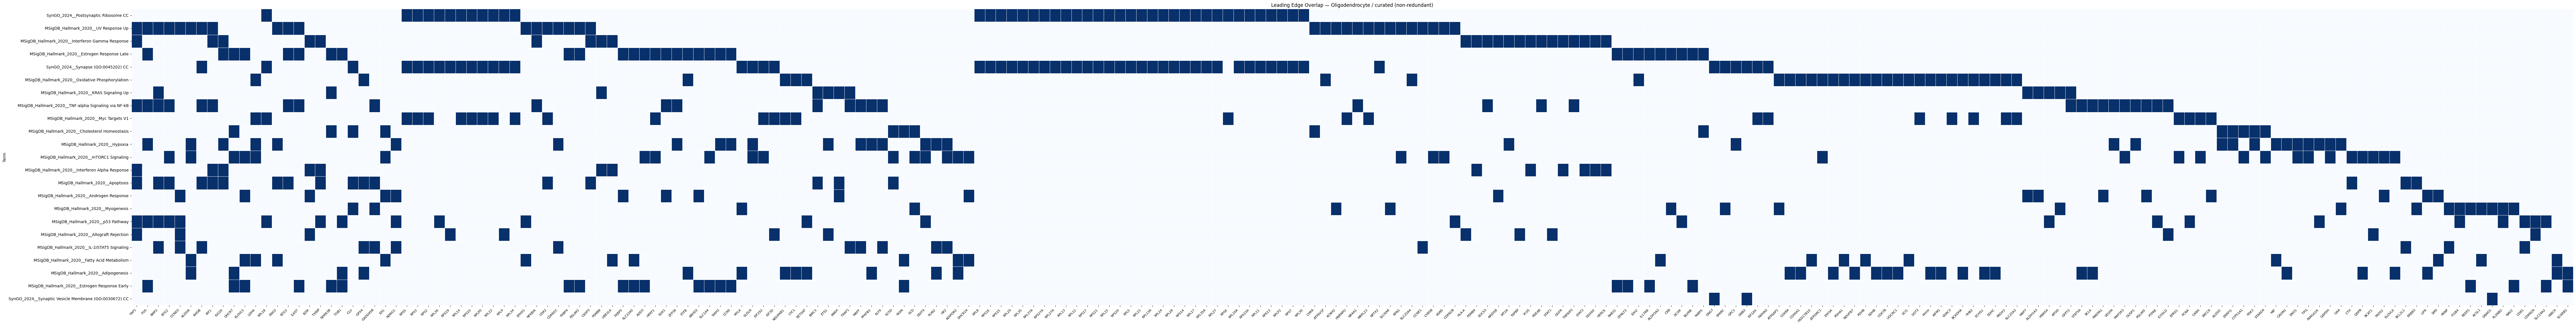


	######################
 	reactome 
	######################



,Term,NES,FDR q-val
0,Reactome_Pathways_2024__ER-Phagosome Pathway,2.393254,0.0
18,Reactome_Pathways_2024__Immunoregulatory Interactions Between a Lymphoid and a non-Lymphoid Cell,2.244683,0.0
17,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.257515,0.0
16,Reactome_Pathways_2024__GTP Hydrolysis and Joining of the 60S Ribosomal Subunit,2.260276,0.0
15,Reactome_Pathways_2024__Cap-dependent Translation Initiation,2.26201,0.0
...,...,...,...
62,Reactome_Pathways_2024__HIV Infection,1.792388,0.04497
64,Reactome_Pathways_2024__Gluconeogenesis,1.789092,0.0455
65,Reactome_Pathways_2024__Muscle Contraction,1.786969,0.045615
66,Reactome_Pathways_2024__Degradation of Cysteine and Homocysteine,1.782626,0.04736


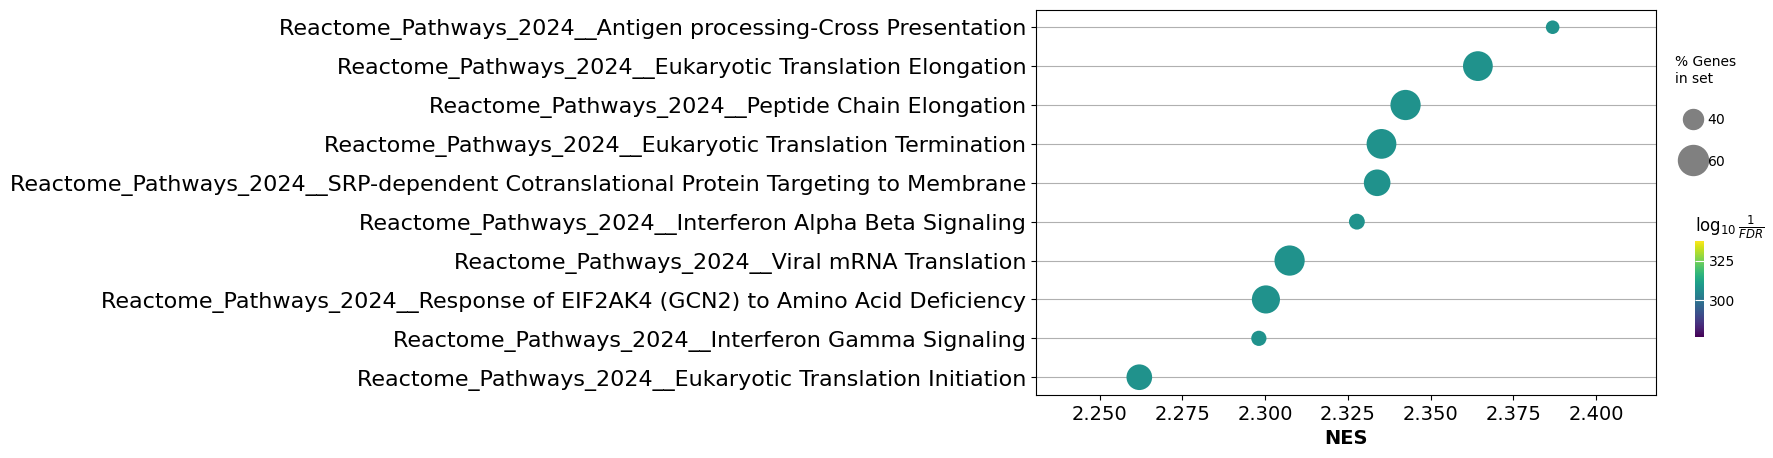

  Redundancy removal: 68 → 36 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__ER-Phagosome Pathway,2.393254,0.0,19/66,19,HLA-A;HLA-C;HLA-B;HLA-F;HLA-E;TAP1;PSMD13;B2M;PSMA7;TAPBP;PSMB6;PSMD3;TAP2;RPS27A;PSMA6;SNAP23;PSMD8;PSMC5;UBC
1,Reactome_Pathways_2024__Interferon Gamma Signaling,2.298109,0.0,14/46,14,HLA-A;HLA-C;HLA-B;HLA-F;HLA-E;B2M;SOCS3;TRIM46;MT2A;GBP1;TRIM8;MAPK3;TRIM62;STAT1
2,Reactome_Pathways_2024__Peptide Chain Elongation,2.342404,0.0,52/86,52,RPS5;RPL8;RPS16;RPL18A;RPL18;RPS15;RPL41;RPL29;RPL35;RPS3;RPL3;FAU;RPS2;RPL37A;RPS27A;RPL27A;RPS8;RPL36;RPS19;RPL13;RPL12;RPS17;RPS21;RPL15;RPL4;RPS20;RPL5;RPL14;RPL21;RPL7A;RPL13A;RPL24;RPL28;RPS14;RPS10;RPLP0;RPL17;RPL35A;RPL27;RPL19;RPL22;RPL9;RPS6;RPL10A;RPS15A;EEF2;RPL11;RPS13;RPLP2;RPS7;RPL30;RPL34
3,Reactome_Pathways_2024__Interferon Alpha Beta Signaling,2.327707,0.0,13/41,13,HLA-A;HLA-C;HLA-B;PSMB8;HLA-F;HLA-E;SAMHD1;RNASEL;SOCS3;IFI35;ISG20;STAT1;RPS27A
4,"Reactome_Pathways_2024__Antigen Presentation Folding, Assembly and Peptide Loading of Class I MHC",2.265449,0.0,14/28,14,HLA-A;HLA-C;HLA-B;HLA-F;HLA-E;TAP1;B2M;TAPBP;TAP2;ERAP2;CANX;ERAP1;SEC31A;SEC23A
5,Reactome_Pathways_2024__Immunoregulatory Interactions Between a Lymphoid and a non-Lymphoid Cell,2.244683,0.0,10/25,10,HLA-A;HLA-C;HLA-B;HLA-F;HLA-E;B2M;CD81;CD200;KLRD1;CD22
6,Reactome_Pathways_2024__Host Interactions of HIV Factors,2.039177,0.001914,27/111,27,HLA-A;HMGA1;PSMD13;B2M;PSIP1;PSMA7;PAK2;ELOB;PSMB6;PSMD3;SLC25A5;BANF1;AP2M1;SLC25A4;AP1B1;RPS27A;PSMA6;ELMO1;PSMD8;KPNB1;PSMC5;UBC;NUP85;TPR;AP1S1;NUP188;RAC1
7,Reactome_Pathways_2024__Triglyceride Catabolism,2.031985,0.002273,8/14,8,LIPE;FABP3;PRKACA;PRKACB;PLIN3;PPP1CA;ABHD5;FABP5
8,Reactome_Pathways_2024__DAP12 Interactions,2.025949,0.002607,4/24,4,HLA-C;HLA-B;HLA-E;B2M
9,Reactome_Pathways_2024__Cholesterol Biosynthesis,2.018428,0.00286,12/26,12,DHCR7;PMVK;MVK;CYP51A1;SC5D;DHCR24;LBR;IDI1;MVD;SREBF1;MSMO1;SREBF2



Top leading edge genes (reactome):


,gene,n_pathways
0,RPS27A,14
1,HLA-A,12
2,B2M,11
3,UBC,11
4,HLA-B,10
...,...,...
92,ALDOA,2
93,IRAK2,2
94,TKFC,2
95,IL17RC,2


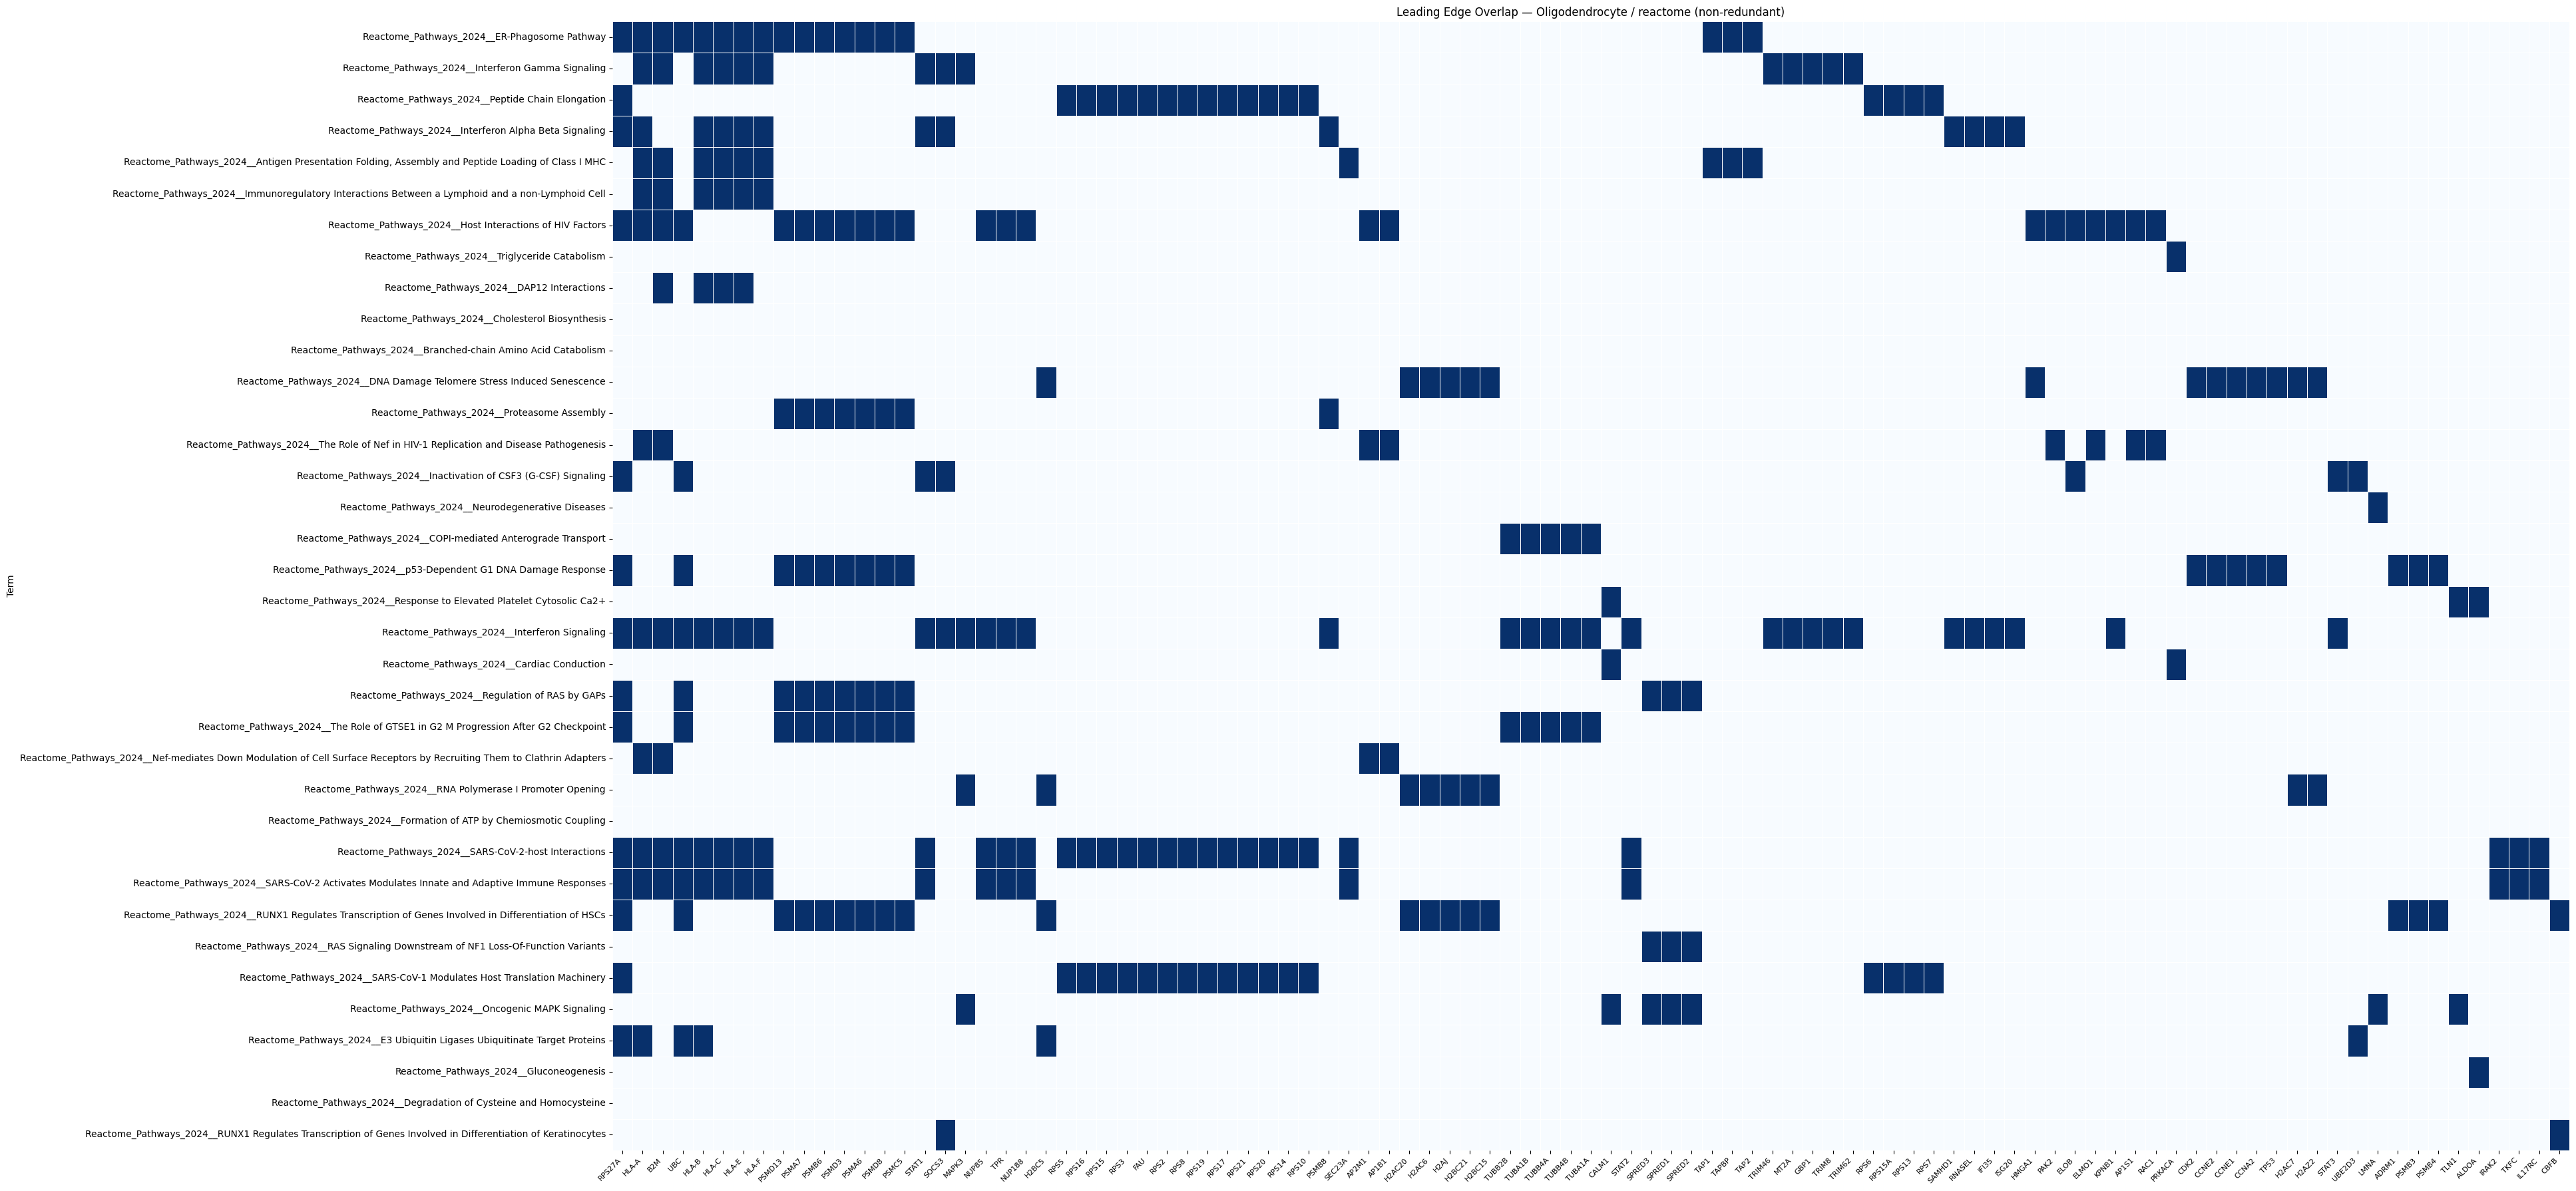


	######################
 	gobp 
	######################



,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Positive Regulation of T Cell Mediated Immunity (GO:0002711),2.287428,0.0
2,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.229704,0.000969
1,GO_Biological_Process_2025__Positive Regulation of Leukocyte Mediated Cytotoxicity (GO:0001912),2.255137,0.001454
8,GO_Biological_Process_2025__Positive Regulation of T Cell Mediated Cytotoxicity (GO:0001916),2.10758,0.001939
4,GO_Biological_Process_2025__Mitochondrial ATP Synthesis Coupled Electron Transport (GO:0042775),2.16337,0.002036
3,GO_Biological_Process_2025__Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776),2.194634,0.002181
7,GO_Biological_Process_2025__Cellular Respiration (GO:0045333),2.114573,0.002181
6,GO_Biological_Process_2025__Regulation of T Cell Mediated Cytotoxicity (GO:0001914),2.12678,0.002285
5,GO_Biological_Process_2025__Proton Motive Force-Driven ATP Synthesis (GO:0015986),2.141801,0.002423
11,GO_Biological_Process_2025__Aerobic Electron Transport Chain (GO:0019646),2.076247,0.00315


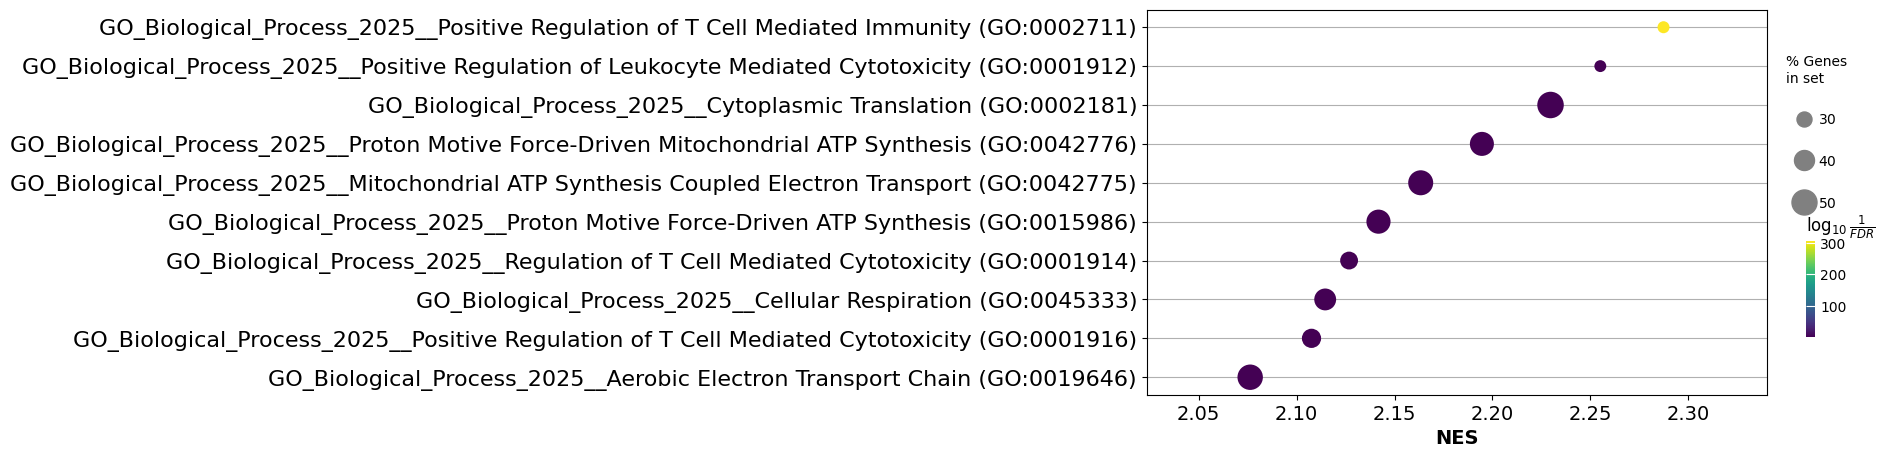

  Redundancy removal: 50 → 29 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,GO_Biological_Process_2025__Positive Regulation of T Cell Mediated Immunity (GO:0002711),2.287428,0.0,6/25,6,HLA-A;HLA-C;HLA-B;HLA-F;HLA-E;B2M
1,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.229704,0.000969,53/100,53,RPS5;RPL8;RPS16;RPL18A;RPL18;RPS15;RPL41;RPL29;RPL35;RPS3;RPL3;FAU;RPS2;RPL37A;RPS27A;RPL27A;RPS8;RPL36;RPS19;RPL12;RPS17;RPS21;EIF2S2;RPL15;RPL4;RPS20;RPL5;RPL14;RPL21;RPL7A;RPL13A;RPL28;RPS14;RPS10;RPLP0;RSL24D1;RPL35A;RPL27;RPL19;RPL22;EIF2B1;RPL9;RPS6;EIF4A1;RPL10A;RPS15A;EIF2B2;RPL11;RPS13;RPLP2;RPS7;RPL30;RPL34
2,GO_Biological_Process_2025__Mitochondrial ATP Synthesis Coupled Electron Transport (GO:0042775),2.16337,0.002036,31/62,31,COX5B;NDUFB4;NDUFAB1;NDUFS8;NDUFC2;COX8A;COX6A1;NDUFV2;COX6B1;NDUFB7;NDUFB1;NDUFB10;SDHB;UQCRC2;COX7B;NDUFB5;UQCRC1;NDUFS1;NDUFS2;COX4I1;UQCRB;SDHC;NDUFB2;NDUFA1;NDUFA6;NDUFB9;UQCR10;UQCR11;NDUFA8;UQCC3;NDUFB6
3,GO_Biological_Process_2025__Proton Motive Force-Driven Mitochondrial ATP Synthesis (GO:0042776),2.194634,0.002181,25/52,25,ATP5F1D;NDUFB4;NDUFAB1;NDUFS8;NDUFC2;NDUFB11;NDUFV2;ATP5F1C;NDUFA13;NDUFB7;ATP5ME;NDUFB1;NDUFB10;SDHB;NDUFB5;NDUFS1;NDUFS2;ATP5F1B;SDHC;NDUFB2;NDUFA1;NDUFA6;NDUFB9;ATP5PB;NDUFA8
4,GO_Biological_Process_2025__Regulation of Type II Interferon Production (GO:0032649),2.08758,0.003199,7/35,7,HLA-A;BTN3A2;CR1;PRNP;BTN3A1;VSIR;PDE4B
5,GO_Biological_Process_2025__Antigen Processing and Presentation of Exogenous Peptide Antigen (GO:0002478),2.01018,0.014093,3/13,3,HLA-A;HLA-F;HLA-E
6,GO_Biological_Process_2025__T Cell Mediated Immunity (GO:0002456),1.982507,0.017876,4/13,4,HLA-A;BTN3A2;BTN3A3;CR1
7,GO_Biological_Process_2025__Negative Regulation of Natural Killer Cell Mediated Cytotoxicity (GO:0045953),1.985379,0.018084,7/11,7,HLA-A;HLA-B;HLA-F;HLA-E;SERPINB9;CEACAM1;KLRD1
8,GO_Biological_Process_2025__Adaptive Imm Resp Based on Som Recomb of Imm Rcptrs Built Frm IgSF Domains (GO:0002460),1.985631,0.019193,7/16,7,BTN3A2;BTN3A3;CR1;PHB1;STAT3;CR1L;SCART1
9,GO_Biological_Process_2025__Antimicrobial Humoral Response (GO:0019730),1.971054,0.02005,7/28,7,HLA-A;HLA-E;B2M;FAM3A;TF;FAU;RPS19



Top leading edge genes (gobp):


,gene,n_pathways
0,HLA-A,7
1,HLA-E,4
2,B2M,4
3,CR1,4
4,HLA-F,3
5,BTN3A2,3
6,CASP3,3
7,HLA-B,2
8,FAU,2
9,RPS19,2


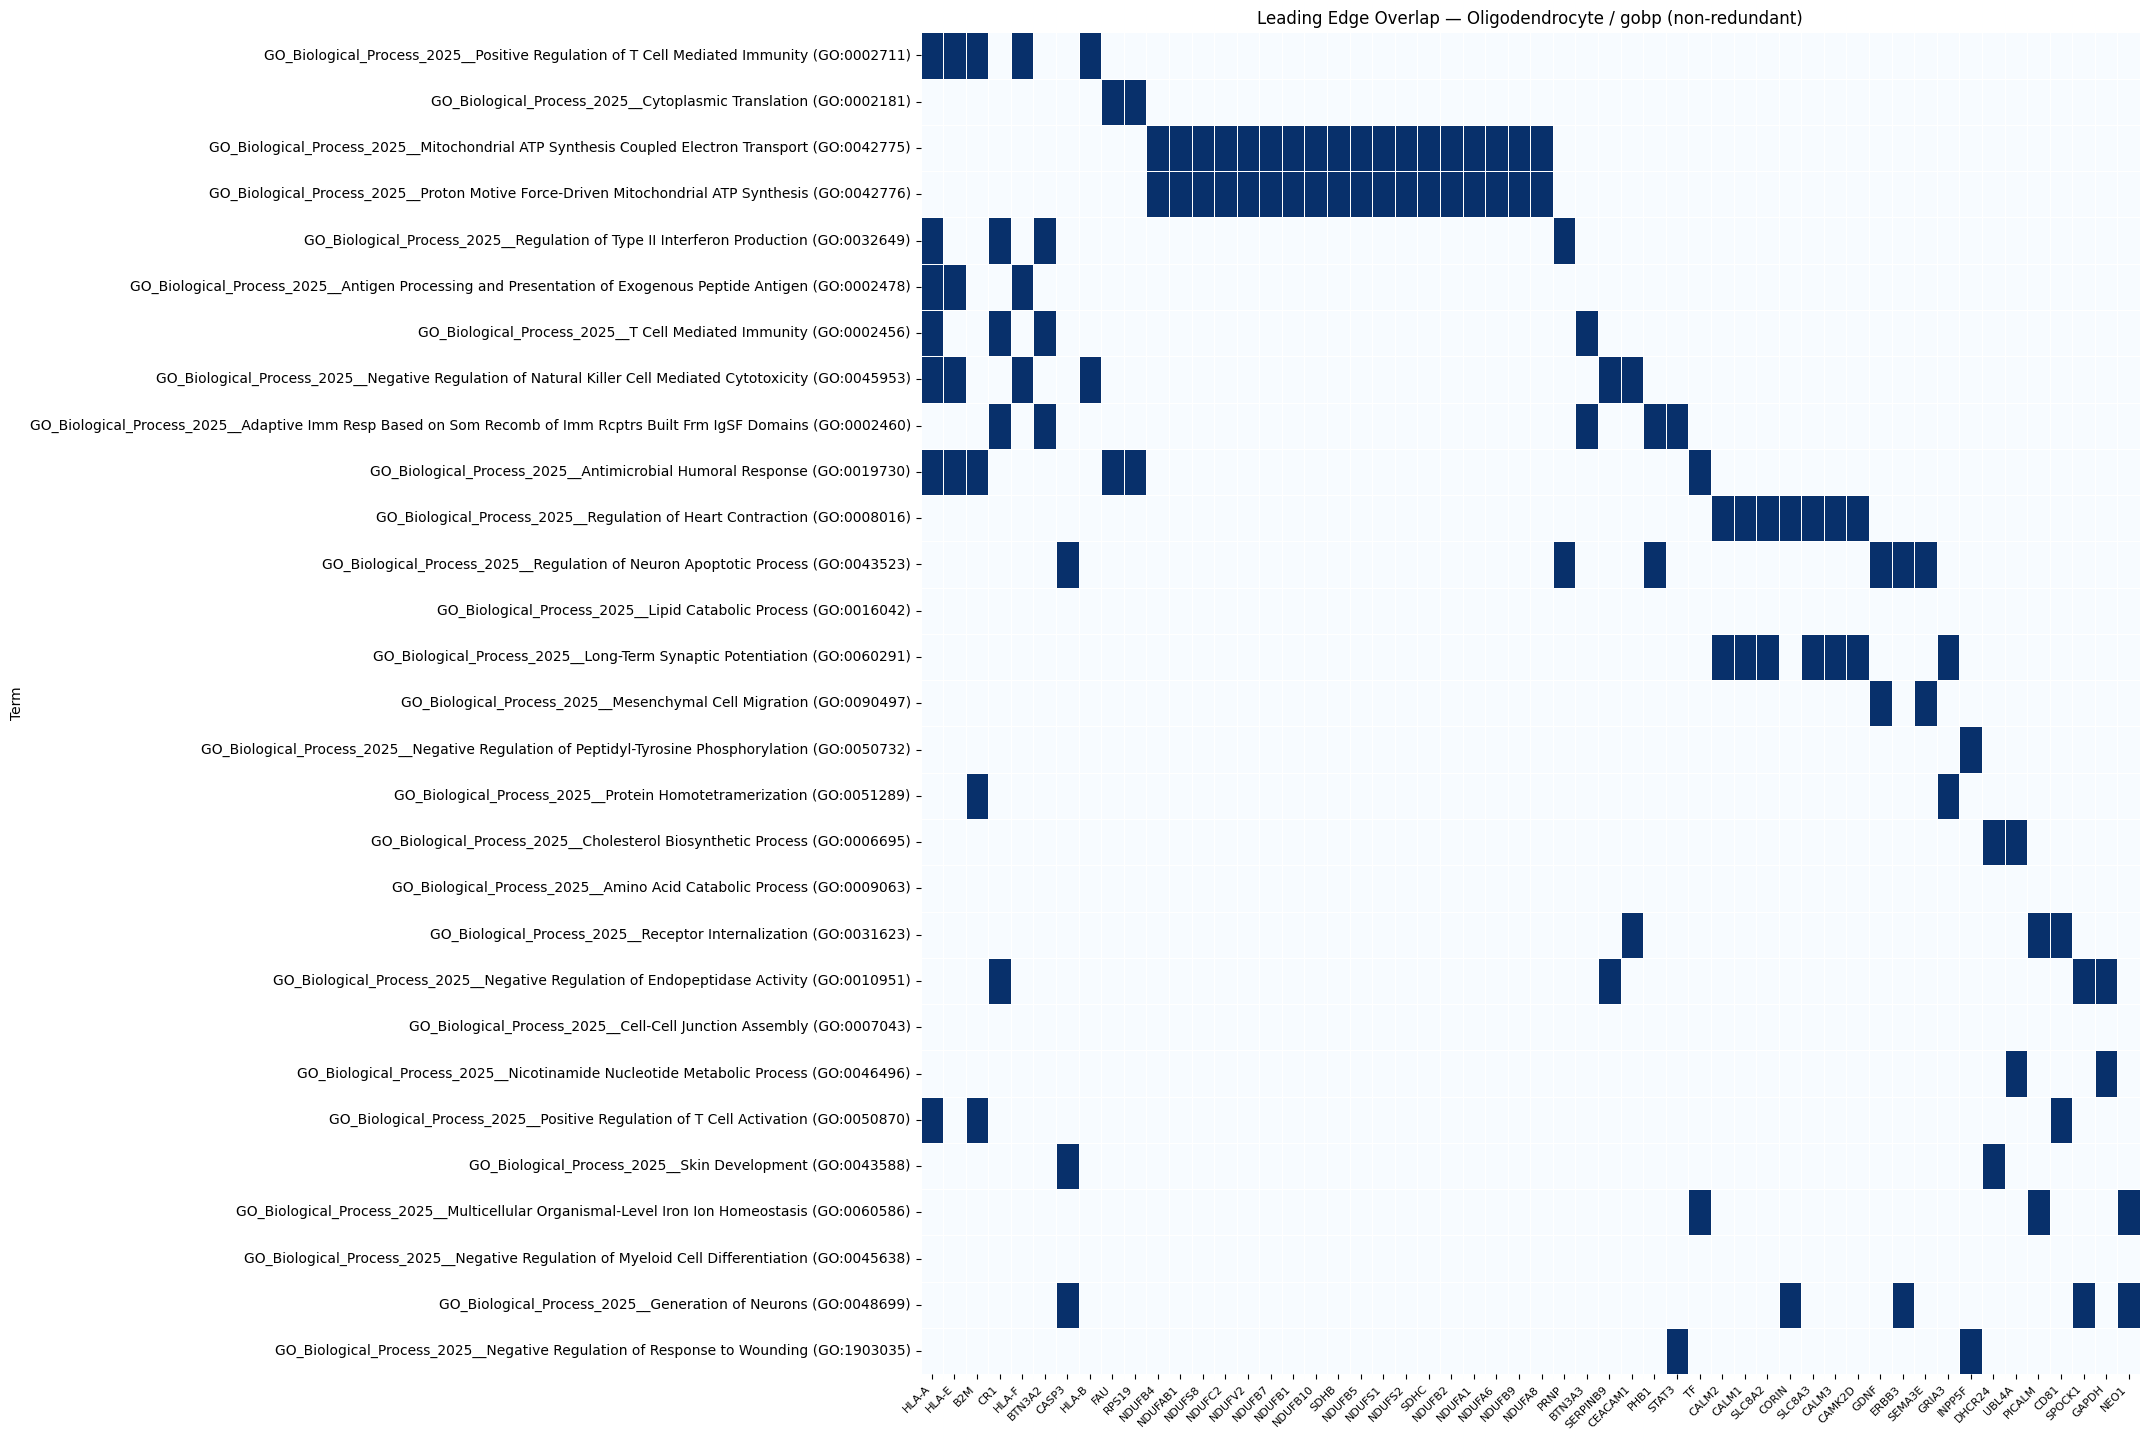


######################
 Patch 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.511683,0.0
1,SynGO_2024__Presynaptic Ribosome CC,2.431028,0.0
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.396174,0.0
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.382004,0.0
4,SynGO_2024__Extrinsic Component Of Presynaptic Endocytic Zone Membrane (GO:0098894) CC,-1.914354,0.012942
5,SynGO_2024__Regulation Of Synapse Assembly (GO:0051963) BP,-1.864552,0.017648
6,"SynGO_2024__Postsynaptic Specialization, Intracellular Component (GO:0099091) CC",1.755675,0.020441
7,MSigDB_Hallmark_2020__Allograft Rejection,1.73202,0.024558


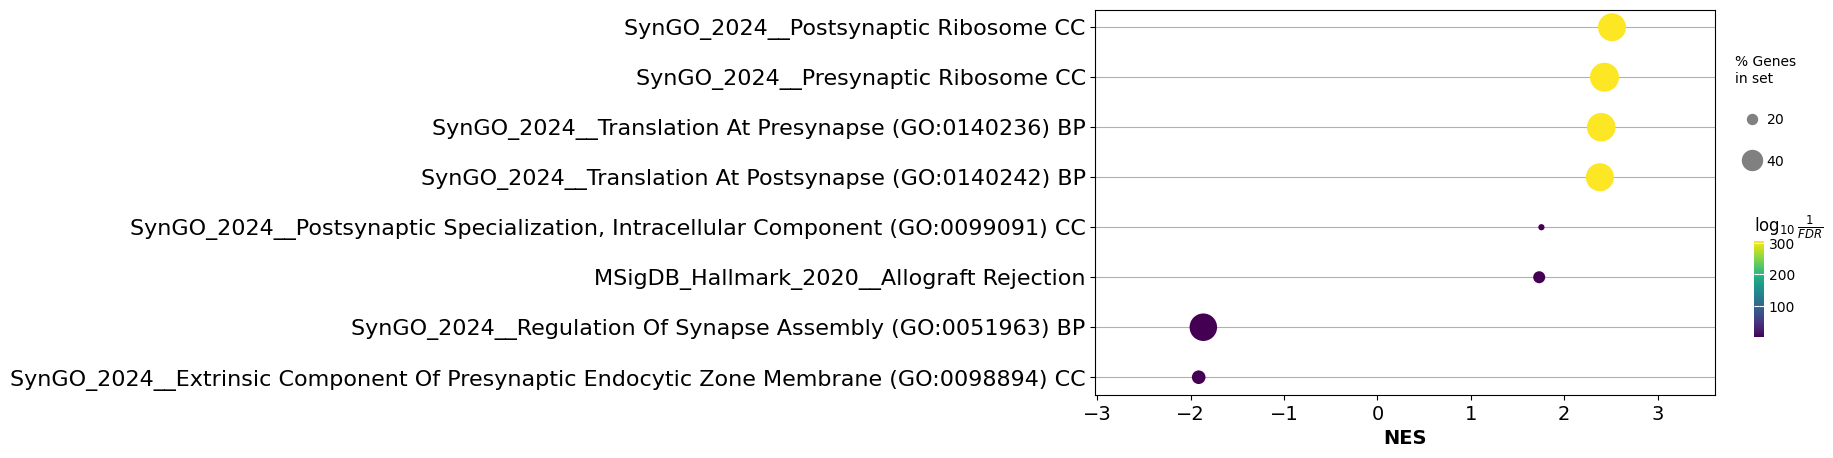

  Redundancy removal: 8 → 5 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,2.511683,0.0,38/68,38,RPS6;RPL4;RPL37;RPL35A;RPS7;RPL32;RPL31;RPS27;RPL9;RPS17;RPL5;RPLP1;RPL6;RPS13;RPL22;RPS20;RPS21;RPL23A;RPL29;RPL24;RPL26;RPL12;RPL21;RPS8;RPL17;RPL10A;RPS27A;RPS24;RPS3A;RPL38;RPL34;RPL23;RPLP2;RPS15A;RPS10;RPL15;RPL27;RPL7
1,SynGO_2024__Extrinsic Component Of Presynaptic Endocytic Zone Membrane (GO:0098894) CC,-1.914354,0.012942,3/11,3,AMPH;AP2S1;DNAJC6
2,SynGO_2024__Regulation Of Synapse Assembly (GO:0051963) BP,-1.864552,0.017648,11/20,11,SRGAP3;SDC2;LRRTM4;SRCIN1;EXOC7;SEMA4D;NLGN4X;CRTAC1;CTNNB1;PODXL;VLDLR
3,"SynGO_2024__Postsynaptic Specialization, Intracellular Component (GO:0099091) CC",1.755675,0.020441,1/8,1,GPHN
4,MSigDB_Hallmark_2020__Allograft Rejection,1.73202,0.024558,19/79,19,MAP3K7;RPL39;FLNA;STAT4;HLA-A;IFNGR2;HDAC9;IFNGR1;IFNAR2;RPL9;INHBA;THY1;RPS3A;NPM1;IL16;CD47;PSMB10;EIF3A;KLRD1



Top leading edge genes (curated):


,gene,n_pathways
0,RPL9,2
1,RPS3A,2


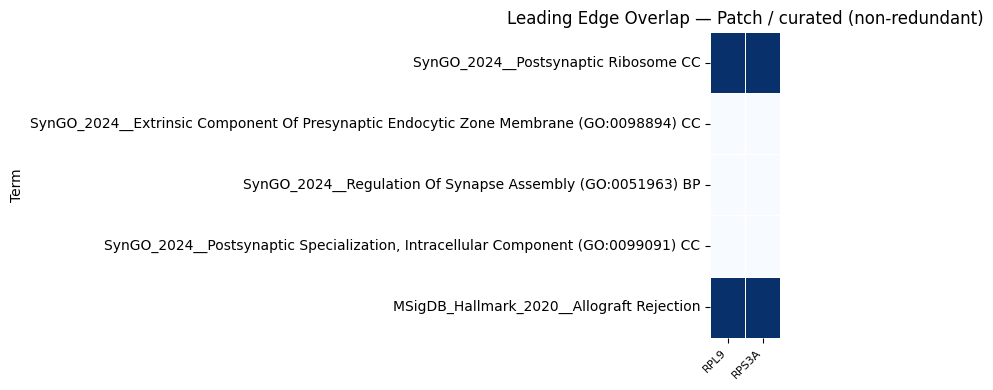


	######################
 	reactome 
	######################



,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Viral mRNA Translation,2.494523,0.0
18,Reactome_Pathways_2024__Nonsense Mediated Decay (NMD) Enhanced by the Exon Junction Complex (EJC),2.099835,0.0
17,Reactome_Pathways_2024__Nonsense-Mediated Decay (NMD),2.099835,0.0
16,Reactome_Pathways_2024__Cellular Response to Starvation,2.179325,0.0
15,Reactome_Pathways_2024__Influenza Infection,2.264336,0.0
14,Reactome_Pathways_2024__Influenza Viral RNA Transcription and Replication,2.277736,0.0
13,Reactome_Pathways_2024__Cap-dependent Translation Initiation,2.296806,0.0
11,Reactome_Pathways_2024__SRP-dependent Cotranslational Protein Targeting to Membrane,2.341664,0.0
10,Reactome_Pathways_2024__L13a-mediated Translational Silencing of Ceruloplasmin Expression,2.360973,0.0
12,Reactome_Pathways_2024__Eukaryotic Translation Initiation,2.296806,0.0


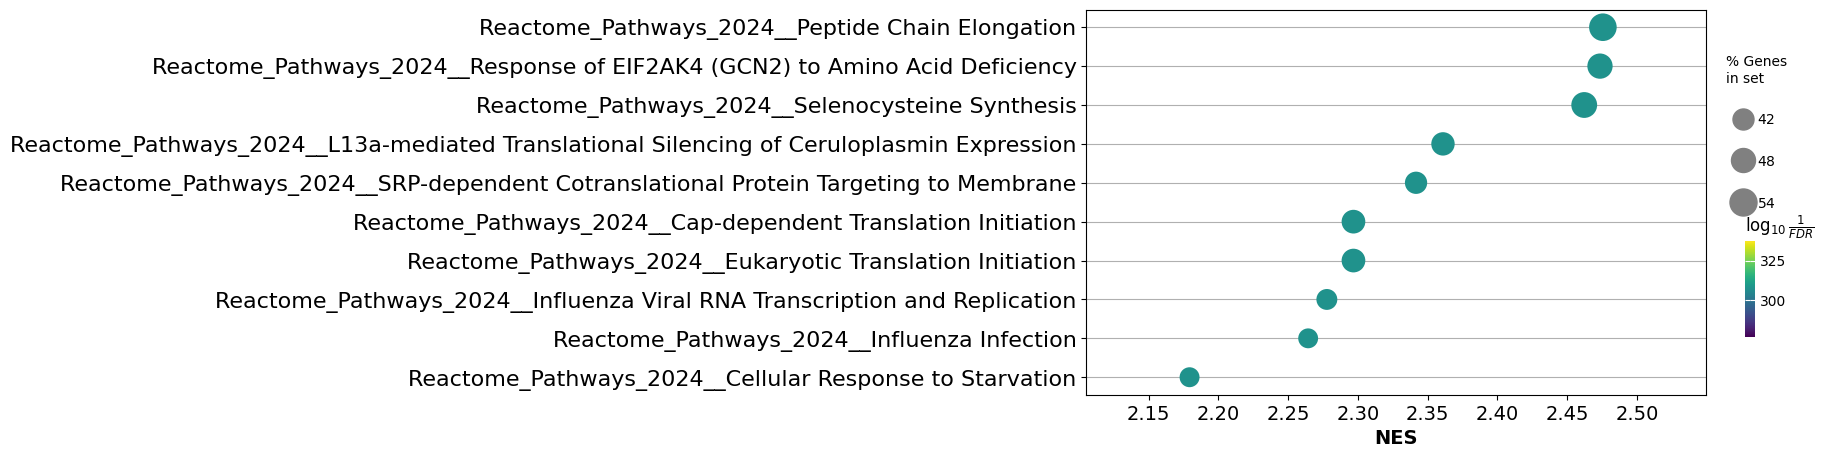

  Redundancy removal: 32 → 3 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Viral mRNA Translation,2.494523,0.0,48/87,48,RPS6;RPL4;RPL37;RPL39;GRSF1;RPL35A;RPS7;RPL32;RPL31;RPL19;RPS27;RPL9;RPS17;RPL5;RPS25;RPLP1;RPL6;RPL22L1;RPS13;RPL22;RPS20;RPS21;RPL23A;RPL29;RPL24;RPL26;RPL12;RPL21;RPS4X;RPS8;RPL17;RPL10A;RPS27A;RPS24;RPS3A;RPL38;RPL34;RPL23;RPLP2;RPS15A;RPL41;RPS10;RPL3;RPL15;RPL27;RPL7;FAU;RPS12
1,Reactome_Pathways_2024__SARS-CoV-1 Modulates Host Translation Machinery,2.043217,0.000213,21/36,21,RPS6;RPS7;RPS27;RPS17;RPS25;EEF1A1;RPS13;RPS20;RPS21;RPS4X;RPS8;RPS27A;RPS24;RPS3A;RPS15A;RPS10;FAU;RPS12;RPS16;RPS3;HNRNPA1
2,Reactome_Pathways_2024__Signalling to ERKs,1.784553,0.036291,12/30,12,MAPK1;FRS2;YWHAB;MAP2K2;GRB2;SHC3;MAPK14;CRK;RALB;MAPK12;MAPK3;KIDINS220



Top leading edge genes (reactome):


,gene,n_pathways
0,RPS6,2
1,RPS7,2
2,RPS27,2
3,RPS17,2
4,RPS25,2
5,RPS13,2
6,RPS20,2
7,RPS21,2
8,RPS4X,2
9,RPS8,2


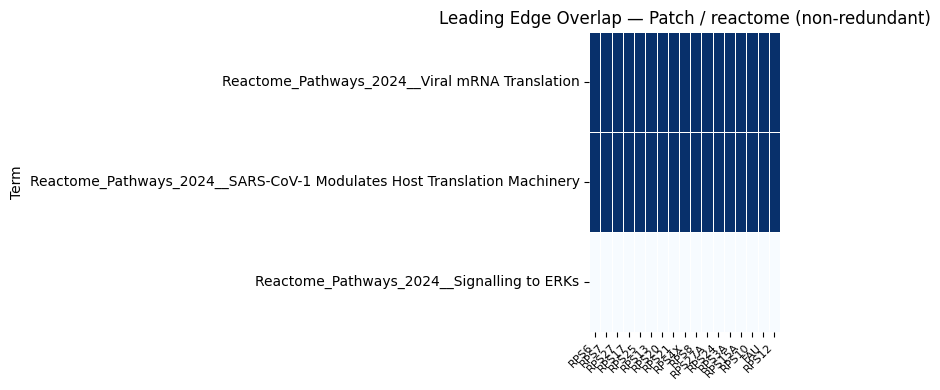


	######################
 	gobp 
	######################



,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.44971,0.0


  GSEA failed for Patch: Can not detetermine colormap. All values in FDR q-val are 0s

######################
 Pericytes 
######################

ERROR: Missing results file for Pericytes at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Pericytes/deg_results.csv

######################
 SmoothMuscleCells 
######################

ERROR: Missing results file for SmoothMuscleCells at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/SmoothMuscleCells/deg_results.csv

######################
 eMSN_D1D2 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.196454,0.0
1,SynGO_2024__Presynaptic Ribosome CC,2.118363,0.0
2,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.110181,0.0
3,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.105829,0.0


  GSEA failed for eMSN_D1D2: Can not detetermine colormap. All values in FDR q-val are 0s

######################
 eMSN_NUDAP 
######################

ERROR: Missing results file for eMSN_NUDAP at /home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/eMSN_NUDAP/deg_results.csv

######################
 eMSN_StrioMat 
######################


	######################
 	curated 
	######################



,Term,NES,FDR q-val
0,SynGO_2024__Postsynaptic Ribosome CC,2.296444,0.0
1,SynGO_2024__Presynaptic Ribosome CC,2.122751,0.0
2,SynGO_2024__Translation At Presynapse (GO:0140236) BP,2.10786,0.0
3,SynGO_2024__Translation At Postsynapse (GO:0140242) BP,2.090209,0.0
5,SynGO_2024__Synapse (GO:0045202) CC,1.829116,0.003911
6,SynGO_2024__Integral Component Of Postsynaptic Specialization Membrane (GO:0099060) CC,1.709511,0.028249


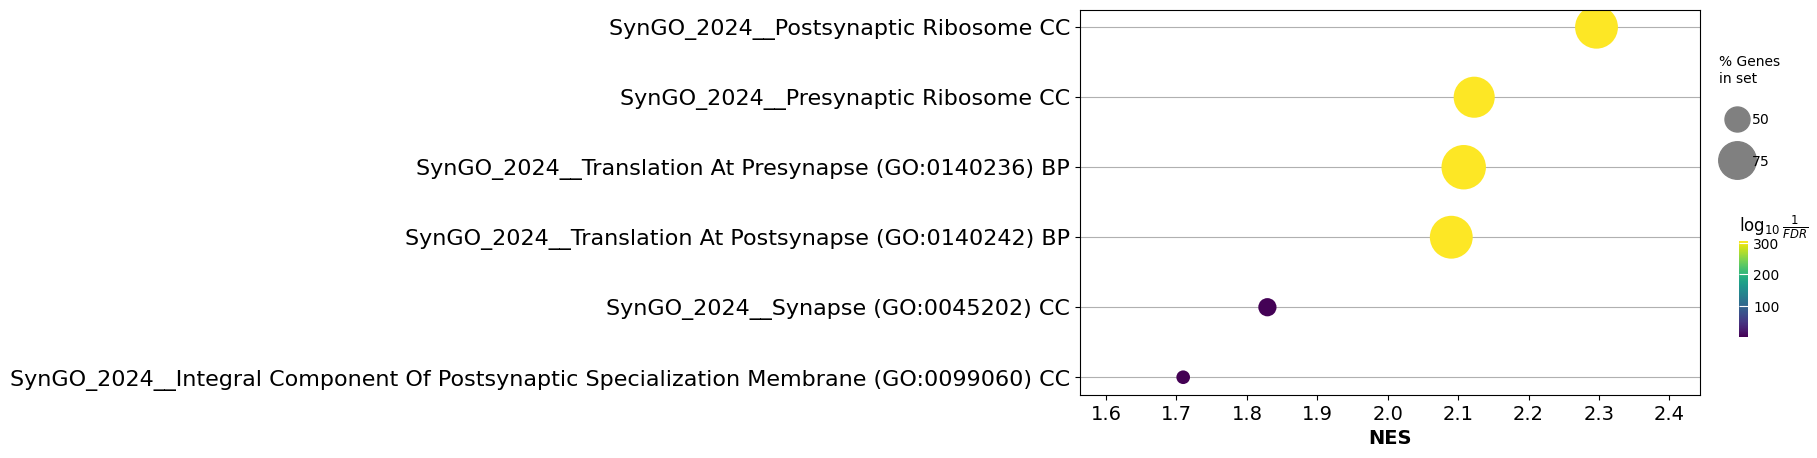

  Redundancy removal: 6 → 3 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,SynGO_2024__Postsynaptic Ribosome CC,2.296444,0.0,36/42,36,RPS3A;RPL32;RPL31;RPL10A;RPLP2;RPL14;RPS24;RPL17;RPS27A;RPL24;RPS6;RPL6;RPL5;RPL22;RPS27;RPL18;RPLP1;RPL11;RPS7;RPL30;RPS19;RPS8;RPS23;RPS28;RPL15;RPL9;RPS15;RPL10;RPS20;RPL4;RPL34;RPL37A;RPL13A;RPS3;RPL26;RPL13
1,SynGO_2024__Synapse (GO:0045202) CC,1.829116,0.003911,66/181,66,FKBP1A;RPS3A;RPL32;RPL31;RPL10A;RPS25;SLITRK5;RPLP2;ACTN1;RPL14;RPS24;RPL17;RPL19;ROCK1;RPS27A;RPL24;HNRNPF;FLOT1;RPL6;RPL5;RPL22;SH3GL2;RPS27;RPL18;PPM1H;FAM171B;RPLP1;RPL11;RPS7;RPL30;WIPF3;RPS19;VGF;RPS23;RPS28;RPL15;PPP2R1A;RPL9;RPS15;HABP4;RPL10;VLDLR;RPS20;RPL3;ARPC1A;AP1G2;CPNE7;TPD52;RPL34;TAGLN3;DAAM1;RPL37A;PCDH8;RPL13A;CAPRIN1;BRINP1;RPS6KB1;CDH9;RPS3;ARPC5L;RPL26;RPL13;TDRD6;CNTN1;RIMS4;AP2B1
2,SynGO_2024__Integral Component Of Postsynaptic Specialization Membrane (GO:0099060) CC,1.709511,0.028249,6/22,6,NLGN1;NLGN2;NLGN4X;EPHA7;GABRB1;GABRA4



Top leading edge genes (curated):


,gene,n_pathways
0,RPS3A,2
1,RPL32,2
2,RPL31,2
3,RPL10A,2
4,RPLP2,2
5,RPL14,2
6,RPS24,2
7,RPL17,2
8,RPS27A,2
9,RPL24,2


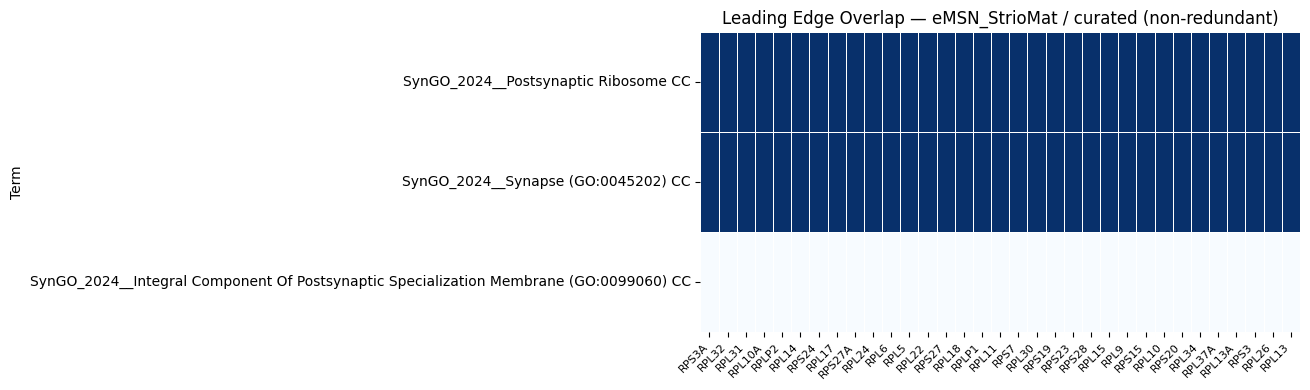


	######################
 	reactome 
	######################



,Term,NES,FDR q-val
0,Reactome_Pathways_2024__Peptide Chain Elongation,2.33741,0.0
28,Reactome_Pathways_2024__Metabolism of Amino Acids and Derivatives,1.981663,0.0
27,Reactome_Pathways_2024__Mitochondrial RNA Degradation,1.992509,0.0
26,Reactome_Pathways_2024__SARS-CoV-1-host Interactions,2.00421,0.0
25,Reactome_Pathways_2024__SARS-CoV-2 Modulates Host Translation Machinery,2.012819,0.0
24,Reactome_Pathways_2024__SARS-CoV-1 Modulates Host Translation Machinery,2.014397,0.0
23,Reactome_Pathways_2024__tRNA Processing in the Mitochondrion,2.063403,0.0
22,Reactome_Pathways_2024__Regulation of Expression of SLITs and ROBOs,2.102443,0.0
21,Reactome_Pathways_2024__rRNA Processing in the Nucleus and Cytosol,2.154722,0.0
20,Reactome_Pathways_2024__Cellular Response to Starvation,2.158976,0.0


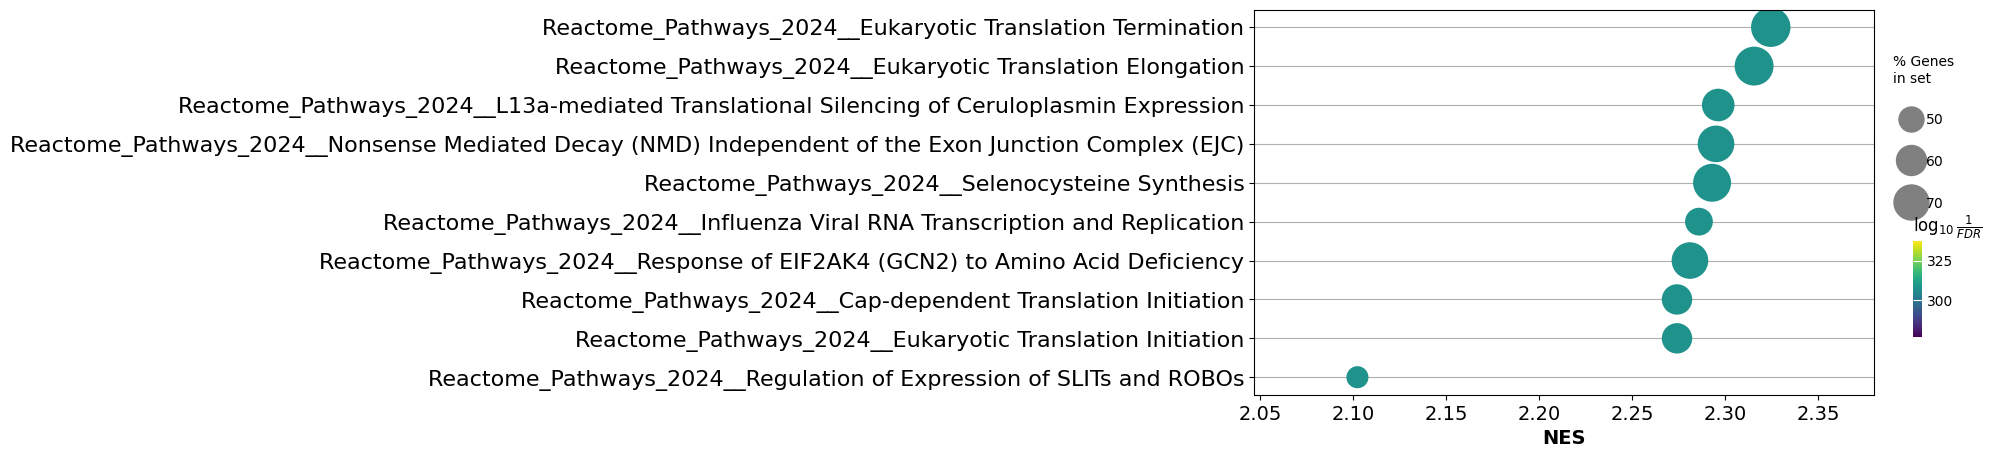

  Redundancy removal: 41 → 6 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,Reactome_Pathways_2024__Peptide Chain Elongation,2.33741,0.0,42/52,42,RPS3A;RPL32;RPL31;RPL10A;RPS25;RPLP2;RPL14;RPS24;EEF1A1;RPL17;RPL19;RPS27A;RPL24;RPS6;RPL6;RPL5;RPL22;RPS27;RPL18;RPLP1;RPL11;RPS7;RPL30;RPS19;RPS8;RPS23;RPS28;RPL15;RPS12;RPL9;RPS15;RPL10;RPS20;RPL3;RPL4;RPL34;RPL37A;RPL13A;RPS3;RPL26;RPL13;RPS4Y1
1,Reactome_Pathways_2024__SARS-CoV-1-host Interactions,2.00421,0.0,19/50,19,FKBP1A;RPS3A;RPS25;RPS24;EEF1A1;RPS27A;PPIA;RPS6;RPS27;RPS7;RPS19;RPS8;YWHAB;RPS23;RPS28;RPS12;RPS15;PCBP2;RPS20
2,Reactome_Pathways_2024__tRNA Processing in the Mitochondrion,2.063403,0.0,10/13,10,MT-ATP6;MT-CO2;MT-CO3;MT-ND1;MT-ND4L;MT-CYB;MT-CO1;MT-ND5;MT-ND4;MT-ND2
3,Reactome_Pathways_2024__tRNA Processing,1.867062,0.002138,21/69,21,NUP98;MT-ATP6;POP1;MT-CO2;MT-CO3;MT-ND1;MT-ND4L;NUP155;MT-CYB;MT-CO1;NSUN2;MT-ND5;TRMU;MT-ND4;NUP93;MT-ND2;ALKBH8;TRMT9B;NUP160;OSGEP;NUP153
4,Reactome_Pathways_2024__Signaling by FGFR3 in Disease,1.769547,0.016546,4/8,4,FGF9;FRS2;GRB2;SOS1
5,Reactome_Pathways_2024__Signaling by FGFR1 in Disease,1.713464,0.046812,11/23,11,BAG4;FGF9;FRS2;FGFR1OP2;GRB2;SOS1;CNTRL;CPSF6;FGFR1;STAT5B;STAT3



Top leading edge genes (reactome):


,gene,n_pathways
0,RPS3A,2
1,RPS25,2
2,RPS24,2
3,EEF1A1,2
4,RPS27A,2
5,RPS6,2
6,RPS27,2
7,RPS7,2
8,RPS19,2
9,RPS8,2


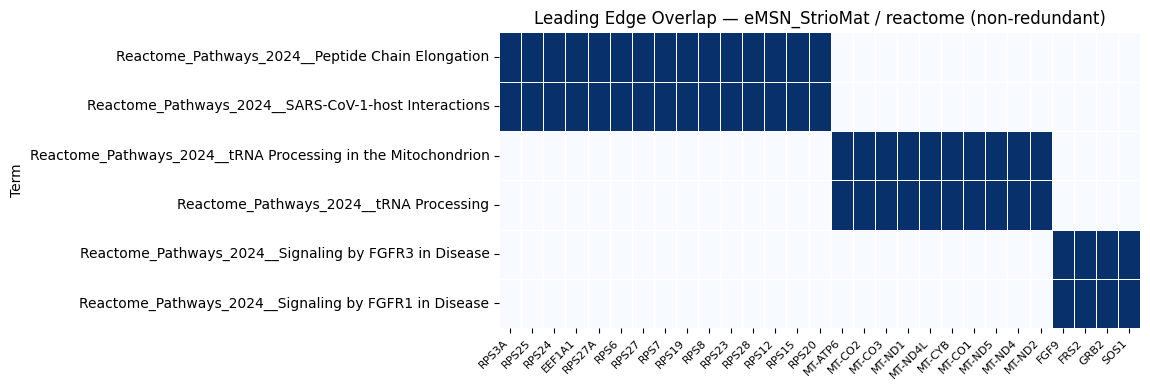


	######################
 	gobp 
	######################



,Term,NES,FDR q-val
0,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.270425,0.0
3,GO_Biological_Process_2025__Ribosomal Small Subunit Biogenesis (GO:0042274),2.050771,0.000332
1,GO_Biological_Process_2025__Ribonucleoprotein Complex Biogenesis (GO:0022613),2.067146,0.000499
4,GO_Biological_Process_2025__Macromolecule Biosynthetic Process (GO:0009059),2.016941,0.000748
5,GO_Biological_Process_2025__Ribosome Biogenesis (GO:0042254),2.001091,0.000997
7,GO_Biological_Process_2025__Translation (GO:0006412),1.919336,0.006981
8,GO_Biological_Process_2025__Homotypic Cell-Cell Adhesion (GO:0034109),1.872834,0.01952
10,GO_Biological_Process_2025__rRNA Processing (GO:0006364),1.857595,0.022565
13,GO_Biological_Process_2025__Platelet Aggregation (GO:0070527),1.839204,0.031472


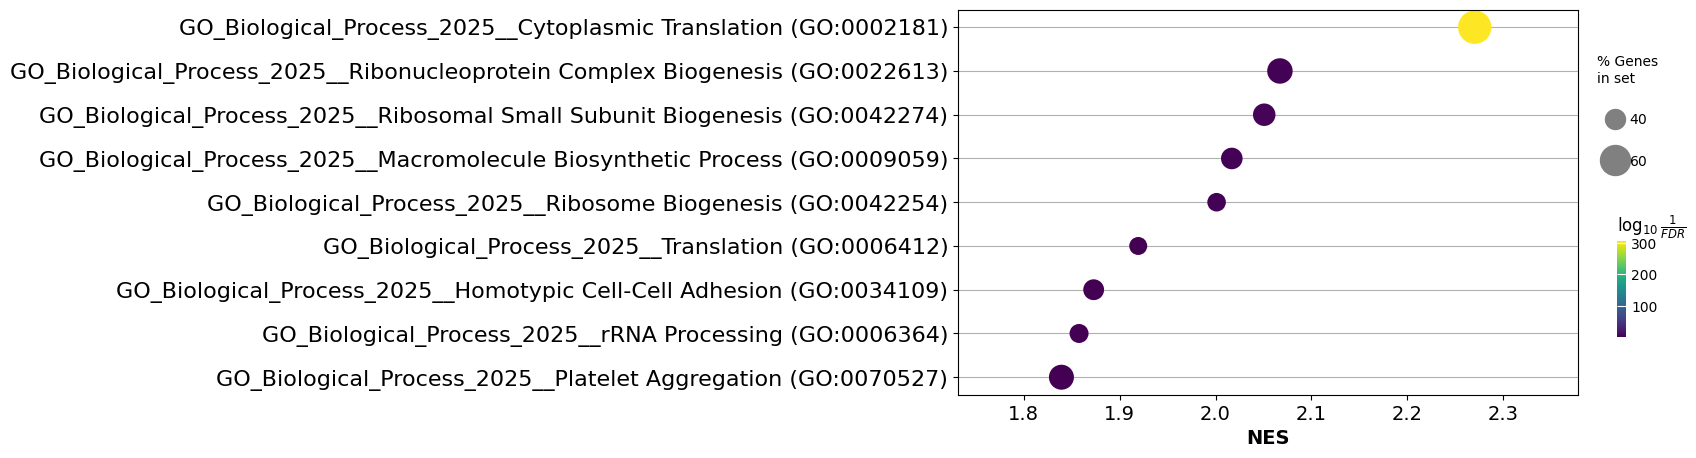

  Redundancy removal: 9 → 4 pathways (Jaccard > 0.5)


,Term,NES,FDR q-val,Tag %,n_lead,Lead_genes
0,GO_Biological_Process_2025__Cytoplasmic Translation (GO:0002181),2.270425,0.0,40/60,40,RPS3A;RPL32;RPL31;RPL10A;RPS25;RPLP2;RPL14;RPS24;RPL19;RPS27A;RPS6;RPL6;RPL5;RPL22;RPS27;RPL18;RPLP1;RPL11;RPS7;RPL30;RPS19;RPS8;RPS23;RPS28;RPL15;ZC3H15;RPS12;RPL9;RPS15;EIF4A1;RPS20;RPL3;RPL4;RACK1;RPL34;RPL37A;RPL13A;RPS3;EIF4A2;RPL26
1,GO_Biological_Process_2025__Ribosomal Small Subunit Biogenesis (GO:0042274),2.050771,0.000332,18/40,18,RPS3A;RCL1;RPS25;RPS24;RPS27A;RPS6;RRP7A;RPS27;RPS7;NOM1;RPS19;RPS8;RPS23;RPS28;RPS12;RPS15;RIOK3;WDR75
2,GO_Biological_Process_2025__Homotypic Cell-Cell Adhesion (GO:0034109),1.872834,0.01952,5/12,5,FLNA;VCL;MYH9;ACTN1;PPIA
3,GO_Biological_Process_2025__rRNA Processing (GO:0006364),1.857595,0.022565,19/50,19,RCL1;RPS25;RPL14;RPS24;MPHOSPH6;RPS6;RPL5;RRP7A;RPS27;RPL11;RPS7;RPS19;NOL8;RPS28;XRN2;RPS15;RIOK3;RRP15;MTREX



Top leading edge genes (gobp):


,gene,n_pathways
0,RPS25,3
1,RPS24,3
2,RPS6,3
3,RPS27,3
4,RPS7,3
5,RPS19,3
6,RPS28,3
7,RPS15,3
8,RPS3A,2
9,RPL14,2


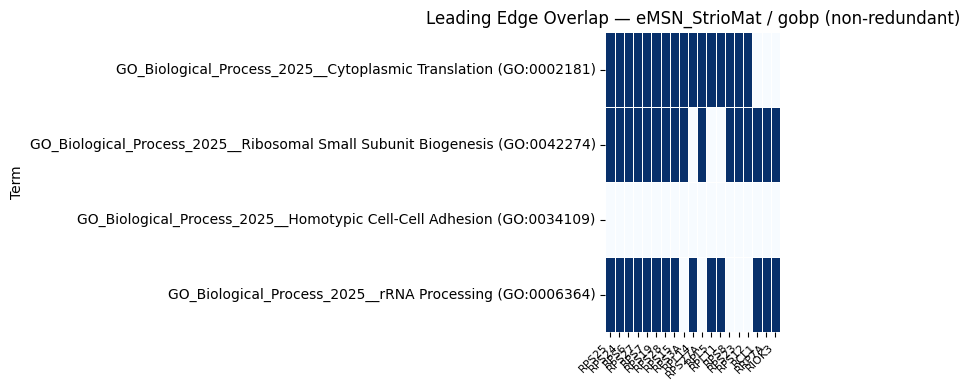

In [ ]:
THR_FDR_GSEA=0.05

for ct in sorted(os.listdir(RESULTS_FOLDER)):

    #ct="Matrix"
    if "-" in ct:
        continue
    print("\n######################\n",ct, "\n######################\n")

    subfolder = f"{ZONE_CT}_by_zone/{ct}" if RUN_ON_ZONES else ct # dedin if we are using zones

    # fodle of results
    SAVE_HEALTHY_PCA_RESULT = os.path.join(RESULTS_FOLDER, subfolder)    
    save_csv_path = f"{SAVE_HEALTHY_PCA_RESULT}/deg_results.csv" # outpue nebuka

    # Saved files
    img_dir = os.path.join(SAVE_HEALTHY_PCA_RESULT, "images")

    if not os.path.exists(save_csv_path):
        print(f"ERROR: Missing results file for {ct} at {save_csv_path}")
        continue

    # Read results nebula
    df_nebula = pd.read_csv(save_csv_path)
    df_nebula = df_nebula.dropna(subset=[PVAL_COL, LOGFC_COL])

    #########
    ### GSEA
    ##########

    df_rank = df_nebula.copy()

    # Rank metric: sign(logFC) * -log10(p_raw)  — keeps direction & magnitude
    # RAW p-values (not adjusted)-->GSEA does its own permutation-based multiple testing
    df_rank["rank_metric"] = (
        np.sign(df_rank[LOGFC_COL]) *
        -np.log10(df_rank[PVAL_COL].clip(lower=1e-300))
    )
    # df_rank["rank_metric"] = df_rank[LOGFC_COL] / df_rank[SE_COL]


    # Drop duplicates (keep highest |rank|) 
    # sort descending
    df_rank = (
        df_rank
        .sort_values("rank_metric", ascending=False)
        .drop_duplicates(subset=[GENE_COL]) # rmeove dupicated genes
    )
    # Gsea need a df with only index a single col
    ranked_series = df_rank.set_index(GENE_COL)["rank_metric"] 

    try:

        #This way each database is corrected only against itself, and a real signal in Hallmark isn't penalized by the 7,000 GO terms
        #The tradeoff is that you can't directly compare FDR values across databases 
        for db_name, gene_sets in [
            ("curated",  ["MSigDB_Hallmark_2020", "SynGO_2024"]),
            ("reactome", ["Reactome_Pathways_2024"]),
            ("gobp",     ["GO_Biological_Process_2025"]),
        ]:
            print("\n\t######################\n", f"\t{db_name}", "\n\t######################\n")
            # ES --> enriuchemnt score
            # NES -->romalised ES --> by gene set size
            # ignificance is assessed by randomly permuting the gene order --> creating nulld sitruvtion
            pre_res = gp.prerank(
                rnk=ranked_series,
                gene_sets=gene_sets, 
                    # ["MSigDB_Hallmark_2020", "SynGO_2024", #GO_Biological_Process_2025, KEGG_2026, GO_Cellular_Component_2025
                    # "Reactome_Pathways_2024", "GO_Biological_Process_2025"],
                seed=42,
                # always uses gene set permutation
                permutation_num=1000,
                    # A reported p-value of 0.0 means the actual p-value is less than 1/number-of-permutations --> ncrease the permutation count for a more accurate estimate
                min_size=4, #if fewer than 10 genes in the set are present in your data, skip it.
                max_size=250, #if more than 500 genes in the set overlap your data, skip it
                verbose=False,
                threads=30#24
            )

            # df gsea
            df_gsea = pre_res.res2d.copy()
            df_gsea = df_gsea.sort_values("FDR q-val")
            df_gsea_sig = df_gsea[df_gsea["FDR q-val"] <= THR_FDR_GSEA]
            with pd.option_context('display.max_colwidth', None):
                display(df_gsea_sig[["Term", "NES", "FDR q-val"]])

            if len(df_gsea_sig) == 0:
                print(f"  No significant GSEA terms for {ct}, skipping plots")
            else:

                # Dotplot: size = gene ratio, color = FDR
                dotplot(
                    pre_res.res2d,
                    column="FDR q-val",      # color axis
                    #title="Hallmark pathways",
                    cmap=plt.cm.viridis,
                    size=6,
                    figsize=(10, 5),
                    cutoff=THR_FDR_GSEA,  # only show terms below this FDR
                    show_ring=False,
                    ofname=None, # image saving apth
                )
                plt.show()

            # ── Leading Edge Analysis ───────────────────────────────────────────────────
            df_gsea_sig = df_gsea_sig.copy()

            # Parse semicolon-separated lead genes into lists
            df_gsea_sig["lead_gene_list"] = (
                df_gsea_sig["Lead_genes"]
                .str.split(";")
                .apply(lambda x: [g.strip() for g in x] if isinstance(x, list) else [])
            )
            df_gsea_sig["n_lead"] = df_gsea_sig["lead_gene_list"].apply(len)

            # ── Jaccard-based redundancy removal ───────────────────────────────────────
            JACCARD_THR = 0.5  # remove pathway if >50% leading edge overlap with a better-ranked pathway

            def jaccard(set1, set2):
                intersection = len(set1 & set2)
                union = len(set1 | set2)
                return intersection / union if union > 0 else 0

            df_sorted = df_gsea_sig.sort_values("FDR q-val").reset_index(drop=True)
            df_sorted["lead_set"] = df_sorted["lead_gene_list"].apply(set)

            kept_indices = []
            for i, row_i in df_sorted.iterrows():
                dominated = False
                for j in kept_indices:
                    row_j = df_sorted.loc[j]
                    if np.sign(row_i["NES"]) != np.sign(row_j["NES"]):  # only compare same direction
                        continue
                    if jaccard(row_i["lead_set"], row_j["lead_set"]) > JACCARD_THR:
                        dominated = True
                        break
                if not dominated:
                    kept_indices.append(i)

            df_gsea_nr = df_sorted.loc[kept_indices].drop(columns="lead_set").reset_index(drop=True)
            print(f"  Redundancy removal: {len(df_sorted)} → {len(df_gsea_nr)} pathways (Jaccard > {JACCARD_THR})")

            # Display non-redundant enriched terms
            with pd.option_context('display.max_colwidth', None):
                display(df_gsea_nr[["Term", "NES", "FDR q-val", "Tag %", "n_lead", "Lead_genes"]])

            # Genes appearing across MULTIPLE non-redundant pathways → highest confidence hits
            from collections import Counter
            gene_freq = Counter(g for genes in df_gsea_nr["lead_gene_list"] for g in genes)
            df_gene_freq = pd.DataFrame(gene_freq.most_common(), columns=["gene", "n_pathways"])
            print(f"\nTop leading edge genes ({db_name}):")
            display(df_gene_freq[df_gene_freq["n_pathways"] > 1])

            # Binary heatmap: non-redundant pathways × genes (only genes in ≥2 pathways)
            recurring_genes = df_gene_freq[df_gene_freq["n_pathways"] > 1]["gene"].tolist()
            if len(recurring_genes) > 0:
                matrix = pd.DataFrame(0, index=df_gsea_nr["Term"], columns=recurring_genes)
                for _, row in df_gsea_nr.iterrows():
                    for gene in row["lead_gene_list"]:
                        if gene in recurring_genes:
                            matrix.loc[row["Term"], gene] = 1

                plt.figure(figsize=(max(8, len(recurring_genes) * 0.4), max(4, len(matrix) * 0.5)))
                sns.heatmap(matrix, cmap="Blues", linewidths=0.5, cbar=False, yticklabels=True, xticklabels=True)
                plt.title(f"Leading Edge Overlap — {ct} / {db_name} (non-redundant)")
                plt.xticks(rotation=45, ha="right", fontsize=8)
                plt.tight_layout()
                plt.show()

    except Exception as e:
        print(f"  GSEA failed for {ct}: {e}")

    #break

In [16]:
adamts_genes = [
    "ADAMTS2", "ADAMTS3", "ADAMTS10", "ADAMTS13",
    "ADAMTSL1", "ADAMTSL2", "ADAMTSL3",
    "THBS1", "THBS2", "THSD1", "THSD4", "THSD7A", "THSD7B"
]

df_adamts = df_nebula[df_nebula[GENE_COL].isin(adamts_genes)].copy()
df_adamts = df_adamts.sort_values(LOGFC_COL)

display(df_adamts[[GENE_COL, LOGFC_COL, PVAL_COL]].round(3))

,gene,logFC_conditionXDP,p_conditionXDP
7767,THBS2,-0.667,0.001
2951,THSD7B,-0.654,0.001
14841,THBS1,-0.524,0.000
18216,ADAMTS10,-0.398,0.004
15168,THSD4,-0.381,0.090
10399,ADAMTSL2,-0.256,0.000
9740,ADAMTSL1,-0.233,0.040
5118,ADAMTS3,-0.192,0.003
7892,THSD7A,-0.192,0.004
15327,ADAMTSL3,-0.172,0.054


In [18]:
ogt_genes = ["OGT", "POFUT2", "B3GLCT", "OGA"]  # OGA = O-GlcNAcase

df_ogt = df_nebula[df_nebula[GENE_COL].isin(ogt_genes)]
display(df_ogt[[GENE_COL, LOGFC_COL, PVAL_COL]].round(3))

,gene,logFC_conditionXDP,p_conditionXDP
11110,OGA,0.086,0.011
13637,B3GLCT,-0.039,0.313
20022,POFUT2,-0.042,0.432
20870,OGT,0.099,0.135


TAF1 reduced (XDP SVA insertion)
        ↓
Transcription of ADAMTS/THBS genes reduced
        ↓
Less ADAMTS protein produced
        ↓
ECM remodeling suppressed

In [ ]:
/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/DEG/Striatum/PCA_nebula/Astrocyte

In [ ]:
# # Helper to draw a DEG panel onto a given ax
# def draw_deg(ax, categories, print_labels=True):
#     DEG.plot_vulcano(df_nebula, logfc_col=LOGFC_COL, pval_col=col_p_adj, gene_col=GENE_COL,
#                         pval_thresh=PVAL_THR, logfc_thresh=LOGFC_THR, to_label=0,
#                         categories=categories, max_y=None, ax=ax, print_labels=print_labels)

# def draw_dc(ax, thr_stat):
#     dc.pl.volcano(df_dc, x="logFC", y="padj", top=40,
#                     thr_stat=thr_stat, thr_sign=PVAL_THR, max_stat=5, ax=ax)

# df_sig_all = {}
# saved_figs = {}

# categories_spatial = {"Spatial Gradient Genes": (grad_genes, "green")}
# categories_age     = {"Age Genes": (["HCN1","VWC2","OPRM1","BACH2","PCED1B","MME","EBF1","SPON1","SEMA3E","SERPINE2","LINGO2","GRM8","KCNK2","SINHCAF","DDIT4L","PTPN7","PRKD1","PEX5L","OPCML","SHC3","PDE4B","SLC24A2","CCDC39","FAT2","CNTN5","FIGN","PTPRT","MGAT4C","IGF2BP2","AR","ETV1","CDH10","CORO1C","SPRED2","GJD2-DT","ST3GAL6","EPHA3","UBASH3B","PLEKHA7","PLD5","SH3RF3","DOK5","DOCK10","SEMA3D","KITLG","SCN11A","COL19A1","ZNF732","UNC13C","SATB1"], "blue")}
# categories_general = {
#     "TAF1 related genes":    (["TAF1","TIA1","ZNF772","SMG7","ZNF93","MOV10L1","EXO1"], "red"),
#     "Old significant genes": (["SLC7A2","FKBP5","ZBTB16","HIF3A","NR3C1"], "blue"),
#     "Could relate to XDP":   (["TAF1","OGT","OGA", "ACRC","CXCR3","NONO","ING2","NLGN3","GJB1","ZNF261","ITGB1BP2","TBP","TAF2","TAF3","TAF4","TAF5","TAF6","TAF7","TAF8","TAF9","TAF10","TAF11","TAF12","TAF13","TP53","MDM2","RB1","AR","JUN","CCND1","CCNA2","GTF2B","GTF2A1","GTF2A2","GTF2E1","GTF2E2","GTF2F1","GTF2F2","GTF2H1","GTF2H2","GTF2H3","GTF2H4","GTF2H5","TCEA1","ERCC2","ERCC3","KMT2A","ASH2L","HCFC1","WDR5","RBBP5","DRD2","DRD1","PDE10A","GNAL","SYP","SNAP25","RAB26","RAB27B","RAB8B","DDC","GCH1","SLC18A2","SYT7","DLG4","SNAP91","DBH","SYTL2","SLC5A3","EFNB1","RELA","NFKB1","NFKB2","IKBKB","IKBKG","TNFAIP6","IL8","MSH3","PMS2","SRSF2","DHX15","DHX9","FUS","GEMIN5","HRNPU","NOVA","PAPOLA","PRPF6","SART3","SRSF5","RALY","U2AF1L5","BMS1","TRMT5","ZNF91","TRIM28","ZNF93","SETDB1","DNMT3A","DNMT3B","L1RE1","UPF1","UPF2","UPF3B","KMT5C","CIITA","TAF1L"], "orange"),
# }

# for ct in sorted(os.listdir(RESULTS_FOLDER)):
#     if "-" in ct:
#         continue
#     print(f"\n{'#'*24}\n  {ct}\n{'#'*24}\n")

#     save_dir      = os.path.join(RESULTS_FOLDER, ct)
#     img_dir       = os.path.join(save_dir, "images")
#     os.makedirs(img_dir, exist_ok=True)
#     save_csv_path = os.path.join(save_dir, "deg_results.csv")

#     if not os.path.exists(save_csv_path):
#         print(f"ERROR: Missing results file at {save_csv_path}")
#         continue

#     # Load, compute adjusted p-values, merge gradient info
#     col_p_adj = f"adj_{PVAL_COL}"
#     df_nebula = pd.read_csv(save_csv_path).dropna(subset=[PVAL_COL, LOGFC_COL])
#     df_nebula[col_p_adj] = multipletests(df_nebula[PVAL_COL], method=METHOD_MULTIPLE_TEST)[1]
#     df_nebula = df_nebula.merge(df_grad, how="left", left_on=GENE_COL, right_index=True)
#     df_nebula["is_grad_gene"] = df_nebula[GENE_COL].isin(grad_genes)
#     df_nebula = df_nebula.sort_values(col_p_adj)

#     df_nebula_formatted = df_nebula[[GENE_COL, LOGFC_COL, PVAL_COL, INTERCEPT_LOGFC_INTERCEPT_COL, "is_grad_gene", "mean_spearman"]].copy()
#     df_nebula_formatted.to_csv(os.path.join(save_dir, "deg_results_formatted.csv"), index=False)

#     # Significant genes
#     sig_mask = (np.abs(df_nebula[LOGFC_COL]) >= LOGFC_THR) & (df_nebula[col_p_adj] <= PVAL_THR)
#     df_sig   = df_nebula.loc[sig_mask, [GENE_COL, LOGFC_COL, col_p_adj, "is_grad_gene", "mean_spearman"]].copy()
#     print(df_sig[GENE_COL].tolist())
#     #display(df_sig)
#     print("Gradient genes:", df_sig["is_grad_gene"].sum())

#     df_sig_all[ct] = {
#         "up":   df_sig.sort_values([col_p_adj, LOGFC_COL], ascending=[True, False]).head(20),
#         "down": df_sig.sort_values([col_p_adj, LOGFC_COL], ascending=[True, True]).head(20),
#     }

#     df_dc = df_nebula.set_index(GENE_COL).rename(columns={col_p_adj: "padj", LOGFC_COL: "logFC"})
#     title = f"Volcano – {ct} – {TISSUE} – {TYPE_DEG}"

#     # ── 2×2 combined figure ──────────────────────────────────────────────────
#     fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
#     draw_deg(ax1, categories_general)
#     draw_dc(ax2, LOGFC_THR)
#     draw_deg(ax3, categories_spatial, print_labels=False)
#     draw_deg(ax4, categories_age)
#     for ax, lbl in zip([ax1, ax2, ax3, ax4], ["Interesting Genes", "Significant Genes", "Gradient Genes", "Age Genes"]):
#         ax.set_title(f"{title} [{lbl}]", fontsize=10)
#     plt.tight_layout()
#     fig.savefig(os.path.join(img_dir, "volcano_plot.png"), dpi=150, bbox_inches="tight")
#     saved_figs[ct] = fig
#     plt.show()

#     # ── Individual figures (each drawn fresh) ────────────────────────────────
#     for name, draw_fn in [
#         ("Interesting Genes",  lambda ax: draw_deg(ax, categories_general)),
#         ("Significant Genes", lambda ax: draw_dc(ax, LOGFC_THR)),
#         ("Gradient Genes",  lambda ax: draw_deg(ax, categories_spatial, print_labels=False)),
#         ("Age Genes",      lambda ax: draw_deg(ax, categories_age)),
#         ("Significant Genes LogFC 0", lambda ax: draw_dc(ax, 1e-10)),
#     ]:
#         fig_s, ax_s = plt.subplots(figsize=(8, 6))
#         draw_fn(ax_s)
#         ax_s.set_title(f"{title} [{name}]", fontsize=10)
#         plt.tight_layout()
#         fig_s.savefig(os.path.join(img_dir, f"volcano_{name}.png"), dpi=150, bbox_inches="tight")
#         plt.close(fig_s)

#     #break